In [ ]:
#!/usr/bin/env python3
"""
COGDX PIPELINE v14 — Full Implementation with Integrated Feature Importance
============================================================================
"""

import os, sys, shutil, traceback, warnings, zipfile, datetime
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import joblib

warnings.filterwarnings("ignore")

from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance as sk_perm_importance
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, balanced_accuracy_score,
                             accuracy_score)
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.base import BaseEstimator, ClassifierMixin
from scipy.stats import chi2_contingency, fisher_exact
from scipy.stats import norm as _norm
from imblearn.over_sampling import SMOTE

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

from autogluon.tabular import TabularPredictor


# ===========================
# CONFIGURATION
# ===========================
class Config:
    TRAIN_PATH = "/Train_train_all.csv"
    TEST_PATHS = {
        "ROS_MAP2":    "/ROS_MAP2.csv",
        "ADNI_othern": "/ADNI_othern_cogdx.csv",
        "Test_testn":  "/Test_testn.csv",
    }
    OUTPUT_DIR = "/cogdx_results_v14r"

    LABEL_COL = "cogdx"
    ID_COL    = "ID"

    DIAGNOSTIC_FEATURES   = ['Diagnosis_AD', 'Diagnosis_Control']
    SPECIFIC_DER_FEATURES = ['KCNH8', 'ZEB2', 'ST18', 'ZNF536']
    # PMI_FEATURES
    PMI_FEATURES    = ['PMI.h.']
    # IMPUTE_FEATURES: masked 100% and MICE-imputed in Imputed model.
    # Includes DER gene features 
    IMPUTE_FEATURES = ['KCNH8', 'ZEB2', 'ST18', 'ZNF536']

    USE_DOMAIN_ALIGNMENT                = True
    USE_DOMAIN_ADAPTIVE_TRAINING        = True
    USE_CROSS_DOMAIN_STABLE_FEATURES    = True
    USE_MODEL_CALIBRATION               = True
    USE_DOMAIN_INVARIANT_REPRESENTATION = True

    MIN_STABLE_FEATURES        = 60
    MAX_STABLE_FEATURES        = 81
    CROSS_DOMAIN_VAR_THRESHOLD = 0.4
    BLEND_FRACTION             = 0.5   # 50% adapt / 50% eval for large cohorts

    AUTOGLUON_PRESET       = 'best_quality'
    AUTOGLUON_TIME_LIMIT   = 14400
    AUTOGLUON_BAG_FOLDS    = 10
    AUTOGLUON_STACK_LEVELS = 2
    USE_SMOTE              = True
    LEADERBOARD_TOP_N      = 10

    # Feature importance (improved)
    FI_SHUFFLE_SETS   = 10    
    FI_SUBSAMPLE_ROWS = 2000  
    FI_TOP_N          = 30
    FI_MIN_LABEL_ROWS = 10    

    MICE_MAX_ITER        = 20
    MICE_RANDOM_STATE    = 42
    DER_MASKING_FRACTION = 1.0


config = Config()
os.makedirs(config.OUTPUT_DIR, exist_ok=True)
FIG_DIR = os.path.join(config.OUTPUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)


# ===========================
# UTILITIES
# ===========================
def vprint(*a, **k): print(*a, **k)

def safe_read_csv(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"File not found: {path}")
    return pd.read_csv(path)

def _clean_labels(df, label_col):
    df = df.copy()
    df[label_col] = pd.to_numeric(df[label_col], errors='coerce')
    df = df.dropna(subset=[label_col])
    df[label_col] = df[label_col].astype(int)
    return df

def zip_output_directory(output_dir, zip_name=None):
    if zip_name is None:
        ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
        zip_name = f"{output_dir}_{ts}.zip"
    vprint(f"Zipping → {zip_name} ...")
    try:
        with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zf:
            for root, dirs, files in os.walk(output_dir):
                for file in files:
                    fp = os.path.join(root, file)
                    zf.write(fp, os.path.relpath(fp, os.path.dirname(output_dir)))
        vprint(f"✓ Zip: {zip_name}"); return zip_name
    except Exception as e:
        vprint(f"Zip error: {e}"); return None

def zip_model_directory(output_dir, model_name):
    model_dir = os.path.join(output_dir, model_name)
    if not os.path.exists(model_dir): return None
    ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    zp = os.path.join(output_dir, f"{model_name}_{ts}.zip")
    try:
        with zipfile.ZipFile(zp, 'w', zipfile.ZIP_DEFLATED) as zf:
            for root, dirs, files in os.walk(model_dir):
                for file in files:
                    fp = os.path.join(root, file)
                    zf.write(fp, os.path.relpath(fp, output_dir))
        vprint(f"  ✓ Zipped: {zp}"); return zp
    except Exception as e:
        vprint(f"  Zip error: {e}"); return None


# ===========================
# PRE-SPLIT
# ===========================
def split_cohort_adapt_test(test_dfs, label_col, blend_fraction=0.5, random_state=42):
    """
    Split each test cohort into adapt (domain-adaptive training) and eval (held-out).

    Rules
    -----
    Unlabeled  -> adapt=empty, eval=whole
    len < 30   -> kept whole for adapt 
                  Test_testn (26 rows) falls here: participates in domain
                  adaptation 
    len >= 30  -> stratified split: blend_fraction adapt, (1-blend_fraction) eval
    """
    adapt_dfs, eval_dfs = {}, {}
    for name, df in test_dfs.items():
        if label_col not in df.columns:
            adapt_dfs[name] = pd.DataFrame(columns=df.columns)
            eval_dfs[name]  = df.copy()
            vprint(f"  {name}: unlabeled — kept whole for prediction"); continue
        if len(df) < 30:
            adapt_dfs[name] = df.copy().reset_index(drop=True)
            eval_dfs[name]  = pd.DataFrame(columns=df.columns)
            vprint(f"  {name}: small ({len(df)}) — used for adaptation only (not evaluation)"); continue
        eval_frac = 1.0 - blend_fraction
        try:
            eval_part = (df.groupby(label_col, group_keys=False)
                           .apply(lambda x: x.sample(frac=eval_frac, random_state=random_state)))
        except Exception:
            eval_part = df.sample(frac=eval_frac, random_state=random_state)
        adapt_part      = df.drop(index=eval_part.index)
        adapt_dfs[name] = adapt_part.reset_index(drop=True)
        eval_dfs[name]  = eval_part.reset_index(drop=True)
        vprint(f"  {name}: {len(adapt_part)} adapt | {len(eval_part)} held-out")
    return adapt_dfs, eval_dfs



def _remove_all_nan_features(train_df, feature_list):
    bad = [f for f in feature_list if f in train_df.columns and train_df[f].isna().all()]
    if bad:
        vprint(f"  Dropping {len(bad)} all-NaN features: {bad}")
        feature_list = [f for f in feature_list if f not in bad]
    return feature_list


# ===========================
# FEATURE SELECTION
# ===========================
def select_features_with_mi_and_stability(train_df, test_dfs, features, label_col,
                                          min_features=50, max_features=60):
    features  = _remove_all_nan_features(train_df, features)
    mi_scores = mutual_info_classif(train_df[features], train_df[label_col], random_state=42)
    mi_df_sel = (pd.DataFrame({'feature': features, 'mi_score': mi_scores})
                   .sort_values('mi_score', ascending=False))
    n_sel    = min(max_features, max(min_features, len(mi_df_sel)))
    selected = mi_df_sel.head(n_sel)['feature'].tolist()
    vprint(f"Selected {len(selected)} features by MI"); vprint(f"Top 15: {selected[:15]}")

    final = selected
    if config.USE_CROSS_DOMAIN_STABLE_FEATURES:
        counts    = {}
        non_empty = {k: v for k, v in test_dfs.items() if len(v) >= 10}
        if non_empty:
            for tname, tdf in non_empty.items():
                for f in cross_domain_stable_features(train_df, tdf, selected,
                                                      config.CROSS_DOMAIN_VAR_THRESHOLD):
                    counts[f] = counts.get(f, 0) + 1
            maj_thresh = max(1, len(non_empty) // 2 + 1)
            maj_stable = [f for f, c in counts.items() if c >= maj_thresh]
            vprint(f"Stable in ≥{maj_thresh} datasets: {len(maj_stable)}")
            if len(maj_stable) >= min_features:
                final = mi_df_sel[mi_df_sel['feature'].isin(maj_stable)]['feature'].tolist()[:max_features]
                vprint(f"Using {len(final)} majority-stable features")
            else:
                vprint(f"Warning: only {len(maj_stable)} stable — falling back to MI list")

    if 'Age' in features and 'Age' not in final:
        vprint("Force-including Age"); final.append('Age')
        if len(final) > max_features:
            sc    = dict(zip(mi_df_sel['feature'], mi_df_sel['mi_score']))
            worst = min(final, key=lambda f: sc.get(f, 0))
            final.remove(worst)

    vprint(f"\nFINAL FEATURE SET ({len(final)}):")
    for i, f in enumerate(final, 1):
        vprint(f"  {i:2d}. {f}{' [AGE]' if f=='Age' else ''}")
    out = os.path.join(config.OUTPUT_DIR, f"final_features_{len(final)}.txt")
    with open(out, 'w') as fh:
        fh.write(f"Final Features ({len(final)})\n{'='*60}\n")
        for i, f in enumerate(final, 1): fh.write(f"{i:2d}. {f}\n")
    return final

def cross_domain_stable_features(train_df, test_df, features, threshold=1.0):
    stable = []
    for f in features:
        if f in test_df.columns:
            v1, v2 = train_df[f].var(), test_df[f].var()
            if v1 > 0 and v2 > 0 and abs(np.log(v1 / v2)) < threshold:
                stable.append(f)
    vprint(f"  Stable: {len(stable)}/{len(features)}")
    return stable


# ===========================
# SCALING
# ===========================
def _transform_dfs(transformer, numeric_feats, *df_dicts):
    for dd in df_dicts:
        for name, df in dd.items():
            if len(df) == 0: continue
            avail = [f for f in numeric_feats
                     if f in df.columns and pd.api.types.is_numeric_dtype(df[f])]
            if avail: df[avail] = transformer.transform(df[avail])

def _apply_scaling_pipeline(train_copy, numeric_feats, adapt_dfs, eval_dfs, prep_test):
    qt = QuantileTransformer(output_distribution='normal', random_state=42)
    train_copy[numeric_feats] = qt.fit_transform(train_copy[numeric_feats])
    _transform_dfs(qt, numeric_feats, adapt_dfs, eval_dfs, prep_test)
    vprint("Domain alignment done (QuantileTransformer).")
    ss = StandardScaler()
    train_copy[numeric_feats] = ss.fit_transform(train_copy[numeric_feats])
    _transform_dfs(ss, numeric_feats, adapt_dfs, eval_dfs, prep_test)
    return train_copy, ss


# ===========================
# DOMAIN ADAPTIVE TRAINING
# ===========================
def apply_domain_adaptive_training_combined(train_df, adapt_dfs, feature_cols,
                                            label_col, use_der_features=True):
    if not config.USE_DOMAIN_ADAPTIVE_TRAINING: return train_df
    vprint("Domain-adaptive training ...")
    ext = []
    for name, df in adapt_dfs.items():
        if len(df) == 0 or label_col not in df.columns: continue
        blend = df.copy()
        if not use_der_features:
            blend = blend[[c for c in blend.columns
                           if c not in config.SPECIFIC_DER_FEATURES or c == label_col]]
        ext.append(blend); vprint(f"  +{len(blend)} from {name}")
    if ext:
        aug = pd.concat([train_df] + ext, axis=0)
        aug = _clean_labels(aug, label_col)
        vprint(f"Augmented: {aug.shape}"); return aug
    return train_df


# ===========================
# PCA
# ===========================
def apply_domain_invariant_representation_combined(train_df, test_dfs, feature_cols,
                                                   use_der_features=True):
    if not config.USE_DOMAIN_INVARIANT_REPRESENTATION:
        return train_df, test_dfs, feature_cols, None
    if not use_der_features:
        feature_cols = [f for f in feature_cols if f not in config.SPECIFIC_DER_FEATURES]

    vprint(f"PCA ({'with' if use_der_features else 'without'} DERs) ...")
    train_meds   = train_df[feature_cols].median().fillna(0.0)
    train_filled = train_df[feature_cols].copy()
    for col in feature_cols:
        if train_filled[col].isna().any():
            train_filled[col] = train_filled[col].fillna(train_meds[col])

    all_blocks = [train_filled]
    for name, df in test_dfs.items():
        if len(df) == 0: continue
        avail = [f for f in feature_cols if f in df.columns]
        if not avail: continue
        block = df[avail].copy()
        for col in avail:
            if block[col].isna().any():
                block[col] = block[col].fillna(train_meds.get(col, 0.0))
        all_blocks.append(block)

    combined = pd.concat(all_blocks, axis=0).fillna(0.0)
    n_comp   = max(1, min(50, len(feature_cols)-1, combined.shape[0]-1, combined.shape[1]))
    pca        = PCA(n_components=n_comp, random_state=42)
    pca_values = pca.fit_transform(combined)
    pca_names  = [f'PC_{i+1}' for i in range(n_comp)]

    train_pca_df = pd.DataFrame(pca_values[:len(train_df)], columns=pca_names,
                                 index=train_df.index)
    idx = len(train_df)
    enhanced_test_dfs = {}
    for name, df in test_dfs.items():
        if len(df) == 0:
            enhanced_test_dfs[name] = df; continue
        avail = [f for f in feature_cols if f in df.columns]
        if avail:
            chunk  = pca_values[idx:idx+len(df)]
            pca_df = pd.DataFrame(chunk, columns=pca_names, index=df.index)
            enhanced_test_dfs[name] = pd.concat(
                [df.reset_index(drop=True), pca_df.reset_index(drop=True)], axis=1)
            idx += len(df)
        else:
            enhanced_test_dfs[name] = df

    train_enhanced = pd.concat(
        [train_df.reset_index(drop=True), train_pca_df.reset_index(drop=True)], axis=1)
    vprint(f"Added {len(pca_names)} PCA components "
           f"(explained var: {pca.explained_variance_ratio_.sum():.4f})")
    return train_enhanced, enhanced_test_dfs, feature_cols + pca_names, pca

def _pca_transform_eval_dfs(pca_obj, feature_cols, train_meds, eval_dfs):
    pca_names = [f'PC_{i+1}' for i in range(pca_obj.n_components_)]
    result    = {}
    for name, df in eval_dfs.items():
        if len(df) == 0:
            result[name] = df; continue
        avail = [f for f in feature_cols if f in df.columns]
        if not avail:
            result[name] = df; continue
        block = df[avail].copy()
        for col in avail:
            if block[col].isna().any():
                mv = train_meds.get(col, 0.0) if hasattr(train_meds, 'get') else 0.0
                block[col] = block[col].fillna(mv)
        block    = block.fillna(0.0)
        pca_vals = pca_obj.transform(block)
        pca_df   = pd.DataFrame(pca_vals, columns=pca_names, index=df.index)
        result[name] = pd.concat(
            [df.reset_index(drop=True), pca_df.reset_index(drop=True)], axis=1)
    return result


# ===========================
# HYPERPARAMETERS
# ===========================
def get_enhanced_hyperparameters():
    return {
        "GBM": [
            {"class_weight": "balanced", "extra_trees": True, "learning_rate": 0.05,
             "num_leaves": 128, "min_child_samples": 20, "subsample": 0.8,
             "colsample_bytree": 0.8, "reg_alpha": 0.1, "reg_lambda": 0.1,
             "ag_args": {"name_suffix": "LightGBM_Enhanced"}},
            {"class_weight": "balanced", "extra_trees": True, "learning_rate": 0.1,
             "num_leaves": 64, "ag_args": {"name_suffix": "LightGBM_Weighted"}},
        ],
        "CAT": [
            {"auto_class_weights": "Balanced", "learning_rate": 0.05, "depth": 8,
             "l2_leaf_reg": 5, "random_strength": 0.5, "bagging_temperature": 0.8,
             "ag_args": {"name_suffix": "CatBoost_Enhanced"}},
            {"auto_class_weights": "Balanced", "learning_rate": 0.1, "depth": 6,
             "ag_args": {"name_suffix": "CatBoost_Weighted"}},
        ],
        "XGB": [
            {"class_weight": "balanced", "learning_rate": 0.05, "max_depth": 8,
             "min_child_weight": 5, "subsample": 0.8, "colsample_bytree": 0.8,
             "reg_alpha": 0.1, "reg_lambda": 1.0, "scale_pos_weight": 1,
             "ag_args": {"name_suffix": "XGBoost_Enhanced"}},
            {"learning_rate": 0.1, "max_depth": 6,
             "ag_args": {"name_suffix": "XGBoost_Weighted"}},
        ],
        "RF": [
            {"class_weight": "balanced_subsample", "n_estimators": 300, "max_depth": 15,
             "min_samples_split": 5, "min_samples_leaf": 2, "max_features": 0.8,
             "bootstrap": True, "ag_args": {"name_suffix": "RF_Enhanced"}},
            {"class_weight": "balanced_subsample", "n_estimators": 200, "max_depth": 12,
             "ag_args": {"name_suffix": "RF_Weighted"}},
        ],
        "XT": [
            {"class_weight": "balanced_subsample", "n_estimators": 300, "max_depth": 15,
             "min_samples_split": 5, "min_samples_leaf": 2, "max_features": 0.8,
             "bootstrap": True, "ag_args": {"name_suffix": "XT_Enhanced"}},
        ],
        "KNN": [
            {"weights": "distance", "n_neighbors": 10, "ag_args": {"name_suffix": "KNN_Distance"}},
            {"weights": "uniform",  "n_neighbors": 5,  "ag_args": {"name_suffix": "KNN_Uniform"}},
        ],
        "NN_TORCH": [
            {"num_epochs": 150, "weight_decay": 1e-4, "activation": "leaky_relu",
             "dropout_prob": 0.3, "learning_rate": 0.001, "use_batchnorm": True,
             "ag_args": {"name_suffix": "DeepNet_Enhanced"}},
            {"num_epochs": 100, "learning_rate": 0.01,
             "ag_args": {"name_suffix": "DeepNet_Weighted"}},
        ],
        "LR": [
            {"class_weight": "balanced", "penalty": "l1", "solver": "liblinear",
             "C": 0.1, "max_iter": 1000, "ag_args": {"name_suffix": "Lasso_Enhanced"}},
            {"class_weight": "balanced", "penalty": "l2", "solver": "lbfgs",
             "C": 1.0, "max_iter": 1000, "ag_args": {"name_suffix": "Ridge_Weighted"}},
        ],
        "FASTAI": {
            "bs": 32, "emb_drop": 0.2, "layers": [200, 100, 50], "lr": 0.01,
            "epochs": 50, "ag_args": {"name_suffix": "FastAI_Enhanced"},
        },
        "REALTABPFN-V2": {
            "N_ensemble_configurations": 3,
            "ag_args": {"name_suffix": "RealTabPFNv2_Enhanced"},
        },
        "ENS_WEIGHTED": {"ag_args": {"name_suffix": "WeightedEnsemble"}},
    }


# ===========================
# SAVE / LOAD TRANSFORMERS
# ===========================
def save_transformers(model_dir, scaler, pca, numeric_feats, feature_cols,
                      use_der_features, imputer=None, imp_feats=None):
    tdir = os.path.join(model_dir, "transformers")
    os.makedirs(tdir, exist_ok=True)
    joblib.dump(scaler,           os.path.join(tdir, "standard_scaler.pkl"))
    if pca:      joblib.dump(pca, os.path.join(tdir, "pca_model.pkl"))
    if imputer:
        joblib.dump(imputer,         os.path.join(tdir, "mice_imputer.pkl"))
        joblib.dump(imp_feats or [], os.path.join(tdir, "imputer_features.pkl"))
    joblib.dump(numeric_feats,    os.path.join(tdir, "numeric_features.pkl"))
    joblib.dump(feature_cols,     os.path.join(tdir, "selected_features.pkl"))
    joblib.dump(use_der_features, os.path.join(tdir, "use_der_features.pkl"))
    print(f"  ✓ Transformers: {len(feature_cols)} features, "
          f"PCA {pca.n_components_ if pca else 0}, MICE {'Yes' if imputer else 'No'}")


# ===========================
# MICE IMPUTATION
# ===========================
def train_mice_imputer(train_df, feature_cols, numeric_feats):
    vprint("\n--- Training MICE Imputer ---")
    imp_feats = [f for f in feature_cols if f in numeric_feats and f in train_df.columns]
    if not imp_feats: vprint("  No numeric features!"); return None, []
    data    = train_df[imp_feats].copy().replace([np.inf, -np.inf], np.nan)
    non_nan = [c for c in imp_feats if not data[c].isna().all()]
    dropped = [c for c in imp_feats if c not in non_nan]
    if dropped: vprint(f"  Dropping {len(dropped)} all-NaN cols: {dropped}")
    imp_feats = non_nan; data = data[imp_feats]
    if not imp_feats: vprint("  No features remain"); return None, []
    imputer = IterativeImputer(
        max_iter=config.MICE_MAX_ITER, random_state=config.MICE_RANDOM_STATE,
        imputation_order='ascending',
        estimator=RandomForestRegressor(n_estimators=200, max_depth=10,
                                        random_state=42, n_jobs=-1),
        add_indicator=False, verbose=0)
    vprint(f"  Fitting on {data.shape} ...")
    imputer.fit(data)
    if hasattr(imputer, 'n_iter_'):
        vprint(f"✓ MICE: {imputer.n_iter_}/{imputer.max_iter} iterations")
    return imputer, imp_feats

def apply_mice_imputation(train_df, test_df, imputer, imp_feats):
    """Apply MICE to feature columns only — never touches the label column."""
    print("  Applying MICE ...")
    if imputer is None or not imp_feats:
        med = train_df.median().fillna(0)
        return train_df.fillna(med), test_df.fillna(med)
    tr = train_df.copy(); te = test_df.copy()
    for f in imp_feats:
        if f not in tr.columns: tr[f] = np.nan
        if f not in te.columns: te[f] = np.nan
    tr_fi = tr[imp_feats].replace([np.inf, -np.inf], np.nan)
    te_fi = te[imp_feats].replace([np.inf, -np.inf], np.nan)
    combined = pd.concat([tr_fi, te_fi], ignore_index=True)
    try:
        vals  = imputer.transform(combined)
        idf   = pd.DataFrame(vals, columns=imp_feats)
        tr[imp_feats] = idf.iloc[:len(train_df)].values
        te[imp_feats] = idf.iloc[len(train_df):].values
    except Exception as e:
        print(f"  MICE failed ({e}), median fallback")
        med = tr_fi.median().fillna(0)
        tr[imp_feats] = tr_fi.fillna(med)
        te[imp_feats] = te_fi.fillna(med)
    final_med = tr[imp_feats].median().fillna(0)
    tr[imp_feats] = tr[imp_feats].fillna(final_med)
    te[imp_feats] = te[imp_feats].fillna(final_med)
    print("  ✓ Zero NaNs remain in feature columns")
    return tr, te

def simulate_realistic_missingness(df, der_features, masking_fraction):
    out = df.copy()
    if masking_fraction == 1.0:
        for f in der_features:
            if f in out.columns: out[f] = np.nan
        print(f"  Masked 100% DERs: {der_features}")
    else:
        for f in der_features:
            if f in out.columns:
                idx = np.random.choice(out.index, int(masking_fraction*len(out)), replace=False)
                out.loc[idx, f] = np.nan
    return out


# ===========================
# MEDIAN FILL — after PCA
# ===========================
def _median_fill_all(train_copy, feature_cols, adapt_dfs, eval_dfs):
    all_cols = [c for c in feature_cols if c in train_copy.columns]
    meds     = {}
    for c in all_cols:
        m = train_copy[c].median()
        meds[c] = 0.0 if (m is None or np.isnan(m)) else float(m)

    def _fill(df):
        if len(df) == 0: return df
        for col, mv in meds.items():
            if col in df.columns and df[col].isna().any():
                df[col] = df[col].fillna(mv)
        return df

    train_copy = _fill(train_copy)
    for n in adapt_dfs: adapt_dfs[n] = _fill(adapt_dfs[n])
    for n in eval_dfs:  eval_dfs[n]  = _fill(eval_dfs[n])
    return train_copy, meds


# ===========================
# TRAINING
# ===========================
def train_single_model(train_df, val_df, feature_cols, label_col, model_name,
                       output_dir, scaler, pca, numeric_feats, use_der_features,
                       imputer=None, imp_feats=None):
    print(f"\n{'='*80}\nTRAINING {model_name}\n{'='*80}")
    model_dir = os.path.join(output_dir, model_name)
    if os.path.exists(model_dir): shutil.rmtree(model_dir, ignore_errors=True)
    os.makedirs(model_dir, exist_ok=True)
    save_transformers(model_dir, scaler, pca, numeric_feats, feature_cols,
                      use_der_features, imputer, imp_feats)

    def _make():
        return TabularPredictor(label=label_col, path=model_dir,
                                problem_type="multiclass",
                                eval_metric="balanced_accuracy")

    train_df = _clean_labels(train_df, label_col)
    val_df   = _clean_labels(val_df,   label_col)
    predictor = _make()
    try:
        predictor.fit(
            train_data=train_df, tuning_data=val_df,
            presets=config.AUTOGLUON_PRESET,
            time_limit=config.AUTOGLUON_TIME_LIMIT,
            hyperparameters=get_enhanced_hyperparameters(),
            num_bag_folds=config.AUTOGLUON_BAG_FOLDS,
            num_stack_levels=config.AUTOGLUON_STACK_LEVELS,
            use_bag_holdout=True,
            calibrate=config.USE_MODEL_CALIBRATION,
            verbosity=2,
        )
    except Exception as e:
        print(f"Primary training failed: {e}\nFallback ...")
        try:
            shutil.rmtree(model_dir, ignore_errors=True)
            os.makedirs(model_dir, exist_ok=True)
            save_transformers(model_dir, scaler, pca, numeric_feats, feature_cols,
                              use_der_features, imputer, imp_feats)
            predictor = _make()
            predictor.fit(train_data=train_df, tuning_data=val_df,
                          presets='medium_quality', time_limit=3600,
                          num_bag_folds=5, num_stack_levels=1, verbosity=2)
        except Exception as e2:
            print(f"Fallback failed: {e2}"); return None, np.nan, {}

    metrics = {}
    try:
        preds   = predictor.predict(val_df[feature_cols])
        proba   = predictor.predict_proba(val_df[feature_cols])
        bal_acc = balanced_accuracy_score(val_df[label_col], preds)
        acc     = accuracy_score(val_df[label_col], preds)
        metrics.update({'val_balanced_accuracy': bal_acc, 'val_accuracy': acc,
                        'val_predictions': preds, 'val_probabilities': proba})
        print(f"\n{model_name} VALIDATION:")
        print(f"  Balanced Accuracy: {bal_acc:.4f}  Accuracy: {acc:.4f}")
        cr = classification_report(val_df[label_col], preds, output_dict=True)
        pd.DataFrame(cr).T.to_csv(
            os.path.join(model_dir, "validation_classification_report.csv"))
        print("\nPer-class (Validation):")
        for cls in sorted(val_df[label_col].unique()):
            if str(cls) in cr:
                r = cr[str(cls)]
                print(f"  Class {cls}: P={r['precision']:.3f} R={r['recall']:.3f} "
                      f"F1={r['f1-score']:.3f} N={r['support']:.0f}")
    except Exception as e:
        print(f"Validation eval failed: {e}"); bal_acc = np.nan

    return predictor, bal_acc, metrics


# ===========================
# TESTING
# ===========================
def test_model_on_all_datasets(predictor, test_dfs, feature_cols, label_col,
                               model_name, output_dir, tag=""):
    """Run predictions on all test sets. tag = '' for eval sets, '_full' for full external."""
    print(f"\n{'='*80}\nTESTING {model_name}{' [FULL EXTERNAL]' if tag else ''}\n{'='*80}")
    results = {}
    for test_name, test_df in test_dfs.items():
        if len(test_df) == 0:
            results[test_name] = {'has_labels': False, 'balanced_accuracy': np.nan,
                                  'accuracy': np.nan, 'prediction_file': None,
                                  'num_samples': 0, 'classes_predicted': []}; continue
        has_labels = label_col in test_df.columns
        print(f"\n--- {test_name} ({'LABELED' if has_labels else 'UNLABELED'}) ---")
        bal_acc = acc = np.nan; preds = proba = None
        try:
            avail = [f for f in feature_cols if f in test_df.columns]
            preds = predictor.predict(test_df[avail])
            proba = predictor.predict_proba(test_df[avail])
            if has_labels:
                # Drop NaN labels safely before scoring
                clean = _clean_labels(test_df[[label_col]], label_col)
                valid_idx = clean.index
                preds_valid = preds.loc[valid_idx] if hasattr(preds, 'loc') else preds
                y_valid     = clean[label_col]
                if len(y_valid) > 0:
                    bal_acc = balanced_accuracy_score(y_valid, preds_valid)
                    acc     = accuracy_score(y_valid, preds_valid)
                    print(f"  Balanced Acc: {bal_acc:.4f}  Acc: {acc:.4f}")
                    cm   = confusion_matrix(y_valid, preds_valid)
                    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
                    plt.figure(figsize=(8, 6)); disp.plot(cmap='Blues')
                    plt.title(f'CM — {model_name} — {test_name}')
                    plt.savefig(os.path.join(FIG_DIR,
                                f"cm_{model_name}_{test_name}{tag}.png"),
                                dpi=200, bbox_inches='tight')
                    plt.close()
            else:
                print(f"  {len(preds)} predictions: {dict(preds.value_counts().head(6))}")
        except Exception as e:
            print(f"  Error: {e}")
        suffix    = tag if tag else ('_labeled' if has_labels else '_unlabeled')
        pred_file = _save_predictions(test_df, preds, proba, model_name, test_name,
                                      output_dir, has_labels, suffix=suffix)
        results[test_name] = {
            'has_labels': has_labels, 'balanced_accuracy': bal_acc, 'accuracy': acc,
            'prediction_file': pred_file, 'num_samples': len(test_df),
            'classes_predicted': preds.unique().tolist() if preds is not None else [],
        }
    return results

def _save_predictions(test_df, preds, proba, model_type, test_name,
                      output_dir, has_labels, suffix=None):
    if preds is None or proba is None: return None
    try:
        res     = test_df.copy()
        res['predicted_cogdx'] = preds.values if hasattr(preds, 'values') else preds
        prob_df = pd.DataFrame(proba.values,
                               columns=[f'prob_class_{c}' for c in proba.columns],
                               index=test_df.index)
        res = pd.concat([res, prob_df], axis=1)
        if suffix is None:
            suffix = '_labeled' if has_labels else '_unlabeled'
        fname = f"test_predictions_{model_type}_{test_name}{suffix}.csv"
        fpath = os.path.join(output_dir, fname)
        res.to_csv(fpath, index=False)
        print(f"  ✓ {fname} ({len(res)} rows)")
        return fpath
    except Exception as e:
        print(f"  Save error: {e}"); return None


# ===========================
# LEADERBOARD
# ===========================
def create_comprehensive_leaderboard(predictor, val_df, test_dfs, feature_cols,
                                     label_col, output_dir, model_name):
    try:
        val_clean  = _clean_labels(val_df, label_col)
        lb         = predictor.leaderboard(val_clean,
                                           extra_metrics=['accuracy', 'balanced_accuracy'])
        top_models = lb['model'].head(config.LEADERBOARD_TOP_N).tolist()
        vprint(f"Evaluating top {len(top_models)} models on test sets ...")

        test_rows_all = None
        for tname, tdf in test_dfs.items():
            if len(tdf) == 0 or label_col not in tdf.columns: continue
            tdf_clean = _clean_labels(tdf, label_col)
            y_true    = tdf_clean[label_col].astype(int)
            rows = []
            for m in top_models:
                try:
                    avail = [f for f in feature_cols if f in tdf_clean.columns]
                    p     = predictor.predict(tdf_clean[avail], model=m)
                    rows.append({'model': m,
                                 f'{tname}_bal_acc': balanced_accuracy_score(y_true, p),
                                 f'{tname}_acc':     accuracy_score(y_true, p)})
                except Exception as e:
                    vprint(f"  Skip {m}/{tname}: {e}")
                    rows.append({'model': m, f'{tname}_bal_acc': np.nan,
                                 f'{tname}_acc': np.nan})
            tm = pd.DataFrame(rows)
            test_rows_all = (tm if test_rows_all is None else
                             pd.merge(test_rows_all, tm, on='model', how='outer'))

        comp_lb = (pd.merge(lb, test_rows_all, on='model', how='left')
                   if test_rows_all is not None else lb)
        fname = f"comprehensive_leaderboard_{model_name}.csv"
        comp_lb.to_csv(os.path.join(output_dir, fname), index=False)

        display_cols = ['model', 'score_val']
        for tname in test_dfs:
            if len(test_dfs[tname]) > 0 and label_col in test_dfs[tname].columns:
                display_cols += [f'{tname}_bal_acc', f'{tname}_acc']
        display_cols += ['fit_time', 'pred_time_val']
        display_cols  = [c for c in display_cols if c in comp_lb.columns]
        print(f"\n{'='*80}\nLEADERBOARD — {model_name} (top {config.LEADERBOARD_TOP_N})\n{'='*80}")
        print(comp_lb[display_cols].head(config.LEADERBOARD_TOP_N).to_string(index=False))
        return comp_lb
    except Exception as e:
        vprint(f"Leaderboard failed: {e}"); return None


# ===========================
# FEATURE IMPORTANCE — multi-signal (v14)
# ===========================
class _AGWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, predictor, feature_cols):
        self.predictor    = predictor
        self.feature_cols = feature_cols
    def fit(self, X, y): return self
    def predict(self, X):
        df = pd.DataFrame(X, columns=self.feature_cols)
        return self.predictor.predict(df).values
    def score(self, X, y):
        return balanced_accuracy_score(y, self.predict(X))

def compute_mi_and_stability(train_df_raw, test_dfs_raw, all_raw_feats, label_col):
    """MI + cross-domain stability on raw (unscaled) features."""
    X_mi      = train_df_raw[all_raw_feats].fillna(train_df_raw[all_raw_feats].median())
    y_mi      = train_df_raw[label_col]
    mi_scores = mutual_info_classif(X_mi, y_mi, random_state=42)
    mi_df     = pd.DataFrame({'feature': all_raw_feats, 'MI_score': mi_scores})
    mi_df['MI_rank'] = mi_df['MI_score'].rank(ascending=False).astype(int)
    mi_df['is_DER']  = mi_df['feature'].isin(config.SPECIFIC_DER_FEATURES)
    mi_df.sort_values('MI_score', ascending=False, inplace=True)

    stab_records = []
    for feat in all_raw_feats:
        vars_ = [train_df_raw[feat].var()]
        for tdf in test_dfs_raw.values():
            if feat in tdf.columns: vars_.append(tdf[feat].var())
        vars_ = [v for v in vars_ if v is not None and not np.isnan(v) and v > 0]
        if len(vars_) < 2:
            stability = 1.0
        else:
            log_ratios = [abs(np.log(vars_[i] / vars_[j]))
                          for i in range(len(vars_)) for j in range(i+1, len(vars_))]
            stability = float(np.exp(-np.mean(log_ratios)))
        stab_records.append({'feature': feat, 'domain_stability': stability})
    stab_df = pd.DataFrame(stab_records)
    return mi_df, stab_df

def enhanced_feature_analysis(predictor, feature_cols, der_features, output_dir,
                               model_name, val_df, eval_dfs, mi_df, stab_df):
    """
    Multi-signal FI:
      1. Native AutoGluon permutation importance (uses val_df — fixed from v14 initial)
      2. sklearn permutation importance on each labeled eval set (10 repeats, up to 2000 rows)
      3. Composite = (0.35×MI + 0.40×Perm + 0.25×Native) × domain_stability
    """
    print(f"\n  Feature importance ({model_name}) ...")

    # ── 1. Native importance — pass val_df explicitly ──────────────────────
    try:
        # Subset to feature_cols + label only; clean NaN labels
        val_clean = _clean_labels(val_df[[c for c in val_df.columns
                                          if c in feature_cols or c == config.LABEL_COL]],
                                  config.LABEL_COL)
        if len(val_clean) > config.FI_SUBSAMPLE_ROWS:
            val_clean = val_clean.sample(config.FI_SUBSAMPLE_ROWS, random_state=42)
        native_imp = predictor.feature_importance(
            data=val_clean,
            num_shuffle_sets=config.FI_SHUFFLE_SETS,
            silent=True,
        )
        native_imp = (native_imp
                      .rename(columns={'importance': 'native_importance',
                                       'stddev':     'native_stddev'})
                      .reset_index()
                      .rename(columns={'index': 'feature'}))
        print(f"    ✓ Native importance: {len(native_imp)} features")
    except Exception as e:
        print(f"    Native importance failed: {e}")
        native_imp = pd.DataFrame(columns=['feature', 'native_importance', 'native_stddev'])

    # ── 2. Permutation importance on labeled eval sets ─────────────────────
    perm_results = {}
    for tname, tdf_raw in eval_dfs.items():
        if config.LABEL_COL not in tdf_raw.columns: continue

        # FIX: drop NaN labels before any .astype(int)
        tdf = tdf_raw.copy()
        tdf[config.LABEL_COL] = pd.to_numeric(tdf[config.LABEL_COL], errors='coerce')
        tdf = tdf.dropna(subset=[config.LABEL_COL])
        tdf[config.LABEL_COL] = tdf[config.LABEL_COL].astype(int)

        if len(tdf) < config.FI_MIN_LABEL_ROWS:
            print(f"    {tname}: only {len(tdf)} labeled rows — skipping permutation FI")
            continue

        for col in feature_cols:
            if col not in tdf.columns: tdf[col] = np.nan
        avail_fc = [f for f in feature_cols if f in tdf.columns]
        for col in avail_fc:
            if tdf[col].isna().any():
                tdf[col] = tdf[col].fillna(tdf[col].median()
                                            if not tdf[col].isna().all() else 0.0)

        y_true = tdf[config.LABEL_COL]
        X_eval = tdf[avail_fc].fillna(0.0)

        if len(X_eval) > config.FI_SUBSAMPLE_ROWS:
            idx    = np.random.default_rng(42).choice(len(X_eval), config.FI_SUBSAMPLE_ROWS,
                                                       replace=False)
            X_eval = X_eval.iloc[idx].reset_index(drop=True)
            y_true = y_true.iloc[idx].reset_index(drop=True)

        print(f"    Permutation on {tname}: {len(X_eval)} rows, "
              f"{config.FI_SHUFFLE_SETS} repeats ...")
        try:
            wrapper = _AGWrapper(predictor, avail_fc)
            result  = sk_perm_importance(
                wrapper, X_eval.values, y_true.values,
                n_repeats=config.FI_SHUFFLE_SETS,
                scoring='balanced_accuracy',
                random_state=42, n_jobs=1,
            )
            perm_results[tname] = pd.DataFrame({
                'feature':            avail_fc,
                f'perm_mean_{tname}': result.importances_mean,
                f'perm_std_{tname}':  result.importances_std,
            })
            top5 = (perm_results[tname]
                    .nlargest(5, f'perm_mean_{tname}')['feature'].tolist())
            print(f"      ✓ Top 5: {top5}")
        except Exception as e:
            print(f"      ✗ Failed: {e}")

    # ── 3. Merge signals ───────────────────────────────────────────────────
    result_df = (mi_df[['feature', 'MI_score', 'MI_rank', 'is_DER']]
                 .merge(stab_df, on='feature', how='left'))
    result_df = result_df.merge(
        native_imp[['feature', 'native_importance', 'native_stddev']],
        on='feature', how='left')
    for tname, perm_df in perm_results.items():
        result_df = result_df.merge(perm_df, on='feature', how='left')
    perm_cols = [f'perm_mean_{t}' for t in perm_results]
    result_df['perm_mean_avg'] = (result_df[perm_cols].mean(axis=1)
                                  if perm_cols else np.nan)

    result_model = result_df[result_df['feature'].isin(feature_cols)].copy()

    def _norm01(s):
        lo, hi = s.min(), s.max()
        return (s - lo) / (hi - lo) if hi > lo else s * 0.0

    result_model['MI_norm']     = _norm01(result_model['MI_score'].fillna(0))
    result_model['perm_norm']   = _norm01(result_model['perm_mean_avg'].fillna(0))
    result_model['native_norm'] = _norm01(result_model['native_importance'].fillna(0))
    result_model['stability']   = result_model['domain_stability'].fillna(0.5)

    has_perm = (result_model['perm_norm'].notna().any() and
                result_model['perm_norm'].sum() > 0)
    if has_perm:
        result_model['raw_composite'] = (0.35 * result_model['MI_norm'] +
                                         0.40 * result_model['perm_norm'] +
                                         0.25 * result_model['native_norm'])
    else:
        result_model['raw_composite'] = (0.50 * result_model['MI_norm'] +
                                         0.50 * result_model['native_norm'])
    result_model['composite_score'] = (result_model['raw_composite'] *
                                       result_model['stability'])
    result_model['composite_rank']  = (result_model['composite_score']
                                       .rank(ascending=False).astype(int))
    result_model.sort_values('composite_score', ascending=False, inplace=True)

    fname = f"importance_{model_name}.csv"
    result_model.to_csv(os.path.join(output_dir, fname), index=False)
    print(f"    ✓ Saved: {fname}")

    der_rows = result_model[result_model['is_DER'] == True]
    if not der_rows.empty:
        print(f"\n  DER IMPORTANCE — {model_name}:")
        print(der_rows[['feature', 'composite_score', 'composite_rank',
                         'MI_score', 'native_importance',
                         'perm_mean_avg', 'domain_stability']].to_string(index=False))
    return result_model


# ===========================
# CROSS-MODEL FI FIGURE
# ===========================
def plot_cross_model_fi(all_fi_results, mi_df, stab_df, output_dir):
    if not all_fi_results:
        print("No FI results to plot."); return

    MODEL_COLORS_FI = {
        "Imputed_Model_MICE_DERs": "#2166ac",
        "Reduced_Model_No_DERs":   "#d6604d",
        "Full_Model_With_DERs":    "#4dac26",
    }
    N_TOP = config.FI_TOP_N

    cross_df  = mi_df[['feature', 'MI_score', 'is_DER']].merge(stab_df, on='feature', how='left')
    comp_cols = []
    for mlabel, rdf in all_fi_results.items():
        tag = mlabel
        sub = rdf[['feature', 'composite_score', 'native_importance', 'perm_mean_avg']].copy()
        sub.columns = ['feature', f'composite_{tag}', f'native_{tag}', f'perm_{tag}']
        cross_df = cross_df.merge(sub, on='feature', how='left')
        comp_cols.append(f'composite_{tag}')
    if comp_cols:
        cross_df['mean_composite'] = cross_df[comp_cols].mean(axis=1)
        cross_df['consensus_rank'] = cross_df['mean_composite'].rank(ascending=False).astype(int)
    cross_df.sort_values('mean_composite', ascending=False, inplace=True)
    cross_df.to_csv(os.path.join(output_dir, "cross_model_importance.csv"), index=False)

    fig = plt.figure(figsize=(22, 28))
    fig.patch.set_facecolor('#f8f8f8')
    gs  = gridspec.GridSpec(3, 2, figure=fig, top=0.96, bottom=0.04,
                            left=0.07, right=0.97, hspace=0.38, wspace=0.35)

    # Panel A — MI scores
    ax_a = fig.add_subplot(gs[0, 0]); ax_a.set_facecolor('white')
    top_mi    = mi_df.head(N_TOP).copy()
    colors_mi = ['#d62728' if d else '#1f77b4' for d in top_mi['is_DER']]
    ax_a.barh(range(len(top_mi)), top_mi['MI_score'], color=colors_mi, alpha=0.85)
    ax_a.set_yticks(range(len(top_mi)))
    ax_a.set_yticklabels(top_mi['feature'], fontsize=7.5)
    ax_a.invert_yaxis()
    ax_a.set_xlabel('Mutual Information Score', fontsize=9)
    ax_a.set_title(f'A  Mutual Information — top {N_TOP} raw features (model-free)',
                   fontweight='bold', fontsize=10, loc='left')
    ax_a.spines[['top','right']].set_visible(False)
    ax_a.xaxis.grid(True, alpha=0.25, linestyle='--'); ax_a.set_axisbelow(True)
    ax_a.legend(handles=[mpatches.Patch(color='#d62728', alpha=0.85, label='DER feature')],
                fontsize=8, loc='lower right')

    # Panel B — stability vs MI scatter
    ax_b = fig.add_subplot(gs[0, 1]); ax_b.set_facecolor('white')
    m_ab = mi_df.merge(stab_df, on='feature', how='inner')
    is_d = m_ab['is_DER']
    ax_b.scatter(m_ab.loc[~is_d,'domain_stability'], m_ab.loc[~is_d,'MI_score'],
                 c='#1f77b4', alpha=0.5, s=20, label='Non-DER')
    ax_b.scatter(m_ab.loc[is_d,'domain_stability'],  m_ab.loc[is_d,'MI_score'],
                 c='#d62728', alpha=0.9, s=80, marker='*', label='DER', zorder=5)
    for _, row in m_ab[is_d].iterrows():
        ax_b.annotate(row['feature'], (row['domain_stability'], row['MI_score']),
                      fontsize=7.5, xytext=(4,2), textcoords='offset points', color='#d62728')
    ax_b.set_xlabel('Domain Stability (1=stable across cohorts)', fontsize=9)
    ax_b.set_ylabel('Mutual Information Score', fontsize=9)
    ax_b.set_title('B  Domain Stability vs MI (top-right = high value + transferable)',
                   fontweight='bold', fontsize=10, loc='left')
    ax_b.spines[['top','right']].set_visible(False)
    ax_b.legend(fontsize=8)
    ax_b.axvline(0.5, color='#aaaaaa', linestyle='--', linewidth=0.8)

    # Panels C/D/E — per-model composite
    for idx, (mlabel, rdf) in enumerate(all_fi_results.items()):
        ax = fig.add_subplot(gs[1, idx % 2] if idx < 2 else gs[2, 0])
        ax.set_facecolor('white')
        top   = rdf.nlargest(N_TOP, 'composite_score').copy()
        is_d2 = top['is_DER'].fillna(False)
        edge  = ['#d62728' if d else 'white' for d in is_d2]
        bc    = plt.cm.Blues(
            (top['composite_score'] - top['composite_score'].min()) /
            max(top['composite_score'].max() - top['composite_score'].min(), 1e-9))
        bars  = ax.barh(range(len(top)), top['composite_score'],
                        color=bc, edgecolor=edge, linewidth=1.5)
        ax.set_yticks(range(len(top)))
        ax.set_yticklabels(top['feature'], fontsize=7.5)
        ax.invert_yaxis()
        ax.set_xlabel('Composite Score\n(0.35×MI + 0.40×Perm + 0.25×Native) × Stability',
                      fontsize=8)
        ax.set_title(f'{chr(67+idx)}  Composite Importance — {mlabel.replace("_"," ")}',
                     fontweight='bold', fontsize=10, loc='left')
        ax.spines[['top','right']].set_visible(False)
        ax.xaxis.grid(True, alpha=0.25, linestyle='--'); ax.set_axisbelow(True)
        for bar, (_, row) in zip(bars, top.iterrows()):
            if row.get('is_DER', False):
                ax.text(bar.get_width()+0.002, bar.get_y()+bar.get_height()/2,
                        '★ DER', va='center', fontsize=7, color='#d62728')
        for i, (_, row) in enumerate(top.iterrows()):
            ax.text(0.001, i, f"#{row['composite_rank']}",
                    va='center', fontsize=6.5, color='white', fontweight='bold')
        ax.legend(handles=[mpatches.Patch(facecolor='#aaaacc', edgecolor='#d62728',
                                           linewidth=1.5, label='DER feature')],
                  fontsize=8, loc='lower right')

    # Panel F — cross-model comparison
    ax_f = fig.add_subplot(gs[2, 1]); ax_f.set_facecolor('white')
    if comp_cols and len(all_fi_results) >= 2:
        top_c  = cross_df.head(20).copy()
        y_pos  = np.arange(len(top_c)); width = 0.25
        colors_list = list(MODEL_COLORS_FI.values())
        for mi_off, (mlabel, col) in enumerate(zip(MODEL_COLORS_FI.keys(), comp_cols)):
            vals = top_c[col].fillna(0)
            ax_f.barh(y_pos + (mi_off-1)*width, vals, height=width*0.9,
                      color=colors_list[mi_off], alpha=0.8,
                      label=mlabel.replace('_',' '))
        ax_f.set_yticks(y_pos)
        ax_f.set_yticklabels(top_c['feature'], fontsize=7.5)
        ax_f.invert_yaxis()
        ax_f.set_xlabel('Composite Importance Score', fontsize=9)
        ax_f.set_title('F  Cross-Model Comparison (top 20 consensus)',
                       fontweight='bold', fontsize=10, loc='left')
        ax_f.legend(fontsize=7, loc='lower right')
        ax_f.spines[['top','right']].set_visible(False)
        ax_f.xaxis.grid(True, alpha=0.25, linestyle='--'); ax_f.set_axisbelow(True)
        for i, (_, row) in enumerate(top_c.iterrows()):
            if row.get('is_DER', False):
                ax_f.text(0.001, i, '★', va='center', fontsize=9, color='#d62728')
    else:
        ax_f.text(0.5, 0.5, 'Need ≥2 models', ha='center', va='center',
                  transform=ax_f.transAxes, fontsize=12)
        ax_f.set_title('F  Cross-Model Comparison', fontweight='bold', fontsize=10, loc='left')

    fig.suptitle('COGDX Feature Importance — Multi-Signal Composite\n'
                 f'(MI × Permutation [{config.FI_SHUFFLE_SETS}×{config.FI_SUBSAMPLE_ROWS} rows]'
                 ' × Native AutoGluon × Domain Stability)',
                 fontsize=13, fontweight='bold', y=0.985)
    out = os.path.join(FIG_DIR, "feature_importance_composite.png")
    plt.savefig(out, dpi=180, bbox_inches='tight', facecolor='#f8f8f8')
    plt.close()
    print(f"  ✓ FI figure: {out}")




# ===========================
# COMPARISON / REPORT
# ===========================
def print_final_comparison(results):
    print(f"\n{'='*100}\nFINAL COMPARISON: IMPUTED vs REDUCED vs FULL\n{'='*100}")
    needed = ['imputed_test_results','reduced_test_results','full_test_results']
    if not all(k in results for k in needed):
        print("Incomplete results."); return
    labeled = {k:v for k,v in results['imputed_test_results'].items() if v.get('has_labels')}
    print("\n📊 LABELED TEST SETS (held-out 50%):")
    for tn in labeled:
        imp  = results['imputed_test_results'][tn]['balanced_accuracy']
        red  = results['reduced_test_results'][tn]['balanced_accuracy']
        full = results['full_test_results'][tn]['balanced_accuracy']
        print(f"\n{tn}:  Imputed={imp:.4f}  Reduced={red:.4f}  Full={full:.4f}")
        if not any(np.isnan(x) for x in [imp,red,full]) and full != red:
            rec = (imp-red)/(full-red)*100
            print(f"  DER impact: {full-red:+.4f}  Benefit: {imp-red:+.4f}  Recovery: {rec:.1f}%")

def generate_final_report(results, output_dir, test_dfs):
    if not results: return
    needed = ['imputed_test_results','reduced_test_results','full_test_results']
    if not all(k in results for k in needed): return
    labeled   = {k:v for k,v in results['imputed_test_results'].items() if v.get('has_labels')}
    recoveries = []
    for tn in labeled:
        imp  = results['imputed_test_results'][tn]['balanced_accuracy']
        red  = results['reduced_test_results'][tn]['balanced_accuracy']
        full = results['full_test_results'][tn]['balanced_accuracy']
        if not any(np.isnan(x) for x in [imp,red,full]) and full != red:
            recoveries.append((imp-red)/(full-red)*100)
    try:
        with open(os.path.join(output_dir,"final_report.txt"),"w") as f:
            f.write("FINAL REPORT v14\n"+"="*60+"\n\n")
            f.write(f"Stack: {config.AUTOGLUON_STACK_LEVELS}  Folds: {config.AUTOGLUON_BAG_FOLDS}  "
                    f"FI: {config.FI_SHUFFLE_SETS}×{config.FI_SUBSAMPLE_ROWS}  "
                    f"LB top-{config.LEADERBOARD_TOP_N}\n\n")
            for tn in labeled:
                imp  = results['imputed_test_results'][tn]['balanced_accuracy']
                red  = results['reduced_test_results'][tn]['balanced_accuracy']
                full = results['full_test_results'][tn]['balanced_accuracy']
                f.write(f"{tn}: Imp={imp:.4f} Red={red:.4f} Full={full:.4f}\n")
            if recoveries:
                f.write(f"\nMean Recovery: {np.mean(recoveries):.1f}%\n")
        print("Final report saved.")
    except Exception as e:
        print(f"Report error: {e}")


# ===========================
# MAIN PIPELINE
# ===========================
def train_and_test_models(train_df, test_dfs, output_dir, mi_df, stab_df):
    print(f"\n{'='*80}")
    print("TRAINING THREE MODELS  (Imputed → Reduced → Full)")
    print(f"  Stack={config.AUTOGLUON_STACK_LEVELS}  Folds={config.AUTOGLUON_BAG_FOLDS}  "
          f"FI={config.FI_SHUFFLE_SETS}×{config.FI_SUBSAMPLE_ROWS}  LB={config.LEADERBOARD_TOP_N}")
    print(f"{'='*80}")

    try:
        non_fc       = ([config.ID_COL, config.LABEL_COL]
                        if config.ID_COL in train_df.columns else [config.LABEL_COL])
        all_features = [c for c in train_df.columns if c not in non_fc]

        # Prepare test sets — add missing columns as NaN
        prepared_test_dfs = {}
        for tname, tdf in test_dfs.items():
            tc = tdf.copy(); missing = 0
            for col in all_features:
                if col not in tc.columns: tc[col] = np.nan; missing += 1
            keep = [c for c in ([config.ID_COL]+all_features+[config.LABEL_COL])
                    if c in tc.columns]
            prepared_test_dfs[tname] = tc[keep].copy()
            print(f"  {tname}: {missing} missing cols added")

        print("\n--- Pre-splitting ---")
        adapt_dfs_g, eval_dfs_g = split_cohort_adapt_test(
            prepared_test_dfs, config.LABEL_COL, config.BLEND_FRACTION)

        results    = {}
        all_fi_res = {}

        model_configs = [
            (False, False, "Reduced_Model_No_DERs"),
            (True,  False, "Full_Model_With_DERs"),
            (True,  True,  "Imputed_Model_MICE_DERs"),
        ]

        for use_der, use_imp, model_type in model_configs:
            key = 'imputed' if use_imp else ('reduced' if not use_der else 'full')
            print(f"\n{'='*50}\n{model_type}\n{'='*50}")

            train_c   = train_df.copy()
            adapt_dfs = {k: v.copy() for k, v in adapt_dfs_g.items()}
            eval_dfs  = {k: v.copy() for k, v in eval_dfs_g.items()}
            prep_test = {k: v.copy() for k, v in prepared_test_dfs.items()}

            numeric_feats = [c for c in all_features
                             if pd.api.types.is_numeric_dtype(train_c[c])]
            print(f"Scaling {len(numeric_feats)} numeric features ...")
            train_c, scaler = _apply_scaling_pipeline(
                train_c, numeric_feats, adapt_dfs, eval_dfs, prep_test)

            feats_for_sel = (all_features if use_der else
                             [f for f in all_features if f not in config.SPECIFIC_DER_FEATURES])
            selected = select_features_with_mi_and_stability(
                train_c, prep_test, feats_for_sel, config.LABEL_COL,
                config.MIN_STABLE_FEATURES, config.MAX_STABLE_FEATURES)
            feature_cols = selected
            print(f"Feature set: {len(feature_cols)}")

            train_c = train_c[feature_cols + [config.LABEL_COL]]
            for n in adapt_dfs:
                if len(adapt_dfs[n]) > 0:
                    keep = [c for c in feature_cols+[config.LABEL_COL, config.ID_COL]
                            if c in adapt_dfs[n].columns]
                    adapt_dfs[n] = adapt_dfs[n][keep]
            for n in eval_dfs:
                if len(eval_dfs[n]) > 0:
                    keep = [c for c in feature_cols+[config.LABEL_COL, config.ID_COL]
                            if c in eval_dfs[n].columns]
                    eval_dfs[n] = eval_dfs[n][keep]

            numeric_feats = [c for c in feature_cols
                             if pd.api.types.is_numeric_dtype(train_c[c])]

            imputer = imp_feats = None
            if use_imp:
                print(f"\n--- MICE (masking {config.DER_MASKING_FRACTION*100:.0f}% of DERs + PMI.h.) ---")
                train_masked = simulate_realistic_missingness(
                    train_c, config.IMPUTE_FEATURES, config.DER_MASKING_FRACTION)
                imputer, imp_feats = train_mice_imputer(train_masked, feature_cols, numeric_feats)
                train_c, _ = apply_mice_imputation(train_masked, train_masked, imputer, imp_feats)
                print("\n--- MICE on Adapt ---")
                for n in list(adapt_dfs):
                    if len(adapt_dfs[n]) == 0: continue
                    train_c, adapt_dfs[n] = apply_mice_imputation(
                        train_c, adapt_dfs[n], imputer, imp_feats)
                print("\n--- MICE on Eval ---")
                for n in list(eval_dfs):
                    if len(eval_dfs[n]) == 0: continue
                    train_c, eval_dfs[n] = apply_mice_imputation(
                        train_c, eval_dfs[n], imputer, imp_feats)
                print("\n--- MICE on Full External Test Sets ---")
                for n in list(prep_test):
                    if len(prep_test[n]) == 0: continue
                    # Simulate same missingness so MICE fills PMI.h. + DERs consistently
                    prep_masked = simulate_realistic_missingness(
                        prep_test[n], config.IMPUTE_FEATURES, config.DER_MASKING_FRACTION)
                    train_c, prep_test[n] = apply_mice_imputation(
                        train_c, prep_masked, imputer, imp_feats)


            pca_obj = None; orig_fc = feature_cols[:]
            if config.USE_DOMAIN_INVARIANT_REPRESENTATION:
                train_c, adapt_dfs, feature_cols, pca_obj = \
                    apply_domain_invariant_representation_combined(
                        train_c, adapt_dfs, feature_cols, use_der)
                if pca_obj is not None:
                    pre_pca_meds = {c: float(train_c[c].median() or 0.)
                                    for c in orig_fc if c in train_c.columns}
                    eval_dfs = _pca_transform_eval_dfs(pca_obj, orig_fc, pre_pca_meds, eval_dfs)
                    prep_test = _pca_transform_eval_dfs(pca_obj, orig_fc, pre_pca_meds, prep_test)
                print(f"Feature set after PCA: {len(feature_cols)}")

            # KEY FIX: median fill AFTER PCA so PC_* columns are covered
            train_c, train_meds = _median_fill_all(train_c, feature_cols, adapt_dfs, eval_dfs)

            print("Class dist:", Counter(train_c[config.LABEL_COL]))
            X = train_c[feature_cols]; y = train_c[config.LABEL_COL]
            if config.USE_SMOTE:
                min_c = min(Counter(y).values())
                k     = max(1, min(5, min_c-1)) if min_c > 1 else 1
                print(f"SMOTE k={k}")
                try:
                    X_safe   = X.copy()
                    nan_cols = X_safe.columns[X_safe.isna().any()].tolist()
                    if nan_cols:
                        for col in nan_cols:
                            X_safe[col] = X_safe[col].fillna(train_meds.get(col, 0.))
                    X_res, y_res = SMOTE(random_state=42, k_neighbors=k).fit_resample(X_safe, y)
                    df_balanced  = pd.DataFrame(X_res, columns=feature_cols)
                    df_balanced[config.LABEL_COL] = y_res
                except Exception as e:
                    print(f"SMOTE failed ({e}), using original")
                    df_balanced = train_c.copy()
            else:
                df_balanced = train_c.copy()

            df_balanced = _clean_labels(df_balanced, config.LABEL_COL)
            print("Post-SMOTE:", Counter(df_balanced[config.LABEL_COL]))

            tr_sp, val_df = train_test_split(
                df_balanced, test_size=0.25,
                stratify=df_balanced[config.LABEL_COL], random_state=42)
            print(f"Train: {len(tr_sp)}  Val: {len(val_df)}")

            tr_sp = apply_domain_adaptive_training_combined(
                tr_sp, adapt_dfs, feature_cols, config.LABEL_COL, use_der)

            predictor, val_acc, metrics = train_single_model(
                tr_sp[feature_cols+[config.LABEL_COL]],
                val_df[feature_cols+[config.LABEL_COL]],
                feature_cols, config.LABEL_COL, model_type, output_dir,
                scaler, pca_obj, numeric_feats, use_der, imputer, imp_feats)

            leaderboard = None
            if predictor is not None:
                leaderboard = create_comprehensive_leaderboard(
                    predictor, val_df, eval_dfs, feature_cols,
                    config.LABEL_COL, output_dir, model_type)

                # Feature importance — pass val_df explicitly (FIX)
                fi_result = enhanced_feature_analysis(
                    predictor, feature_cols, config.SPECIFIC_DER_FEATURES,
                    output_dir, model_type,
                    val_df=val_df[feature_cols+[config.LABEL_COL]],
                    eval_dfs=eval_dfs, mi_df=mi_df, stab_df=stab_df)
                if fi_result is not None:
                    all_fi_res[model_type] = fi_result

                # Evaluate on held-out eval_dfs (50% split of large sets; or whole for small)
                test_results = test_model_on_all_datasets(
                    predictor, eval_dfs, feature_cols,
                    config.LABEL_COL, model_type, output_dir, tag="")

                # -------------------------------------------------------------
                # REMOVED: additional test prediction on full external sets
                # The following block is commented out to stop generating
                # predictions on the full external test data (tag "_full_external").
                # -------------------------------------------------------------
                # # Predict on full external sets (prep_test now has PC columns from PCA transform)
                # # Only run if prep_test differs from eval_dfs (i.e. large cohorts were split)
                # any_split = any(
                #     len(adapt_dfs.get(n, pd.DataFrame())) > 0
                #     for n in prepared_test_dfs
                # )
                # if any_split:
                #     _ = test_model_on_all_datasets(
                #         predictor, prep_test, feature_cols,
                #         config.LABEL_COL, model_type, output_dir, tag="_full_external")

                test_results = {n: {'has_labels':False,'balanced_accuracy':np.nan,
                                    'accuracy':np.nan,'prediction_file':None,
                                    'num_samples':0,'classes_predicted':[]}
                                for n in eval_dfs}

            results[f'{key}_val_acc']        = val_acc
            results[f'{key}_features_count'] = len(feature_cols)
            results[f'{key}_test_results']   = test_results
            results[f'{key}_leaderboard']    = leaderboard

            print(f"\n--- Zipping {model_type} ---")
            zip_model_directory(output_dir, model_type)

        if all_fi_res:
            plot_cross_model_fi(all_fi_res, mi_df, stab_df, output_dir)

        print_final_comparison(results)
        return results

    except Exception as e:
        print(f"Pipeline error: {e}")
        traceback.print_exc()
        return None


# ===========================
# MAIN
# ===========================
def main():
    print("="*80)
    print(f"COGDX PIPELINE v14  |  Output: {config.OUTPUT_DIR}")
    print(f"  Stack={config.AUTOGLUON_STACK_LEVELS}  Folds={config.AUTOGLUON_BAG_FOLDS}  "
          f"FI={config.FI_SHUFFLE_SETS}×{config.FI_SUBSAMPLE_ROWS}  "
          f"LB top-{config.LEADERBOARD_TOP_N}")
    print("="*80)

    try:
        df_train = safe_read_csv(config.TRAIN_PATH)
        print(f"✓ Train: {df_train.shape}")
    except FileNotFoundError as e:
        print(e); sys.exit(1)

    test_dfs = {}
    for tname, tpath in config.TEST_PATHS.items():
        try:
            test_dfs[tname] = safe_read_csv(tpath)
            hl = config.LABEL_COL in test_dfs[tname].columns
            print(f"✓ {tname}: {test_dfs[tname].shape} ({'LABELED' if hl else 'UNLABELED'})")
        except FileNotFoundError as e:
            print(f"✗ {tname}: {e}")
    if not test_dfs:
        print("No test sets"); sys.exit(1)

    df_train = df_train.dropna(subset=[config.LABEL_COL])
    df_train[config.LABEL_COL] = df_train[config.LABEL_COL].astype(int)
    for obj in [df_train] + list(test_dfs.values()):
        obj.drop(columns=[c for c in config.DIAGNOSTIC_FEATURES
                          if c in obj.columns],
                 inplace=True, errors='ignore')

    non_fc       = ([config.ID_COL, config.LABEL_COL]
                    if config.ID_COL in df_train.columns else [config.LABEL_COL])
    all_features = [c for c in df_train.columns if c not in non_fc]
    train_df     = df_train[all_features+[config.LABEL_COL]].copy()
    print(f"\n{len(all_features)} features  Age: {'✓' if 'Age' in all_features else '✗'}")

    # MI + domain stability computed once on raw unscaled data
    print("\n--- Computing MI & Domain Stability (raw features) ---")
    mi_df, stab_df = compute_mi_and_stability(df_train, test_dfs, all_features, config.LABEL_COL)
    mi_df.to_csv(os.path.join(config.OUTPUT_DIR, "mi_scores_all_features.csv"), index=False)
    stab_df.to_csv(os.path.join(config.OUTPUT_DIR, "domain_stability_scores.csv"), index=False)
    print(f"  MI done. Top 10: {mi_df['feature'].head(10).tolist()}")

    results = train_and_test_models(train_df, test_dfs, config.OUTPUT_DIR, mi_df, stab_df)

    run_misclassification_analysis()
    generate_final_report(results, config.OUTPUT_DIR, test_dfs)
    zip_output_directory(config.OUTPUT_DIR)
    print(f"\n✅ v14 COMPLETE — {config.OUTPUT_DIR}")
    print(f"   Figures: {FIG_DIR}")
    print(f"\nOutput files per model:")
    print(f"   test_predictions_<model>_<dataset>_labeled.csv         — eval set (held-out or whole for small)")
    # The following line (for full external predictions) is no longer generated:
    # print(f"   test_predictions_<model>_<dataset>_full_external.csv   — full external set (large cohorts only)")


if __name__ == "__main__":
    try:
        main()
    except Exception as e:
        print(f"\n❌ CRITICAL ERROR: {e}")
        traceback.print_exc()
        sys.exit(1)

File found at: /Users/martinnwadiugwu/Downloads/other/test_predictions_Full_Model_With_DERs_ADNI_othern_labeled.csv

Data Preview:
        Age    PMI.h.     KCNH8  last_MMSE_30      ST18   Braak_2  \
0 -0.572546  0.936328  0.236576     -0.425643  0.507608  1.769303   
1 -0.032851  1.560639  0.536784      2.349385  2.395115  1.769303   
2 -0.613648  0.433936  0.331857      2.349385 -0.457666 -0.565194   
3 -2.482156  1.245560  0.397417      2.349385  0.329956 -0.565194   
4 -0.483698  0.716888  0.331857     -0.425643  0.042429  1.769303   

   last_MMSE_26  Years_Education_20  last_MMSE_29  last_MMSE_21  ...  \
0     -0.353852           -0.351156      2.175490     -0.166795  ...   
1     -0.353852           -0.351156     -0.459666     -0.166795  ...   
2     -0.353852           -0.351156     -0.459666     -0.166795  ...   
3     -0.353852           -0.351156     -0.459666     -0.166795  ...   
4     -0.353852           -0.351156     -0.459666     -0.166795  ...   

      PC_48     PC_49

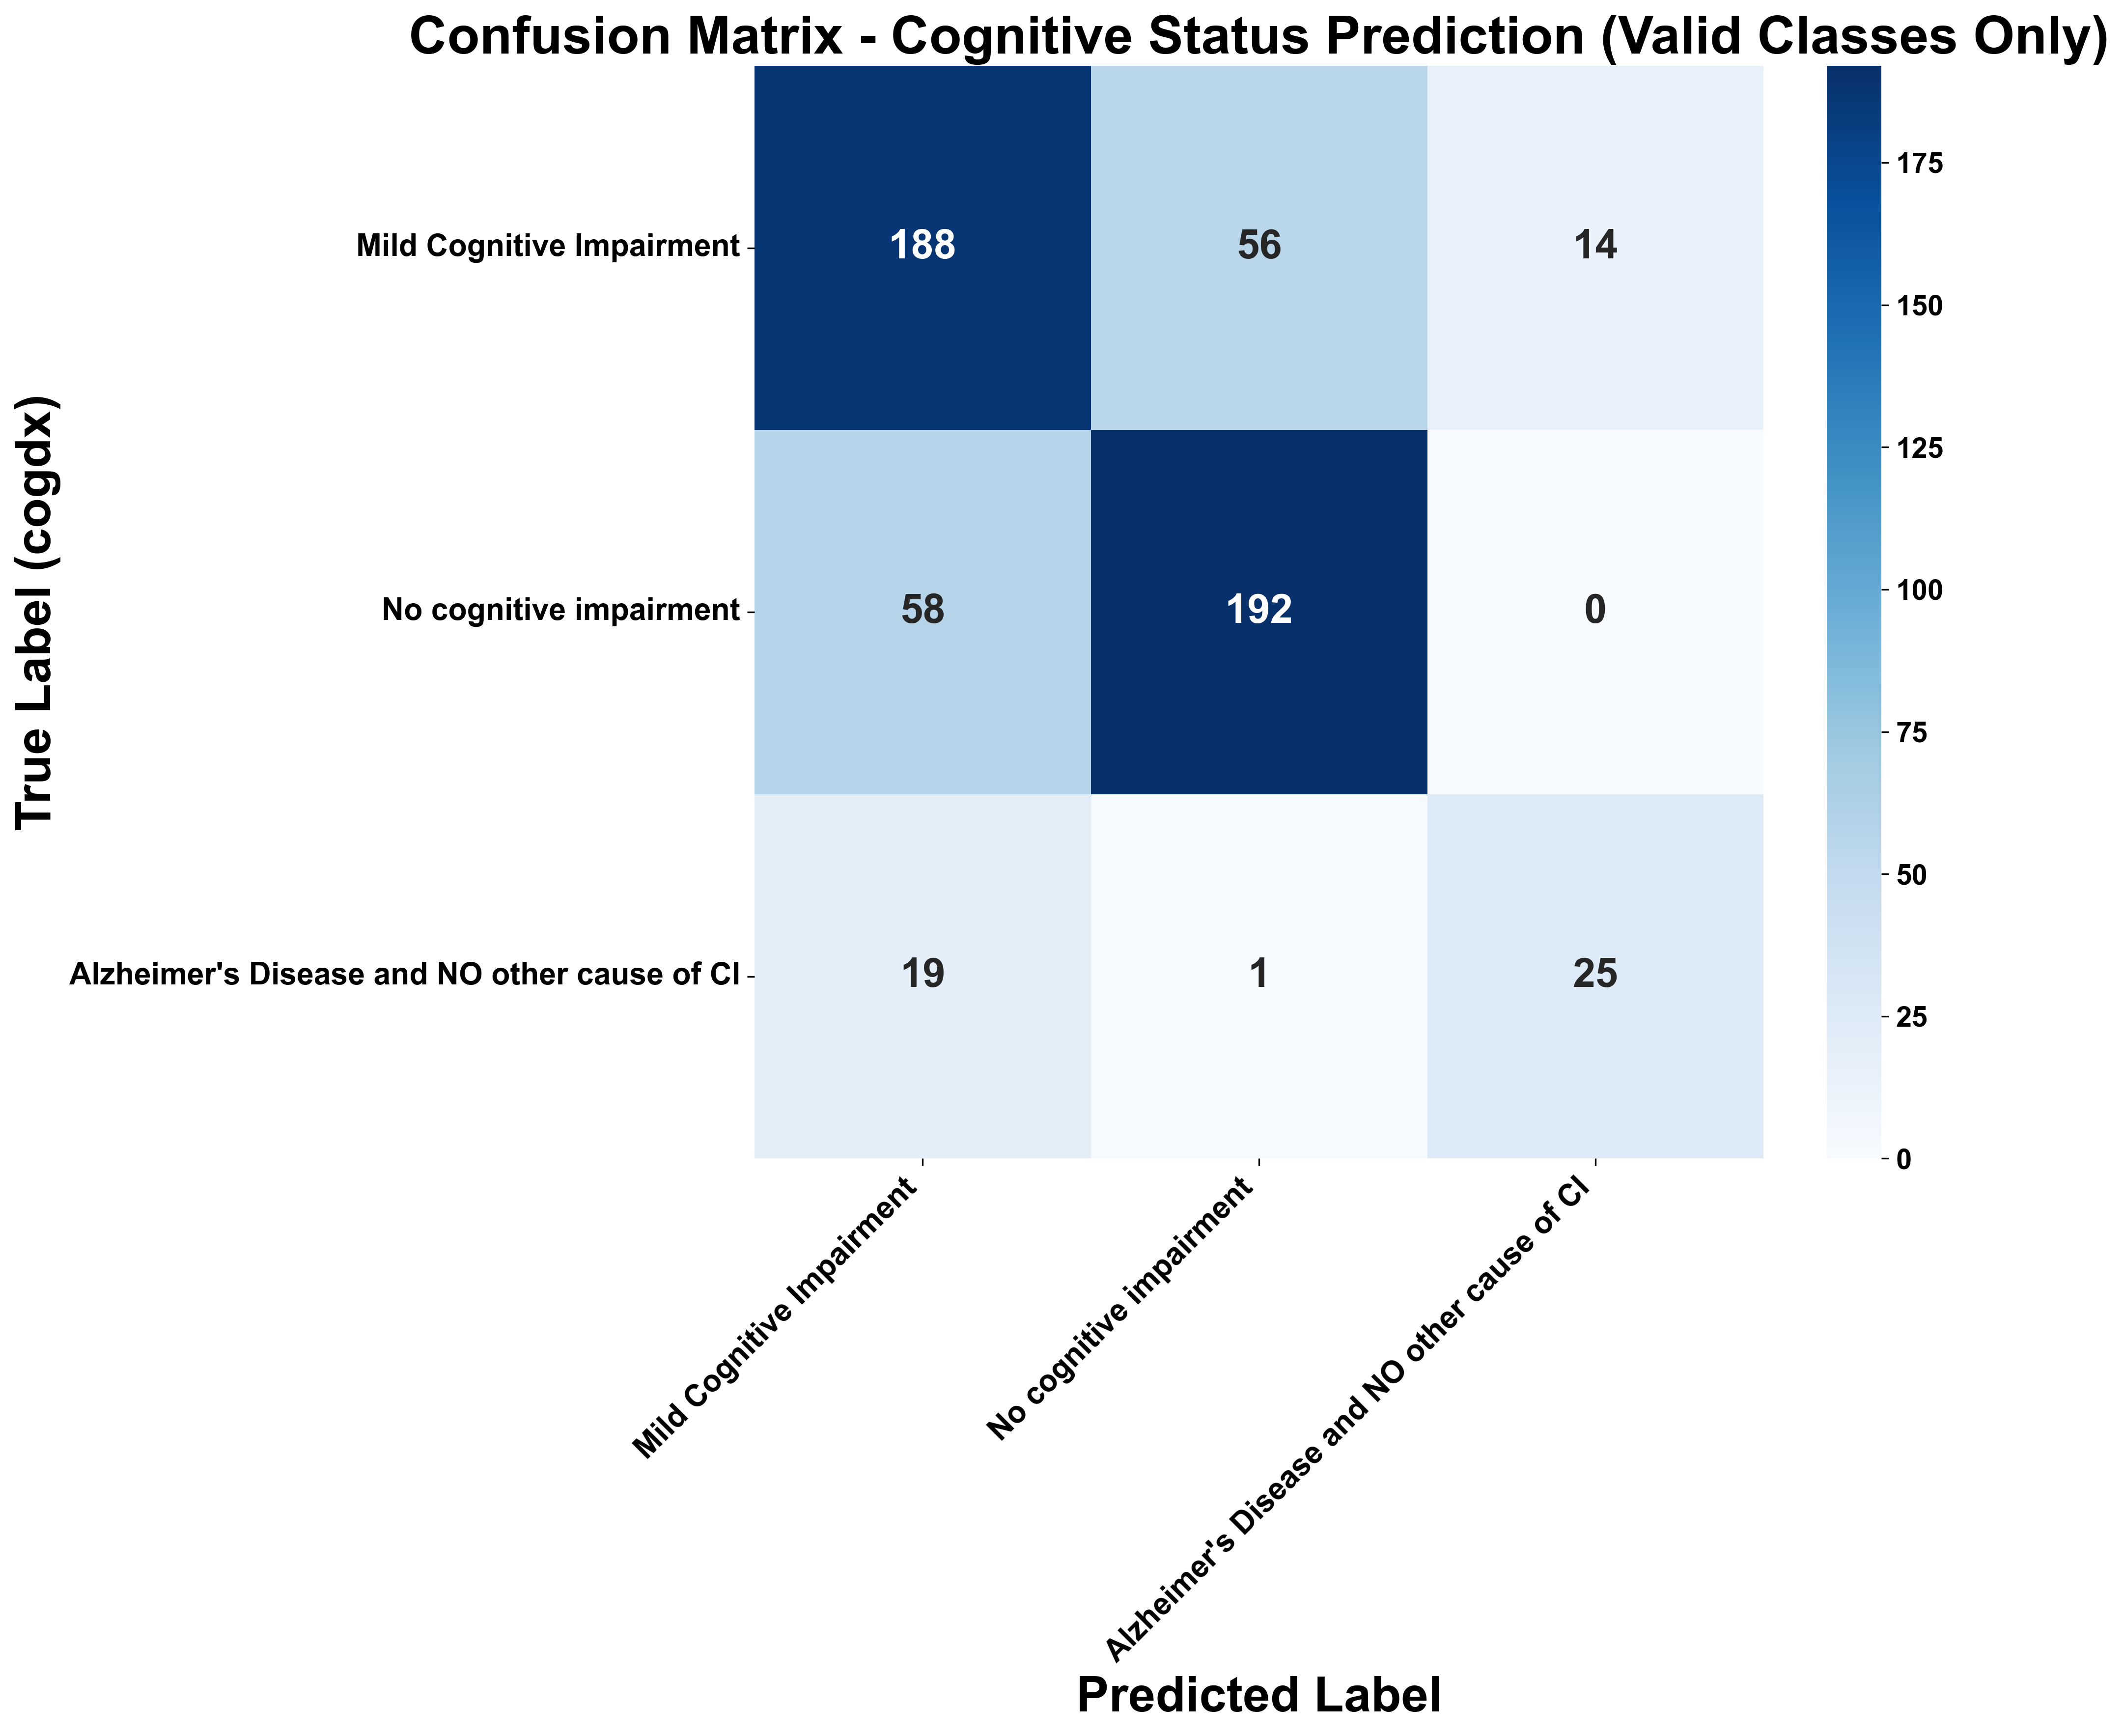


Detailed Classification Report (Valid Classes Only):
                                              precision    recall  f1-score   support

                   Mild Cognitive Impairment       0.71      0.73      0.72       258
                     No cognitive impairment       0.77      0.77      0.77       250
Alzheimer's Disease and NO other cause of CI       0.64      0.56      0.60        45

                                    accuracy                           0.73       553
                                   macro avg       0.71      0.68      0.69       553
                                weighted avg       0.73      0.73      0.73       553


Metrics DataFrame:
                                              precision    recall  f1-score  \
Mild Cognitive Impairment                      0.709434  0.728682  0.718929   
No cognitive impairment                        0.771084  0.768000  0.769539   
Alzheimer's Disease and NO other cause of CI   0.641026  0.555556  0.595238   
accur

In [92]:
##ADNI (Full Model)


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os

# Define the status mapping
STATUS_MAP = {
    1: "No cognitive impairment",
    2: "Mild Cognitive Impairment",
    3: "Mild cognitive impairment and another cause of CI",
    4: "Alzheimer's Disease and NO other cause of CI",
    5: "Alzheimer's Disease and another cause of CI",
    6: "Other dementia"
}

file_path = os.path.expanduser("~/Downloads/other/test_predictions_Full_Model_With_DERs_ADNI_othern_labeled.csv")


# Verify file exists
if not os.path.exists(file_path):
    print(f"ERROR: File not found at {file_path}")
    print("Please verify the file exists at this location.")
else:
    print(f"File found at: {file_path}")
    
    # Load the CSV file
    df = pd.read_csv(file_path)
    
    # Display first few rows
    print("\nData Preview:")
    print(df.head())
    
    # Check for required columns
    required_columns = ['predicted_cogdx', 'cogdx']
    missing_cols = [col for col in required_columns if col not in df.columns]

    if missing_cols:
        print(f"\nERROR: Missing columns: {', '.join(missing_cols)}")
        print("Available columns:", df.columns.tolist())
    else:
        # Check for missing values
        print("\nMissing Values Check:")
        print(df[required_columns].isnull().sum())
    
        # Convert to integers
        df['cogdx'] = df['cogdx'].astype(int)
        df['predicted_cogdx'] = df['predicted_cogdx'].astype(int)
        
        # Identify classes with actual support
        class_counts = df['cogdx'].value_counts()
        valid_classes = class_counts[class_counts > 0].index.tolist()
        
        # Filter both true and predicted labels to only include valid classes
        df_filtered = df[df['cogdx'].isin(valid_classes)].copy()
        
        # Also remove predictions for invalid classes (treat them as misclassifications)
        # This is important because if the model predicts a class that doesn't exist in the test set,
        # we should count it as an error
        invalid_predictions = ~df_filtered['predicted_cogdx'].isin(valid_classes)
        if invalid_predictions.sum() > 0:
            print(f"\nFound {invalid_predictions.sum()} predictions for invalid classes. These will be treated as errors.")
            # You could choose to mark these as a specific error code or just leave them as is
            # For now, we'll just note them but not change the values
        
        print(f"\nFiltered dataset size: {len(df_filtered)}")
        print("Class distribution after filtering:")
        print(df_filtered['cogdx'].value_counts())
    
        # Calculate accuracy
        correct_predictions = (df_filtered['predicted_cogdx'] == df_filtered['cogdx']).sum()
        total_samples = len(df_filtered)
        accuracy = correct_predictions / total_samples

        print(f"\nAccuracy Ratio: {correct_predictions}/{total_samples} = {accuracy:.4f} ({accuracy*100:.2f}%)")
    
        # Generate confusion matrix - only include valid classes
        cm = confusion_matrix(
            df_filtered['cogdx'], 
            df_filtered['predicted_cogdx'],
            labels=valid_classes
        )
        
        # Create labels for matrix using STATUS_MAP
        labels = [STATUS_MAP.get(label, f'Unknown ({label})') for label in valid_classes]
        
        # Plot confusion matrix
        plt.figure(figsize=(14, 12))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels,
            annot_kws={'size': 20})  # Increase annotation text size to 16
        plt.title('Confusion Matrix - Cognitive Status Prediction (Valid Classes Only)', fontsize=26)
        plt.xlabel('Predicted Label', fontsize=24, fontweight='bold')
        plt.ylabel('True Label (cogdx)', fontsize=24, fontweight='bold')
        plt.xticks(rotation=45, ha='right', fontsize=15, fontweight='bold')
        plt.yticks(rotation=0, fontsize=15, fontweight='bold')
        plt.tight_layout()
        plt.show()

        
        # Classification report - only include valid classes
        print("\nDetailed Classification Report (Valid Classes Only):")
        report = classification_report(
            df_filtered['cogdx'], 
            df_filtered['predicted_cogdx'],
            labels=valid_classes,
            target_names=[STATUS_MAP.get(i, f'Unknown ({i})') for i in valid_classes],
            zero_division=0
        )
        print(report)
        
        # Convert classification report to DataFrame for better visualization
        report_dict = classification_report(
            df_filtered['cogdx'], 
            df_filtered['predicted_cogdx'],
            labels=valid_classes,
            target_names=[STATUS_MAP.get(i, f'Unknown ({i})') for i in valid_classes],
            output_dict=True,
            zero_division=0
        )
        metrics_df = pd.DataFrame(report_dict).transpose()
        print("\nMetrics DataFrame:")
        print(metrics_df)
        
        # Additional analysis: Class-wise performance
        print("\nAdditional Analysis:")
        print("=" * 50)
        
        # Calculate class-wise accuracy
        for class_label in valid_classes:
            class_data = df_filtered[df_filtered['cogdx'] == class_label]
            class_accuracy = (class_data['predicted_cogdx'] == class_data['cogdx']).mean()
            print(f"{STATUS_MAP.get(class_label, f'Unknown ({class_label})')}: {class_accuracy:.2%} accuracy")
        
        # Most common misclassifications
        misclassifications = df_filtered[df_filtered['predicted_cogdx'] != df_filtered['cogdx']]
        if len(misclassifications) > 0:
            print(f"\nMost common misclassifications:")
            misclass_counts = misclassifications.groupby(['cogdx', 'predicted_cogdx']).size().reset_index(name='count')
            misclass_counts = misclass_counts.sort_values('count', ascending=False)
            
            for _, row in misclass_counts.head().iterrows():
                true_label = STATUS_MAP.get(row['cogdx'], f'Unknown ({row["cogdx"]})')
                pred_label = STATUS_MAP.get(row['predicted_cogdx'], f'Unknown ({row["predicted_cogdx"]})')
                print(f"  {true_label} → {pred_label}: {row['count']} cases")
        
        # Check for predictions of invalid classes
        invalid_preds = df_filtered[~df_filtered['predicted_cogdx'].isin(valid_classes)]
        if len(invalid_preds) > 0:
            print(f"\nWARNING: {len(invalid_preds)} predictions are for classes not present in the test set:")
            for class_label in invalid_preds['predicted_cogdx'].unique():
                count = (invalid_preds['predicted_cogdx'] == class_label).sum()
                print(f"  Class {class_label} ({STATUS_MAP.get(class_label, 'Unknown')}): {count} predictions")




File found at: /Users/martinnwadiugwu/Downloads/other/test_predictions_Full_Model_With_DERs_ROS_MAP2_labeled.csv

Data Preview:
        Age    PMI.h.     KCNH8  last_MMSE_30      ST18   Braak_2  \
0  1.073573  0.219879  0.331857      2.349385  2.395115 -0.565194   
1  0.930205  0.230303  0.536784     -0.425643 -0.563334 -0.565194   
2  0.010416  0.819330  0.397417     -0.425643 -0.181491 -0.565194   
3  0.692980  0.219879  0.536784     -0.425643  0.507608 -0.565194   
4  1.407193 -0.606467  0.536784     -0.425643  0.507608 -0.565194   

   last_MMSE_26  Years_Education_20  last_MMSE_29  last_MMSE_21  ...  \
0     -0.353852           -0.351156     -0.459666     -0.166795  ...   
1     -0.353852           -0.351156     -0.459666     -0.166795  ...   
2     -0.353852           -0.351156      2.175490     -0.166795  ...   
3     -0.353852           -0.351156     -0.459666     -0.166795  ...   
4     -0.353852           -0.351156      2.175490     -0.166795  ...   

      PC_48     PC_49   

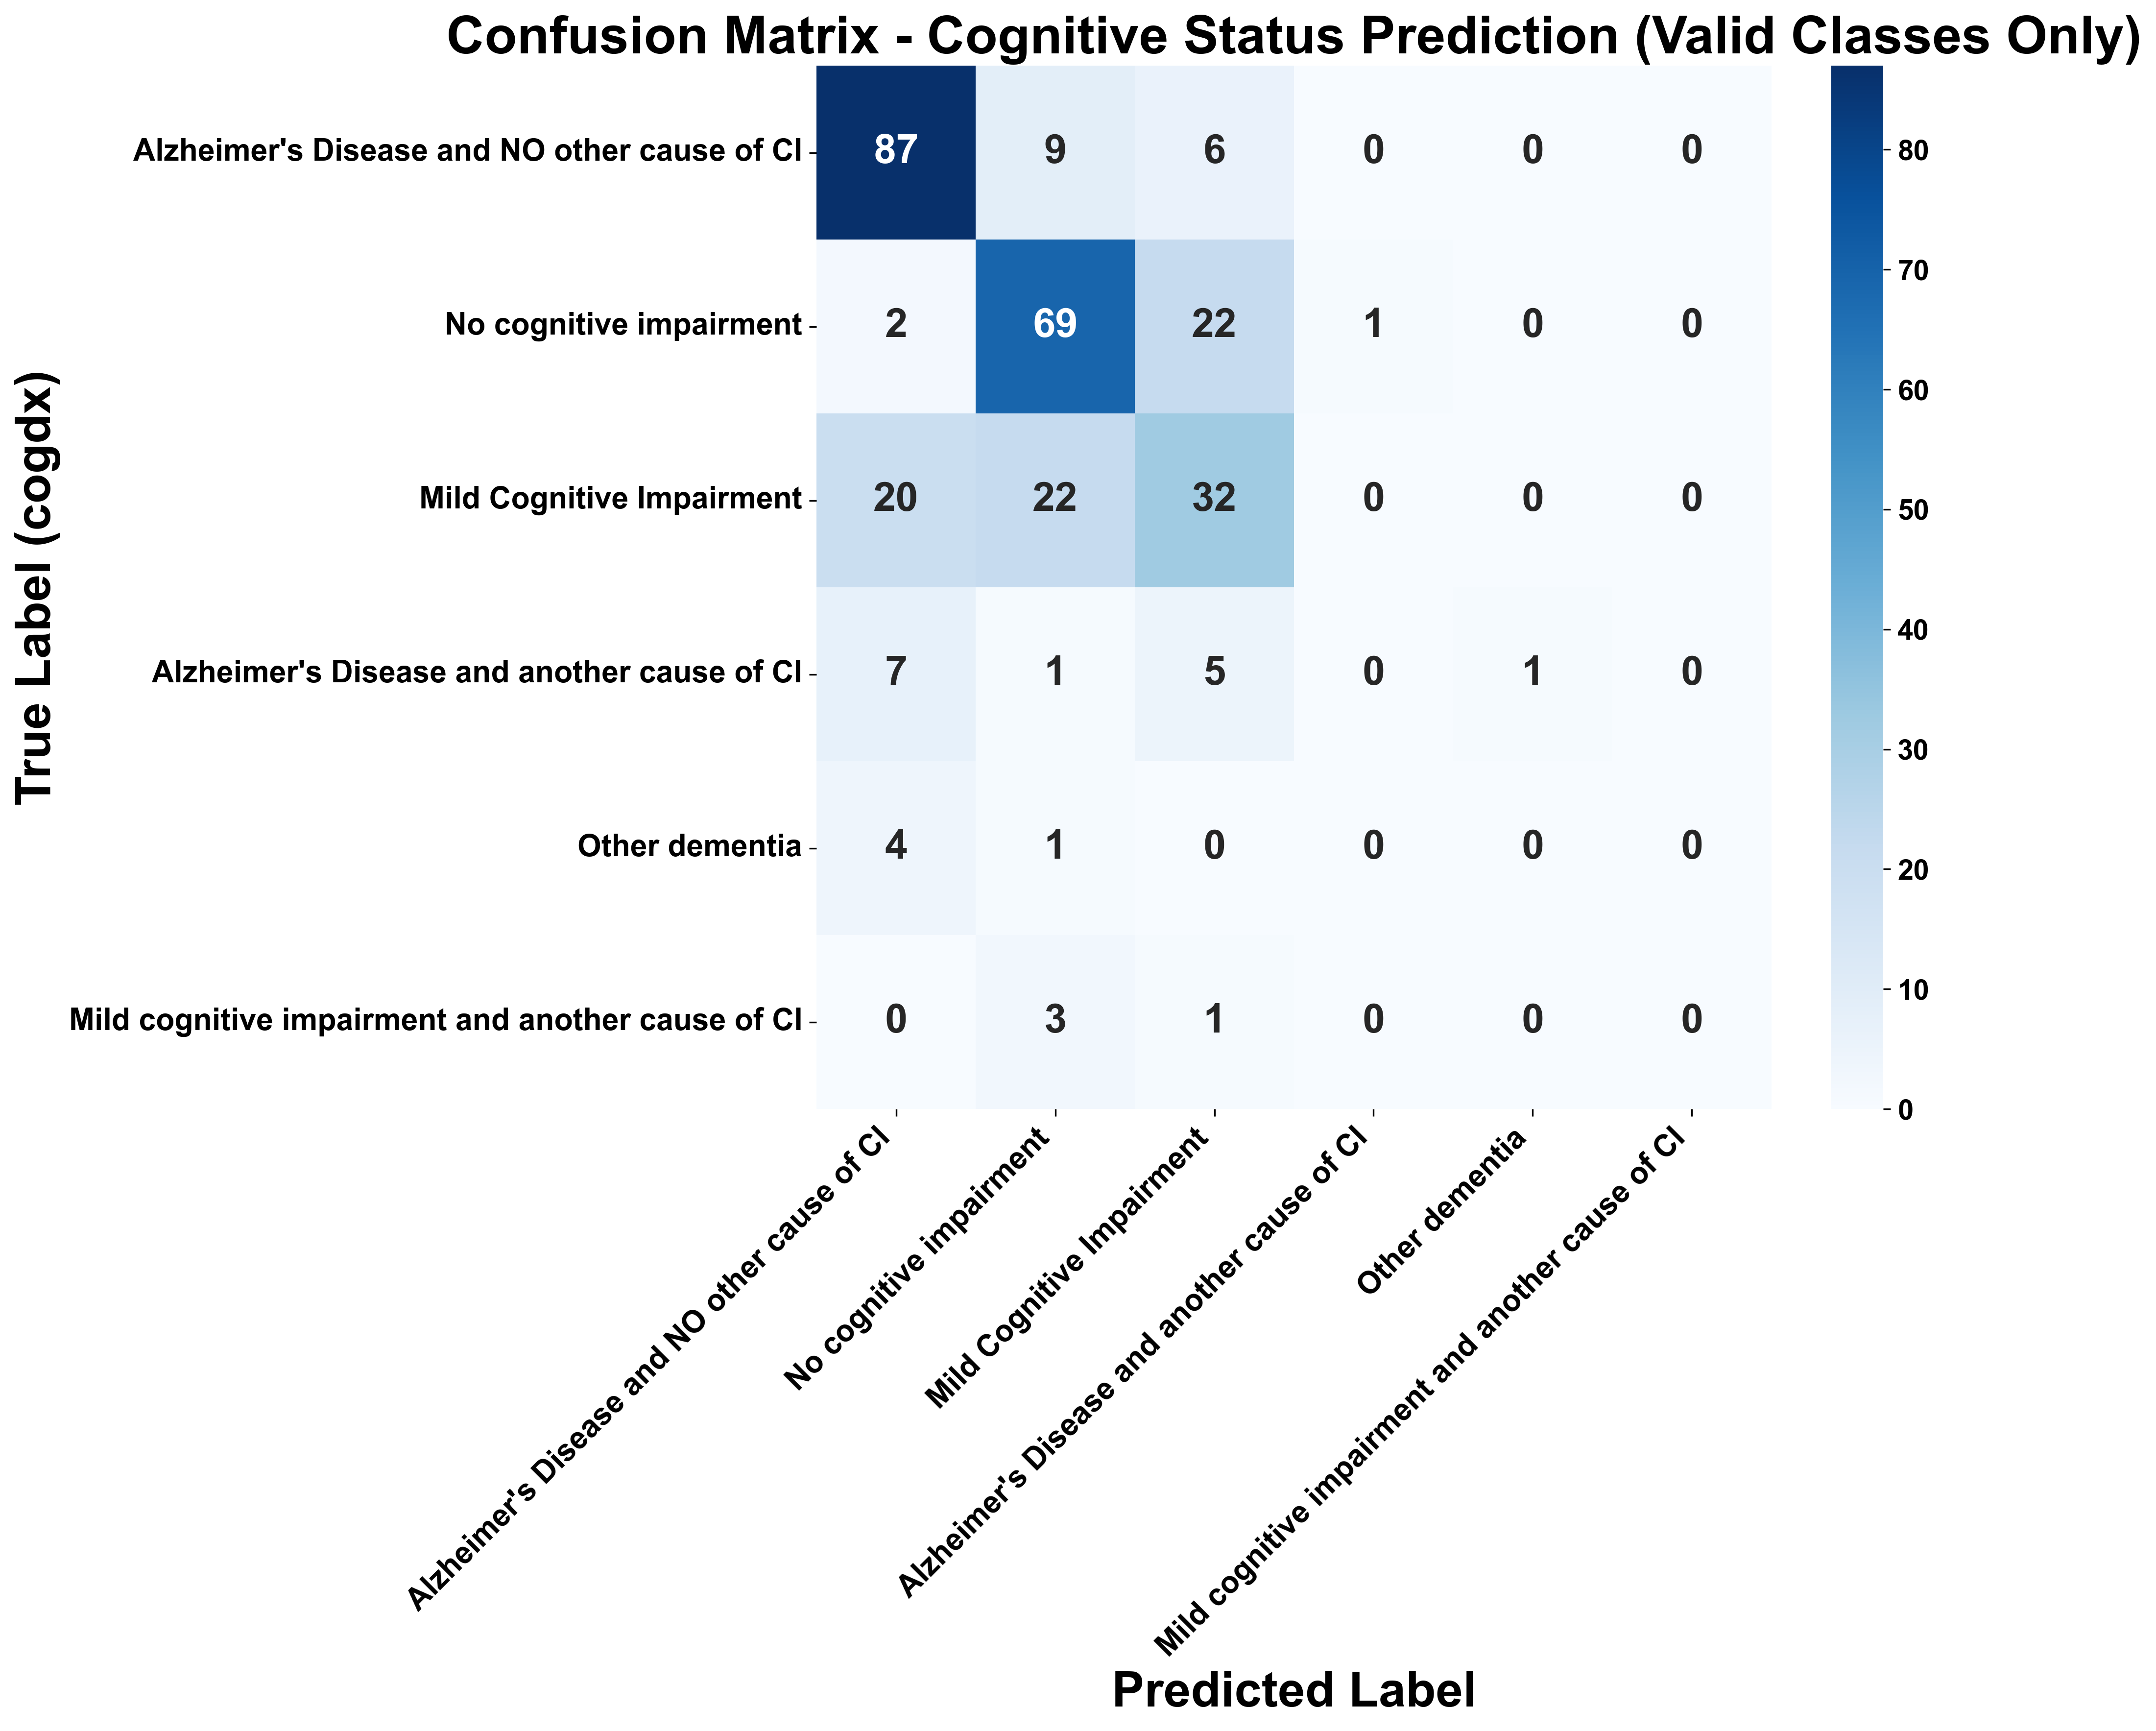


Detailed Classification Report (Valid Classes Only):
                                                   precision    recall  f1-score   support

     Alzheimer's Disease and NO other cause of CI       0.72      0.85      0.78       102
                          No cognitive impairment       0.66      0.73      0.69        94
                        Mild Cognitive Impairment       0.48      0.43      0.46        74
      Alzheimer's Disease and another cause of CI       0.00      0.00      0.00        14
                                   Other dementia       0.00      0.00      0.00         5
Mild cognitive impairment and another cause of CI       0.00      0.00      0.00         4

                                         accuracy                           0.64       293
                                        macro avg       0.31      0.34      0.32       293
                                     weighted avg       0.59      0.64      0.61       293


Metrics DataFrame:
             

In [93]:
##ROSMAP (Full Model)


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os

# Define the status mapping
STATUS_MAP = {
    1: "No cognitive impairment",
    2: "Mild Cognitive Impairment",
    3: "Mild cognitive impairment and another cause of CI",
    4: "Alzheimer's Disease and NO other cause of CI",
    5: "Alzheimer's Disease and another cause of CI",
    6: "Other dementia"
}

file_path = os.path.expanduser("~/Downloads/other/test_predictions_Full_Model_With_DERs_ROS_MAP2_labeled.csv")

# Verify file exists
if not os.path.exists(file_path):
    print(f"ERROR: File not found at {file_path}")
    print("Please verify the file exists at this location.")
else:
    print(f"File found at: {file_path}")
    
    # Load the CSV file
    df = pd.read_csv(file_path)
    
    # Display first few rows
    print("\nData Preview:")
    print(df.head())
    
    # Check for required columns
    required_columns = ['predicted_cogdx', 'cogdx']
    missing_cols = [col for col in required_columns if col not in df.columns]

    if missing_cols:
        print(f"\nERROR: Missing columns: {', '.join(missing_cols)}")
        print("Available columns:", df.columns.tolist())
    else:
        # Check for missing values
        print("\nMissing Values Check:")
        print(df[required_columns].isnull().sum())
    
        # Convert to integers
        df['cogdx'] = df['cogdx'].astype(int)
        df['predicted_cogdx'] = df['predicted_cogdx'].astype(int)
        
        # Identify classes with actual support
        class_counts = df['cogdx'].value_counts()
        valid_classes = class_counts[class_counts > 0].index.tolist()
        
        # Filter both true and predicted labels to only include valid classes
        df_filtered = df[df['cogdx'].isin(valid_classes)].copy()
        
        # Also remove predictions for invalid classes (treat them as misclassifications)
        # This is important because if the model predicts a class that doesn't exist in the test set,
        # we should count it as an error
        invalid_predictions = ~df_filtered['predicted_cogdx'].isin(valid_classes)
        if invalid_predictions.sum() > 0:
            print(f"\nFound {invalid_predictions.sum()} predictions for invalid classes. These will be treated as errors.")
            # You could choose to mark these as a specific error code or just leave them as is
            # For now, we'll just note them but not change the values
        
        print(f"\nFiltered dataset size: {len(df_filtered)}")
        print("Class distribution after filtering:")
        print(df_filtered['cogdx'].value_counts())
    
        # Calculate accuracy
        correct_predictions = (df_filtered['predicted_cogdx'] == df_filtered['cogdx']).sum()
        total_samples = len(df_filtered)
        accuracy = correct_predictions / total_samples

        print(f"\nAccuracy Ratio: {correct_predictions}/{total_samples} = {accuracy:.4f} ({accuracy*100:.2f}%)")
    
        # Generate confusion matrix - only include valid classes
        cm = confusion_matrix(
            df_filtered['cogdx'], 
            df_filtered['predicted_cogdx'],
            labels=valid_classes
        )
        
        # Create labels for matrix using STATUS_MAP
        labels = [STATUS_MAP.get(label, f'Unknown ({label})') for label in valid_classes]
        
        # Plot confusion matrix
        plt.figure(figsize=(14, 12))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels,
            annot_kws={'size': 20})  # Increase annotation text size to 16
        plt.title('Confusion Matrix - Cognitive Status Prediction (Valid Classes Only)', fontsize=26)
        plt.xlabel('Predicted Label', fontsize=24, fontweight='bold')
        plt.ylabel('True Label (cogdx)', fontsize=24, fontweight='bold')
        plt.xticks(rotation=45, ha='right', fontsize=15, fontweight='bold')
        plt.yticks(rotation=0, fontsize=15, fontweight='bold')
        plt.tight_layout()
        plt.show()

        
        # Classification report - only include valid classes
        print("\nDetailed Classification Report (Valid Classes Only):")
        report = classification_report(
            df_filtered['cogdx'], 
            df_filtered['predicted_cogdx'],
            labels=valid_classes,
            target_names=[STATUS_MAP.get(i, f'Unknown ({i})') for i in valid_classes],
            zero_division=0
        )
        print(report)
        
        # Convert classification report to DataFrame for better visualization
        report_dict = classification_report(
            df_filtered['cogdx'], 
            df_filtered['predicted_cogdx'],
            labels=valid_classes,
            target_names=[STATUS_MAP.get(i, f'Unknown ({i})') for i in valid_classes],
            output_dict=True,
            zero_division=0
        )
        metrics_df = pd.DataFrame(report_dict).transpose()
        print("\nMetrics DataFrame:")
        print(metrics_df)
        
        # Additional analysis: Class-wise performance
        print("\nAdditional Analysis:")
        print("=" * 50)
        
        # Calculate class-wise accuracy
        for class_label in valid_classes:
            class_data = df_filtered[df_filtered['cogdx'] == class_label]
            class_accuracy = (class_data['predicted_cogdx'] == class_data['cogdx']).mean()
            print(f"{STATUS_MAP.get(class_label, f'Unknown ({class_label})')}: {class_accuracy:.2%} accuracy")
        
        # Most common misclassifications
        misclassifications = df_filtered[df_filtered['predicted_cogdx'] != df_filtered['cogdx']]
        if len(misclassifications) > 0:
            print(f"\nMost common misclassifications:")
            misclass_counts = misclassifications.groupby(['cogdx', 'predicted_cogdx']).size().reset_index(name='count')
            misclass_counts = misclass_counts.sort_values('count', ascending=False)
            
            for _, row in misclass_counts.head().iterrows():
                true_label = STATUS_MAP.get(row['cogdx'], f'Unknown ({row["cogdx"]})')
                pred_label = STATUS_MAP.get(row['predicted_cogdx'], f'Unknown ({row["predicted_cogdx"]})')
                print(f"  {true_label} → {pred_label}: {row['count']} cases")
        
        # Check for predictions of invalid classes
        invalid_preds = df_filtered[~df_filtered['predicted_cogdx'].isin(valid_classes)]
        if len(invalid_preds) > 0:
            print(f"\nWARNING: {len(invalid_preds)} predictions are for classes not present in the test set:")
            for class_label in invalid_preds['predicted_cogdx'].unique():
                count = (invalid_preds['predicted_cogdx'] == class_label).sum()
                print(f"  Class {class_label} ({STATUS_MAP.get(class_label, 'Unknown')}): {count} predictions")



File found at: /Users/martinnwadiugwu/Downloads/other/test_predictions_Imputed_Model_MICE_DERs_ROS_MAP2_labeled.csv

Data Preview:
        Age    PMI.h.     KCNH8  last_MMSE_30      ST18   Braak_2  \
0  1.073573  0.219879  0.331857      2.349385  2.395115 -0.565194   
1  0.930205  0.230303  0.536784     -0.425643 -0.563334 -0.565194   
2  0.010416  0.819330  0.397417     -0.425643 -0.181491 -0.565194   
3  0.692980  0.219879  0.536784     -0.425643  0.507608 -0.565194   
4  1.407193 -0.606467  0.536784     -0.425643  0.507608 -0.565194   

   last_MMSE_26  Years_Education_20  last_MMSE_29  last_MMSE_21  ...  \
0     -0.353852           -0.351156     -0.459666     -0.166795  ...   
1     -0.353852           -0.351156     -0.459666     -0.166795  ...   
2     -0.353852           -0.351156      2.175490     -0.166795  ...   
3     -0.353852           -0.351156     -0.459666     -0.166795  ...   
4     -0.353852           -0.351156      2.175490     -0.166795  ...   

      PC_48     PC_49

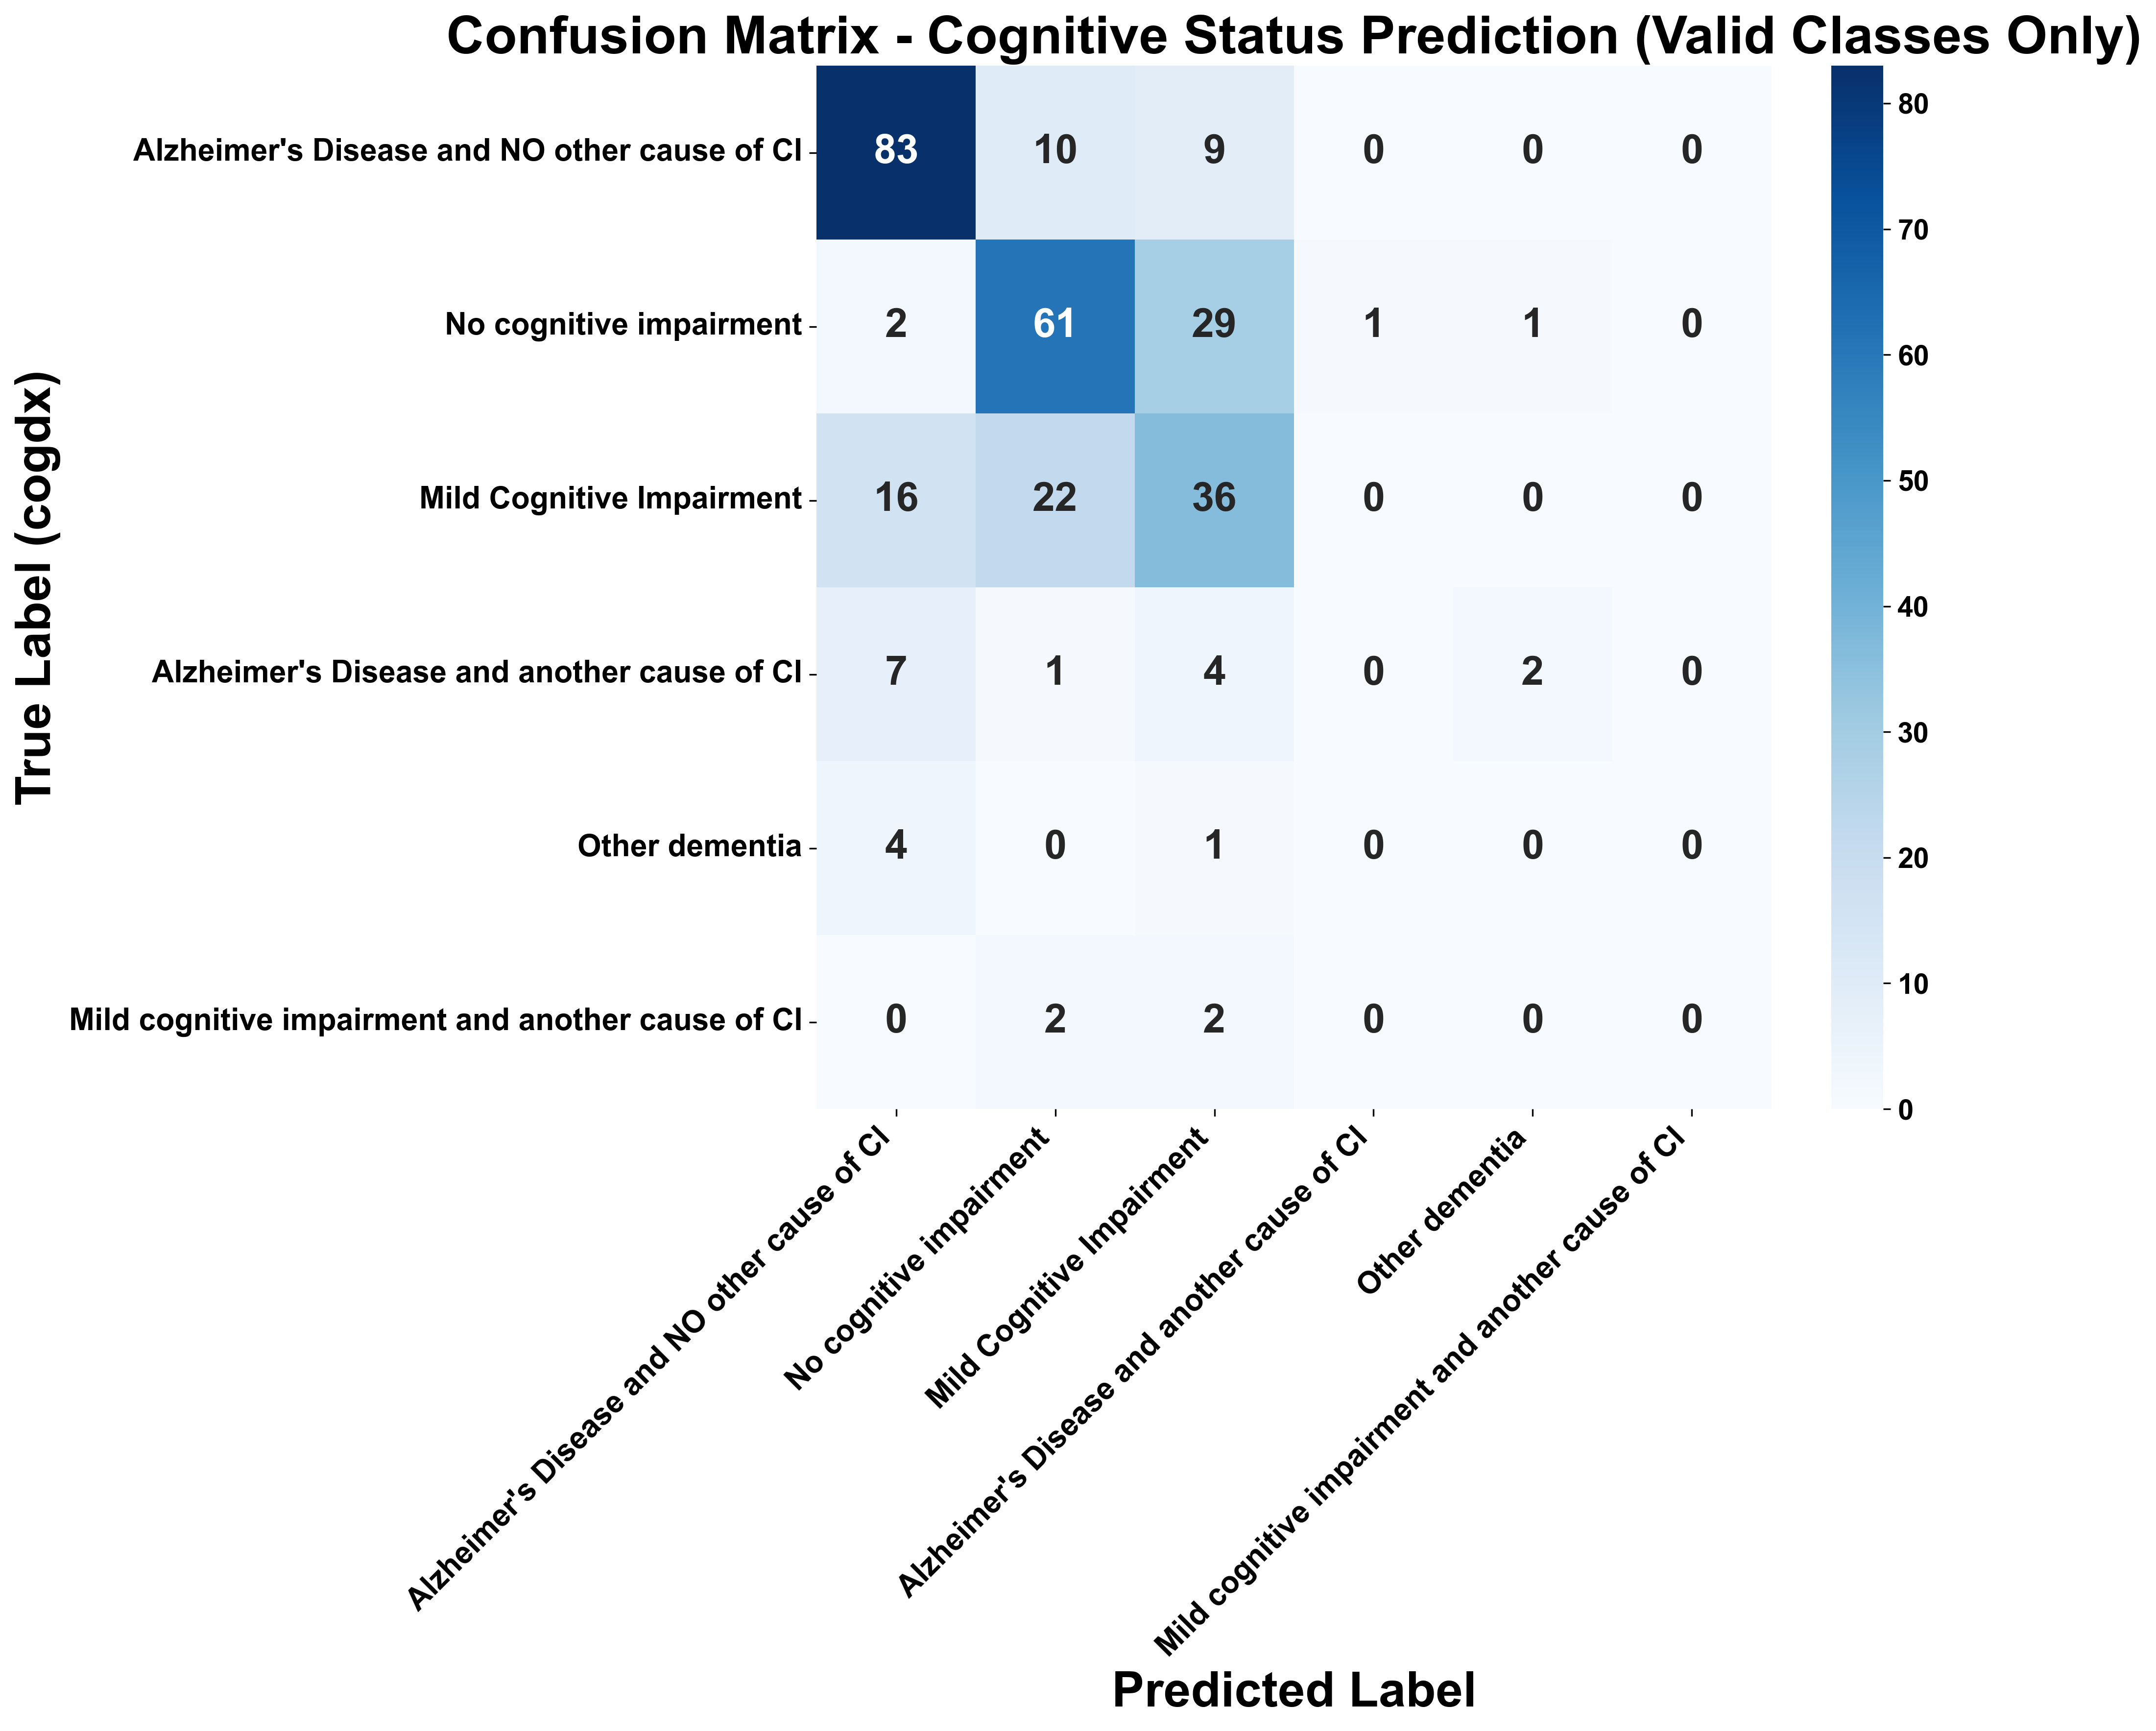


Detailed Classification Report (Valid Classes Only):
                                                   precision    recall  f1-score   support

     Alzheimer's Disease and NO other cause of CI       0.74      0.81      0.78       102
                          No cognitive impairment       0.64      0.65      0.64        94
                        Mild Cognitive Impairment       0.44      0.49      0.46        74
      Alzheimer's Disease and another cause of CI       0.00      0.00      0.00        14
                                   Other dementia       0.00      0.00      0.00         5
Mild cognitive impairment and another cause of CI       0.00      0.00      0.00         4

                                         accuracy                           0.61       293
                                        macro avg       0.30      0.32      0.31       293
                                     weighted avg       0.57      0.61      0.59       293


Metrics DataFrame:
             

In [97]:
##ROSMAP (Imputed Model)


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os

# Define the status mapping
STATUS_MAP = {
    1: "No cognitive impairment",
    2: "Mild Cognitive Impairment",
    3: "Mild cognitive impairment and another cause of CI",
    4: "Alzheimer's Disease and NO other cause of CI",
    5: "Alzheimer's Disease and another cause of CI",
    6: "Other dementia"
}

file_path = os.path.expanduser("~/Downloads/other/test_predictions_Imputed_Model_MICE_DERs_ROS_MAP2_labeled.csv")


# Verify file exists
if not os.path.exists(file_path):
    print(f"ERROR: File not found at {file_path}")
    print("Please verify the file exists at this location.")
else:
    print(f"File found at: {file_path}")
    
    # Load the CSV file
    df = pd.read_csv(file_path)
    
    # Display first few rows
    print("\nData Preview:")
    print(df.head())
    
    # Check for required columns
    required_columns = ['predicted_cogdx', 'cogdx']
    missing_cols = [col for col in required_columns if col not in df.columns]

    if missing_cols:
        print(f"\nERROR: Missing columns: {', '.join(missing_cols)}")
        print("Available columns:", df.columns.tolist())
    else:
        # Check for missing values
        print("\nMissing Values Check:")
        print(df[required_columns].isnull().sum())
    
        # Convert to integers
        df['cogdx'] = df['cogdx'].astype(int)
        df['predicted_cogdx'] = df['predicted_cogdx'].astype(int)
        
        # Identify classes with actual support
        class_counts = df['cogdx'].value_counts()
        valid_classes = class_counts[class_counts > 0].index.tolist()
        
        # Filter both true and predicted labels to only include valid classes
        df_filtered = df[df['cogdx'].isin(valid_classes)].copy()
        
        # Also remove predictions for invalid classes (treat them as misclassifications)
        # This is important because if the model predicts a class that doesn't exist in the test set,
        # we should count it as an error
        invalid_predictions = ~df_filtered['predicted_cogdx'].isin(valid_classes)
        if invalid_predictions.sum() > 0:
            print(f"\nFound {invalid_predictions.sum()} predictions for invalid classes. These will be treated as errors.")
            # You could choose to mark these as a specific error code or just leave them as is
            # For now, we'll just note them but not change the values
        
        print(f"\nFiltered dataset size: {len(df_filtered)}")
        print("Class distribution after filtering:")
        print(df_filtered['cogdx'].value_counts())
    
        # Calculate accuracy
        correct_predictions = (df_filtered['predicted_cogdx'] == df_filtered['cogdx']).sum()
        total_samples = len(df_filtered)
        accuracy = correct_predictions / total_samples

        print(f"\nAccuracy Ratio: {correct_predictions}/{total_samples} = {accuracy:.4f} ({accuracy*100:.2f}%)")
    
        # Generate confusion matrix - only include valid classes
        cm = confusion_matrix(
            df_filtered['cogdx'], 
            df_filtered['predicted_cogdx'],
            labels=valid_classes
        )
        
        # Create labels for matrix using STATUS_MAP
        labels = [STATUS_MAP.get(label, f'Unknown ({label})') for label in valid_classes]
        
        # Plot confusion matrix
        plt.figure(figsize=(14, 12))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels,
            annot_kws={'size': 20})  # Increase annotation text size to 16
        plt.title('Confusion Matrix - Cognitive Status Prediction (Valid Classes Only)', fontsize=26)
        plt.xlabel('Predicted Label', fontsize=24, fontweight='bold')
        plt.ylabel('True Label (cogdx)', fontsize=24, fontweight='bold')
        plt.xticks(rotation=45, ha='right', fontsize=15, fontweight='bold')
        plt.yticks(rotation=0, fontsize=15, fontweight='bold')
        plt.tight_layout()
        plt.show()

        
        # Classification report - only include valid classes
        print("\nDetailed Classification Report (Valid Classes Only):")
        report = classification_report(
            df_filtered['cogdx'], 
            df_filtered['predicted_cogdx'],
            labels=valid_classes,
            target_names=[STATUS_MAP.get(i, f'Unknown ({i})') for i in valid_classes],
            zero_division=0
        )
        print(report)
        
        # Convert classification report to DataFrame for better visualization
        report_dict = classification_report(
            df_filtered['cogdx'], 
            df_filtered['predicted_cogdx'],
            labels=valid_classes,
            target_names=[STATUS_MAP.get(i, f'Unknown ({i})') for i in valid_classes],
            output_dict=True,
            zero_division=0
        )
        metrics_df = pd.DataFrame(report_dict).transpose()
        print("\nMetrics DataFrame:")
        print(metrics_df)
        
        # Additional analysis: Class-wise performance
        print("\nAdditional Analysis:")
        print("=" * 50)
        
        # Calculate class-wise accuracy
        for class_label in valid_classes:
            class_data = df_filtered[df_filtered['cogdx'] == class_label]
            class_accuracy = (class_data['predicted_cogdx'] == class_data['cogdx']).mean()
            print(f"{STATUS_MAP.get(class_label, f'Unknown ({class_label})')}: {class_accuracy:.2%} accuracy")
        
        # Most common misclassifications
        misclassifications = df_filtered[df_filtered['predicted_cogdx'] != df_filtered['cogdx']]
        if len(misclassifications) > 0:
            print(f"\nMost common misclassifications:")
            misclass_counts = misclassifications.groupby(['cogdx', 'predicted_cogdx']).size().reset_index(name='count')
            misclass_counts = misclass_counts.sort_values('count', ascending=False)
            
            for _, row in misclass_counts.head().iterrows():
                true_label = STATUS_MAP.get(row['cogdx'], f'Unknown ({row["cogdx"]})')
                pred_label = STATUS_MAP.get(row['predicted_cogdx'], f'Unknown ({row["predicted_cogdx"]})')
                print(f"  {true_label} → {pred_label}: {row['count']} cases")
        
        # Check for predictions of invalid classes
        invalid_preds = df_filtered[~df_filtered['predicted_cogdx'].isin(valid_classes)]
        if len(invalid_preds) > 0:
            print(f"\nWARNING: {len(invalid_preds)} predictions are for classes not present in the test set:")
            for class_label in invalid_preds['predicted_cogdx'].unique():
                count = (invalid_preds['predicted_cogdx'] == class_label).sum()
                print(f"  Class {class_label} ({STATUS_MAP.get(class_label, 'Unknown')}): {count} predictions")


File found at: /Users/martinnwadiugwu/Downloads/other/test_predictions_Imputed_Model_MICE_DERs_ADNI_othern_labeled.csv

Data Preview:
        Age    PMI.h.     KCNH8  last_MMSE_30      ST18   Braak_2  \
0 -0.572546  0.936328  0.236576     -0.425643  0.507608  1.769303   
1 -0.032851  1.560639  0.536784      2.349385  2.395115  1.769303   
2 -0.613648  0.433936  0.331857      2.349385 -0.457666 -0.565194   
3 -2.482156  1.245560  0.397417      2.349385  0.329956 -0.565194   
4 -0.483698  0.716888  0.331857     -0.425643  0.042429  1.769303   

   last_MMSE_26  Years_Education_20  last_MMSE_29  last_MMSE_21  ...  \
0     -0.353852           -0.351156      2.175490     -0.166795  ...   
1     -0.353852           -0.351156     -0.459666     -0.166795  ...   
2     -0.353852           -0.351156     -0.459666     -0.166795  ...   
3     -0.353852           -0.351156     -0.459666     -0.166795  ...   
4     -0.353852           -0.351156     -0.459666     -0.166795  ...   

      PC_48     PC

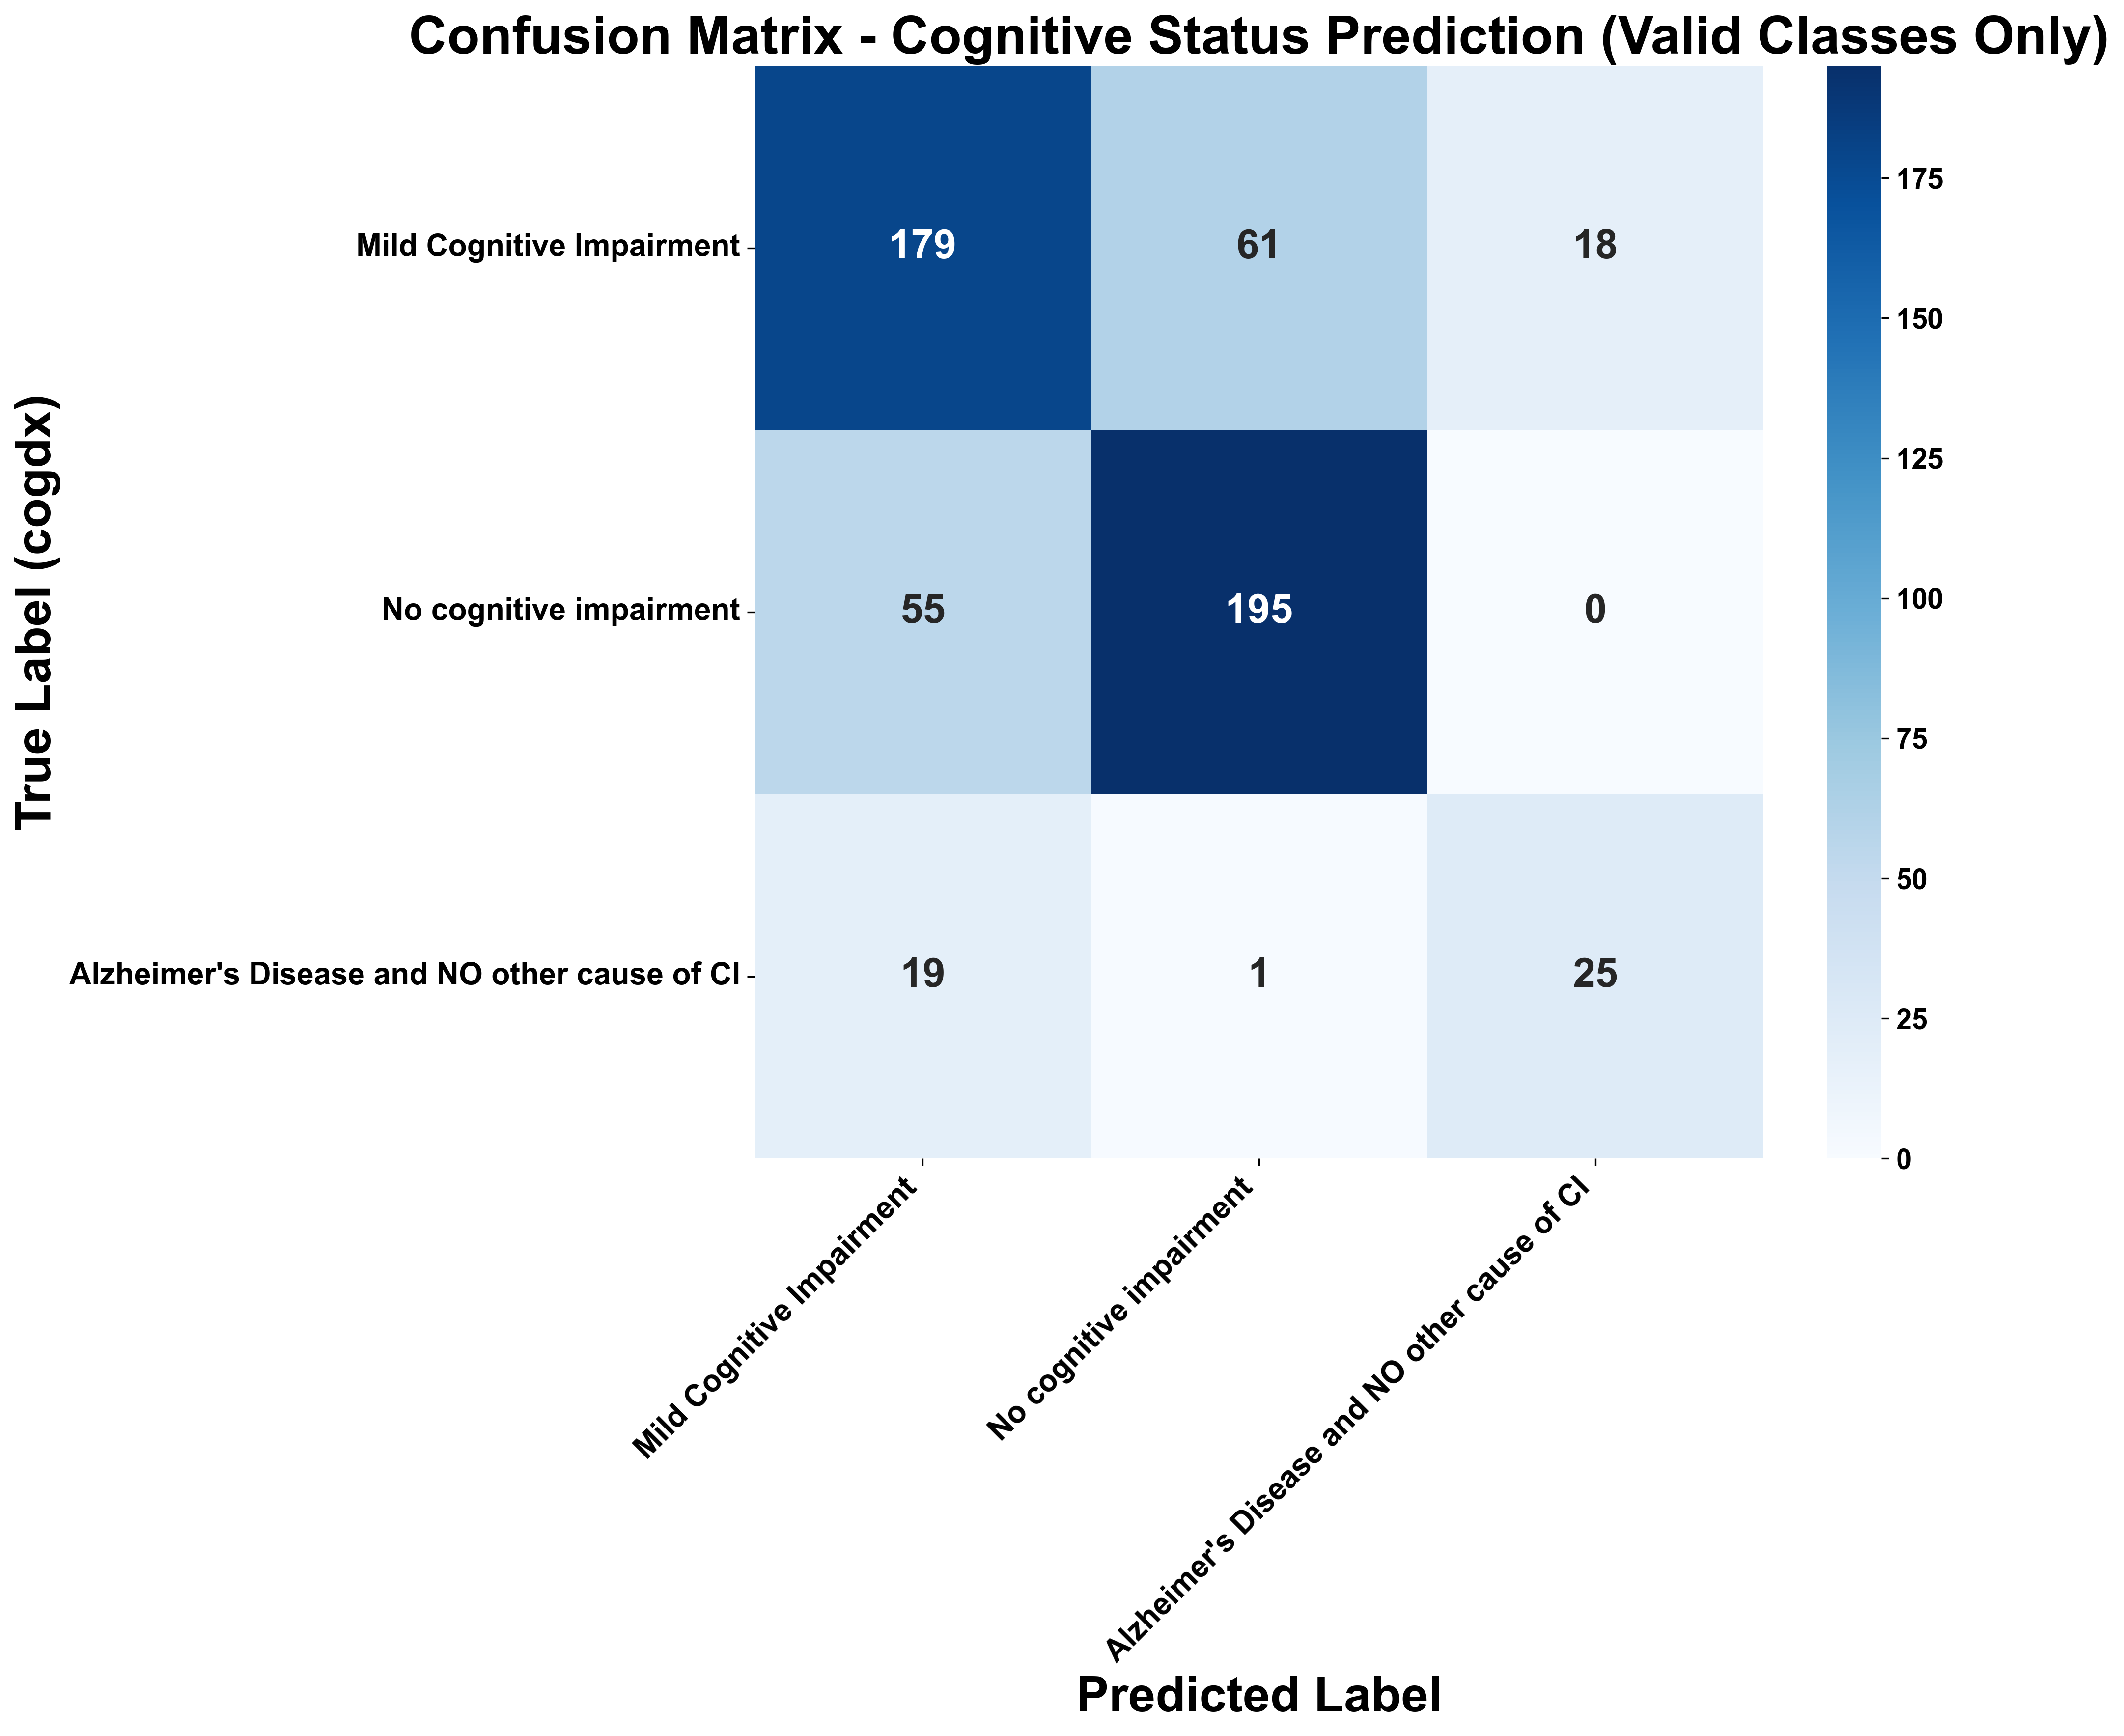


Detailed Classification Report (Valid Classes Only):
                                              precision    recall  f1-score   support

                   Mild Cognitive Impairment       0.71      0.69      0.70       258
                     No cognitive impairment       0.76      0.78      0.77       250
Alzheimer's Disease and NO other cause of CI       0.58      0.56      0.57        45

                                    accuracy                           0.72       553
                                   macro avg       0.68      0.68      0.68       553
                                weighted avg       0.72      0.72      0.72       553


Metrics DataFrame:
                                              precision    recall  f1-score  \
Mild Cognitive Impairment                      0.707510  0.693798  0.700587   
No cognitive impairment                        0.758755  0.780000  0.769231   
Alzheimer's Disease and NO other cause of CI   0.581395  0.555556  0.568182   
accur

In [99]:
##ADNI (Imputed Model)


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os

# Define the status mapping
STATUS_MAP = {
    1: "No cognitive impairment",
    2: "Mild Cognitive Impairment",
    3: "Mild cognitive impairment and another cause of CI",
    4: "Alzheimer's Disease and NO other cause of CI",
    5: "Alzheimer's Disease and another cause of CI",
    6: "Other dementia"
}

file_path = os.path.expanduser("~/Downloads/other/test_predictions_Imputed_Model_MICE_DERs_ADNI_othern_labeled.csv")


# Verify file exists
if not os.path.exists(file_path):
    print(f"ERROR: File not found at {file_path}")
    print("Please verify the file exists at this location.")
else:
    print(f"File found at: {file_path}")
    
    # Load the CSV file
    df = pd.read_csv(file_path)
    
    # Display first few rows
    print("\nData Preview:")
    print(df.head())
    
    # Check for required columns
    required_columns = ['predicted_cogdx', 'cogdx']
    missing_cols = [col for col in required_columns if col not in df.columns]

    if missing_cols:
        print(f"\nERROR: Missing columns: {', '.join(missing_cols)}")
        print("Available columns:", df.columns.tolist())
    else:
        # Check for missing values
        print("\nMissing Values Check:")
        print(df[required_columns].isnull().sum())
    
        # Convert to integers
        df['cogdx'] = df['cogdx'].astype(int)
        df['predicted_cogdx'] = df['predicted_cogdx'].astype(int)
        
        # Identify classes with actual support
        class_counts = df['cogdx'].value_counts()
        valid_classes = class_counts[class_counts > 0].index.tolist()
        
        # Filter both true and predicted labels to only include valid classes
        df_filtered = df[df['cogdx'].isin(valid_classes)].copy()
        
        # Also remove predictions for invalid classes (treat them as misclassifications)
        # This is important because if the model predicts a class that doesn't exist in the test set,
        # we should count it as an error
        invalid_predictions = ~df_filtered['predicted_cogdx'].isin(valid_classes)
        if invalid_predictions.sum() > 0:
            print(f"\nFound {invalid_predictions.sum()} predictions for invalid classes. These will be treated as errors.")
            # You could choose to mark these as a specific error code or just leave them as is
            # For now, we'll just note them but not change the values
        
        print(f"\nFiltered dataset size: {len(df_filtered)}")
        print("Class distribution after filtering:")
        print(df_filtered['cogdx'].value_counts())
    
        # Calculate accuracy
        correct_predictions = (df_filtered['predicted_cogdx'] == df_filtered['cogdx']).sum()
        total_samples = len(df_filtered)
        accuracy = correct_predictions / total_samples

        print(f"\nAccuracy Ratio: {correct_predictions}/{total_samples} = {accuracy:.4f} ({accuracy*100:.2f}%)")
    
        # Generate confusion matrix - only include valid classes
        cm = confusion_matrix(
            df_filtered['cogdx'], 
            df_filtered['predicted_cogdx'],
            labels=valid_classes
        )
        
        # Create labels for matrix using STATUS_MAP
        labels = [STATUS_MAP.get(label, f'Unknown ({label})') for label in valid_classes]
        
        # Plot confusion matrix
        plt.figure(figsize=(14, 12))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels,
            annot_kws={'size': 20})  # Increase annotation text size to 16
        plt.title('Confusion Matrix - Cognitive Status Prediction (Valid Classes Only)', fontsize=26)
        plt.xlabel('Predicted Label', fontsize=24, fontweight='bold')
        plt.ylabel('True Label (cogdx)', fontsize=24, fontweight='bold')
        plt.xticks(rotation=45, ha='right', fontsize=15, fontweight='bold')
        plt.yticks(rotation=0, fontsize=15, fontweight='bold')
        plt.tight_layout()
        plt.show()

        
        # Classification report - only include valid classes
        print("\nDetailed Classification Report (Valid Classes Only):")
        report = classification_report(
            df_filtered['cogdx'], 
            df_filtered['predicted_cogdx'],
            labels=valid_classes,
            target_names=[STATUS_MAP.get(i, f'Unknown ({i})') for i in valid_classes],
            zero_division=0
        )
        print(report)
        
        # Convert classification report to DataFrame for better visualization
        report_dict = classification_report(
            df_filtered['cogdx'], 
            df_filtered['predicted_cogdx'],
            labels=valid_classes,
            target_names=[STATUS_MAP.get(i, f'Unknown ({i})') for i in valid_classes],
            output_dict=True,
            zero_division=0
        )
        metrics_df = pd.DataFrame(report_dict).transpose()
        print("\nMetrics DataFrame:")
        print(metrics_df)
        
        # Additional analysis: Class-wise performance
        print("\nAdditional Analysis:")
        print("=" * 50)
        
        # Calculate class-wise accuracy
        for class_label in valid_classes:
            class_data = df_filtered[df_filtered['cogdx'] == class_label]
            class_accuracy = (class_data['predicted_cogdx'] == class_data['cogdx']).mean()
            print(f"{STATUS_MAP.get(class_label, f'Unknown ({class_label})')}: {class_accuracy:.2%} accuracy")
        
        # Most common misclassifications
        misclassifications = df_filtered[df_filtered['predicted_cogdx'] != df_filtered['cogdx']]
        if len(misclassifications) > 0:
            print(f"\nMost common misclassifications:")
            misclass_counts = misclassifications.groupby(['cogdx', 'predicted_cogdx']).size().reset_index(name='count')
            misclass_counts = misclass_counts.sort_values('count', ascending=False)
            
            for _, row in misclass_counts.head().iterrows():
                true_label = STATUS_MAP.get(row['cogdx'], f'Unknown ({row["cogdx"]})')
                pred_label = STATUS_MAP.get(row['predicted_cogdx'], f'Unknown ({row["predicted_cogdx"]})')
                print(f"  {true_label} → {pred_label}: {row['count']} cases")
        
        # Check for predictions of invalid classes
        invalid_preds = df_filtered[~df_filtered['predicted_cogdx'].isin(valid_classes)]
        if len(invalid_preds) > 0:
            print(f"\nWARNING: {len(invalid_preds)} predictions are for classes not present in the test set:")
            for class_label in invalid_preds['predicted_cogdx'].unique():
                count = (invalid_preds['predicted_cogdx'] == class_label).sum()
                print(f"  Class {class_label} ({STATUS_MAP.get(class_label, 'Unknown')}): {count} predictions")


File found at: /Users/martinnwadiugwu/Downloads/other/test_predictions_Reduced_Model_No_DERs_ADNI_othern_labeled.csv

Data Preview:
        Age    PMI.h.  last_MMSE_29  last_MMSE_26  last_MMSE_21  \
0 -0.572546  0.936328      2.175490     -0.353852     -0.166795   
1 -0.032851  1.560639     -0.459666     -0.353852     -0.166795   
2 -0.613648  0.433936     -0.459666     -0.353852     -0.166795   
3 -2.482156  1.245560     -0.459666     -0.353852     -0.166795   
4 -0.483698  0.716888     -0.459666     -0.353852     -0.166795   

   Gender_female  Highest_Education_Level_Professional  race_Asian  \
0       1.130220                             -0.334724    -0.11713   
1       1.130220                             -0.334724    -0.11713   
2      -0.884783                             -0.334724    -0.11713   
3       1.130220                             -0.334724    -0.11713   
4       1.130220                             -0.334724    -0.11713   

   last_MMSE_30  last_MMSE_2  ...     PC_48 

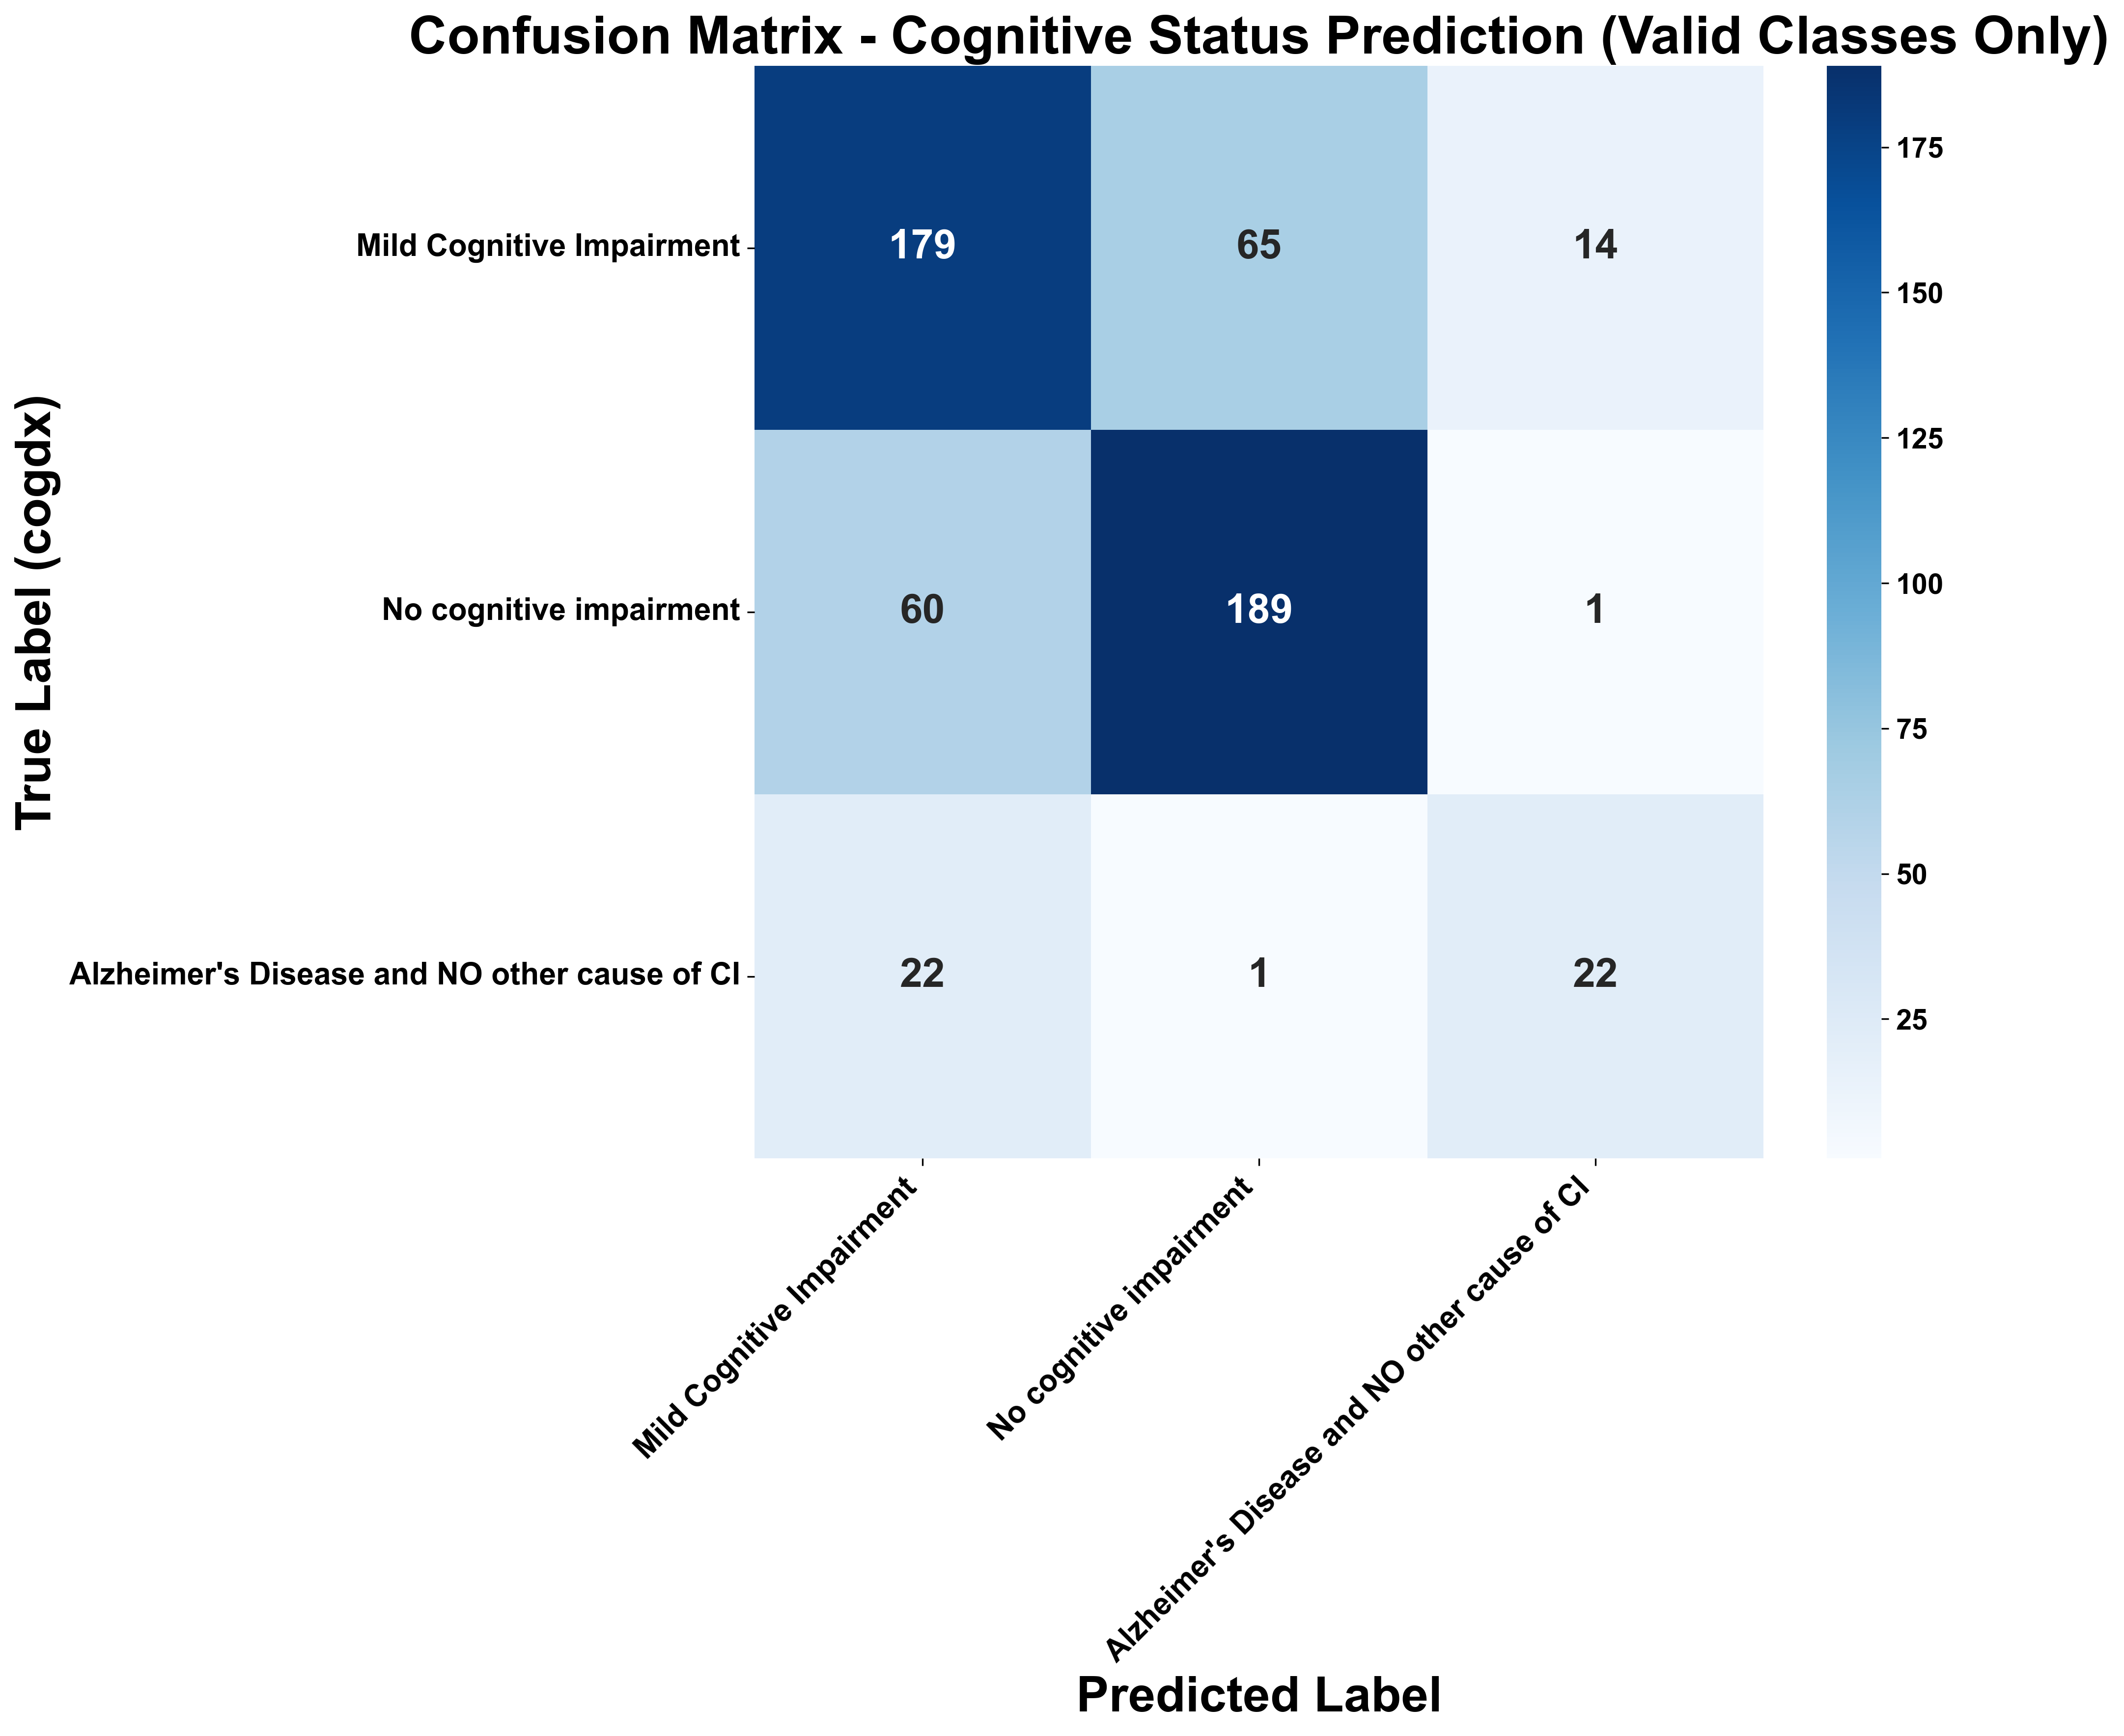


Detailed Classification Report (Valid Classes Only):
                                              precision    recall  f1-score   support

                   Mild Cognitive Impairment       0.69      0.69      0.69       258
                     No cognitive impairment       0.74      0.76      0.75       250
Alzheimer's Disease and NO other cause of CI       0.59      0.49      0.54        45

                                    accuracy                           0.71       553
                                   macro avg       0.67      0.65      0.66       553
                                weighted avg       0.70      0.71      0.70       553


Metrics DataFrame:
                                              precision    recall  f1-score  \
Mild Cognitive Impairment                      0.685824  0.693798  0.689788   
No cognitive impairment                        0.741176  0.756000  0.748515   
Alzheimer's Disease and NO other cause of CI   0.594595  0.488889  0.536585   
accur

In [100]:
##ADNI (Reduced Model)


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os

# Define the status mapping
STATUS_MAP = {
    1: "No cognitive impairment",
    2: "Mild Cognitive Impairment",
    3: "Mild cognitive impairment and another cause of CI",
    4: "Alzheimer's Disease and NO other cause of CI",
    5: "Alzheimer's Disease and another cause of CI",
    6: "Other dementia"
}

file_path = os.path.expanduser("~/Downloads/other/test_predictions_Reduced_Model_No_DERs_ADNI_othern_labeled.csv")

# Verify file exists
if not os.path.exists(file_path):
    print(f"ERROR: File not found at {file_path}")
    print("Please verify the file exists at this location.")
else:
    print(f"File found at: {file_path}")
    
    # Load the CSV file
    df = pd.read_csv(file_path)
    
    # Display first few rows
    print("\nData Preview:")
    print(df.head())
    
    # Check for required columns
    required_columns = ['predicted_cogdx', 'cogdx']
    missing_cols = [col for col in required_columns if col not in df.columns]

    if missing_cols:
        print(f"\nERROR: Missing columns: {', '.join(missing_cols)}")
        print("Available columns:", df.columns.tolist())
    else:
        # Check for missing values
        print("\nMissing Values Check:")
        print(df[required_columns].isnull().sum())
    
        # Convert to integers
        df['cogdx'] = df['cogdx'].astype(int)
        df['predicted_cogdx'] = df['predicted_cogdx'].astype(int)
        
        # Identify classes with actual support
        class_counts = df['cogdx'].value_counts()
        valid_classes = class_counts[class_counts > 0].index.tolist()
        
        # Filter both true and predicted labels to only include valid classes
        df_filtered = df[df['cogdx'].isin(valid_classes)].copy()
        
        # Also remove predictions for invalid classes (treat them as misclassifications)
        # This is important because if the model predicts a class that doesn't exist in the test set,
        # we should count it as an error
        invalid_predictions = ~df_filtered['predicted_cogdx'].isin(valid_classes)
        if invalid_predictions.sum() > 0:
            print(f"\nFound {invalid_predictions.sum()} predictions for invalid classes. These will be treated as errors.")
            # You could choose to mark these as a specific error code or just leave them as is
            # For now, we'll just note them but not change the values
        
        print(f"\nFiltered dataset size: {len(df_filtered)}")
        print("Class distribution after filtering:")
        print(df_filtered['cogdx'].value_counts())
    
        # Calculate accuracy
        correct_predictions = (df_filtered['predicted_cogdx'] == df_filtered['cogdx']).sum()
        total_samples = len(df_filtered)
        accuracy = correct_predictions / total_samples

        print(f"\nAccuracy Ratio: {correct_predictions}/{total_samples} = {accuracy:.4f} ({accuracy*100:.2f}%)")
    
        # Generate confusion matrix - only include valid classes
        cm = confusion_matrix(
            df_filtered['cogdx'], 
            df_filtered['predicted_cogdx'],
            labels=valid_classes
        )
        
        # Create labels for matrix using STATUS_MAP
        labels = [STATUS_MAP.get(label, f'Unknown ({label})') for label in valid_classes]
        
        # Plot confusion matrix
        plt.figure(figsize=(14, 12))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels,
            annot_kws={'size': 20})  # Increase annotation text size to 16
        plt.title('Confusion Matrix - Cognitive Status Prediction (Valid Classes Only)', fontsize=26)
        plt.xlabel('Predicted Label', fontsize=24, fontweight='bold')
        plt.ylabel('True Label (cogdx)', fontsize=24, fontweight='bold')
        plt.xticks(rotation=45, ha='right', fontsize=15, fontweight='bold')
        plt.yticks(rotation=0, fontsize=15, fontweight='bold')
        plt.tight_layout()
        plt.show()

        
        # Classification report - only include valid classes
        print("\nDetailed Classification Report (Valid Classes Only):")
        report = classification_report(
            df_filtered['cogdx'], 
            df_filtered['predicted_cogdx'],
            labels=valid_classes,
            target_names=[STATUS_MAP.get(i, f'Unknown ({i})') for i in valid_classes],
            zero_division=0
        )
        print(report)
        
        # Convert classification report to DataFrame for better visualization
        report_dict = classification_report(
            df_filtered['cogdx'], 
            df_filtered['predicted_cogdx'],
            labels=valid_classes,
            target_names=[STATUS_MAP.get(i, f'Unknown ({i})') for i in valid_classes],
            output_dict=True,
            zero_division=0
        )
        metrics_df = pd.DataFrame(report_dict).transpose()
        print("\nMetrics DataFrame:")
        print(metrics_df)
        
        # Additional analysis: Class-wise performance
        print("\nAdditional Analysis:")
        print("=" * 50)
        
        # Calculate class-wise accuracy
        for class_label in valid_classes:
            class_data = df_filtered[df_filtered['cogdx'] == class_label]
            class_accuracy = (class_data['predicted_cogdx'] == class_data['cogdx']).mean()
            print(f"{STATUS_MAP.get(class_label, f'Unknown ({class_label})')}: {class_accuracy:.2%} accuracy")
        
        # Most common misclassifications
        misclassifications = df_filtered[df_filtered['predicted_cogdx'] != df_filtered['cogdx']]
        if len(misclassifications) > 0:
            print(f"\nMost common misclassifications:")
            misclass_counts = misclassifications.groupby(['cogdx', 'predicted_cogdx']).size().reset_index(name='count')
            misclass_counts = misclass_counts.sort_values('count', ascending=False)
            
            for _, row in misclass_counts.head().iterrows():
                true_label = STATUS_MAP.get(row['cogdx'], f'Unknown ({row["cogdx"]})')
                pred_label = STATUS_MAP.get(row['predicted_cogdx'], f'Unknown ({row["predicted_cogdx"]})')
                print(f"  {true_label} → {pred_label}: {row['count']} cases")
        
        # Check for predictions of invalid classes
        invalid_preds = df_filtered[~df_filtered['predicted_cogdx'].isin(valid_classes)]
        if len(invalid_preds) > 0:
            print(f"\nWARNING: {len(invalid_preds)} predictions are for classes not present in the test set:")
            for class_label in invalid_preds['predicted_cogdx'].unique():
                count = (invalid_preds['predicted_cogdx'] == class_label).sum()
                print(f"  Class {class_label} ({STATUS_MAP.get(class_label, 'Unknown')}): {count} predictions")


File found at: /Users/martinnwadiugwu/Downloads/other/test_predictions_Reduced_Model_No_DERs_ROS_MAP2_labeled.csv

Data Preview:
        Age    PMI.h.  last_MMSE_29  last_MMSE_26  last_MMSE_21  \
0  1.073573  0.219879     -0.459666     -0.353852     -0.166795   
1  0.930205  0.230303     -0.459666     -0.353852     -0.166795   
2  0.010416  0.819330      2.175490     -0.353852     -0.166795   
3  0.692980  0.219879     -0.459666     -0.353852     -0.166795   
4  1.407193 -0.606467      2.175490     -0.353852     -0.166795   

   Gender_female  Highest_Education_Level_Professional  race_Asian  \
0       1.130220                             -0.334724    -0.11713   
1      -0.884783                             -0.334724    -0.11713   
2      -0.884783                             -0.334724    -0.11713   
3      -0.884783                             -0.334724    -0.11713   
4       1.130220                             -0.334724    -0.11713   

   last_MMSE_30  last_MMSE_2  ...     PC_48    

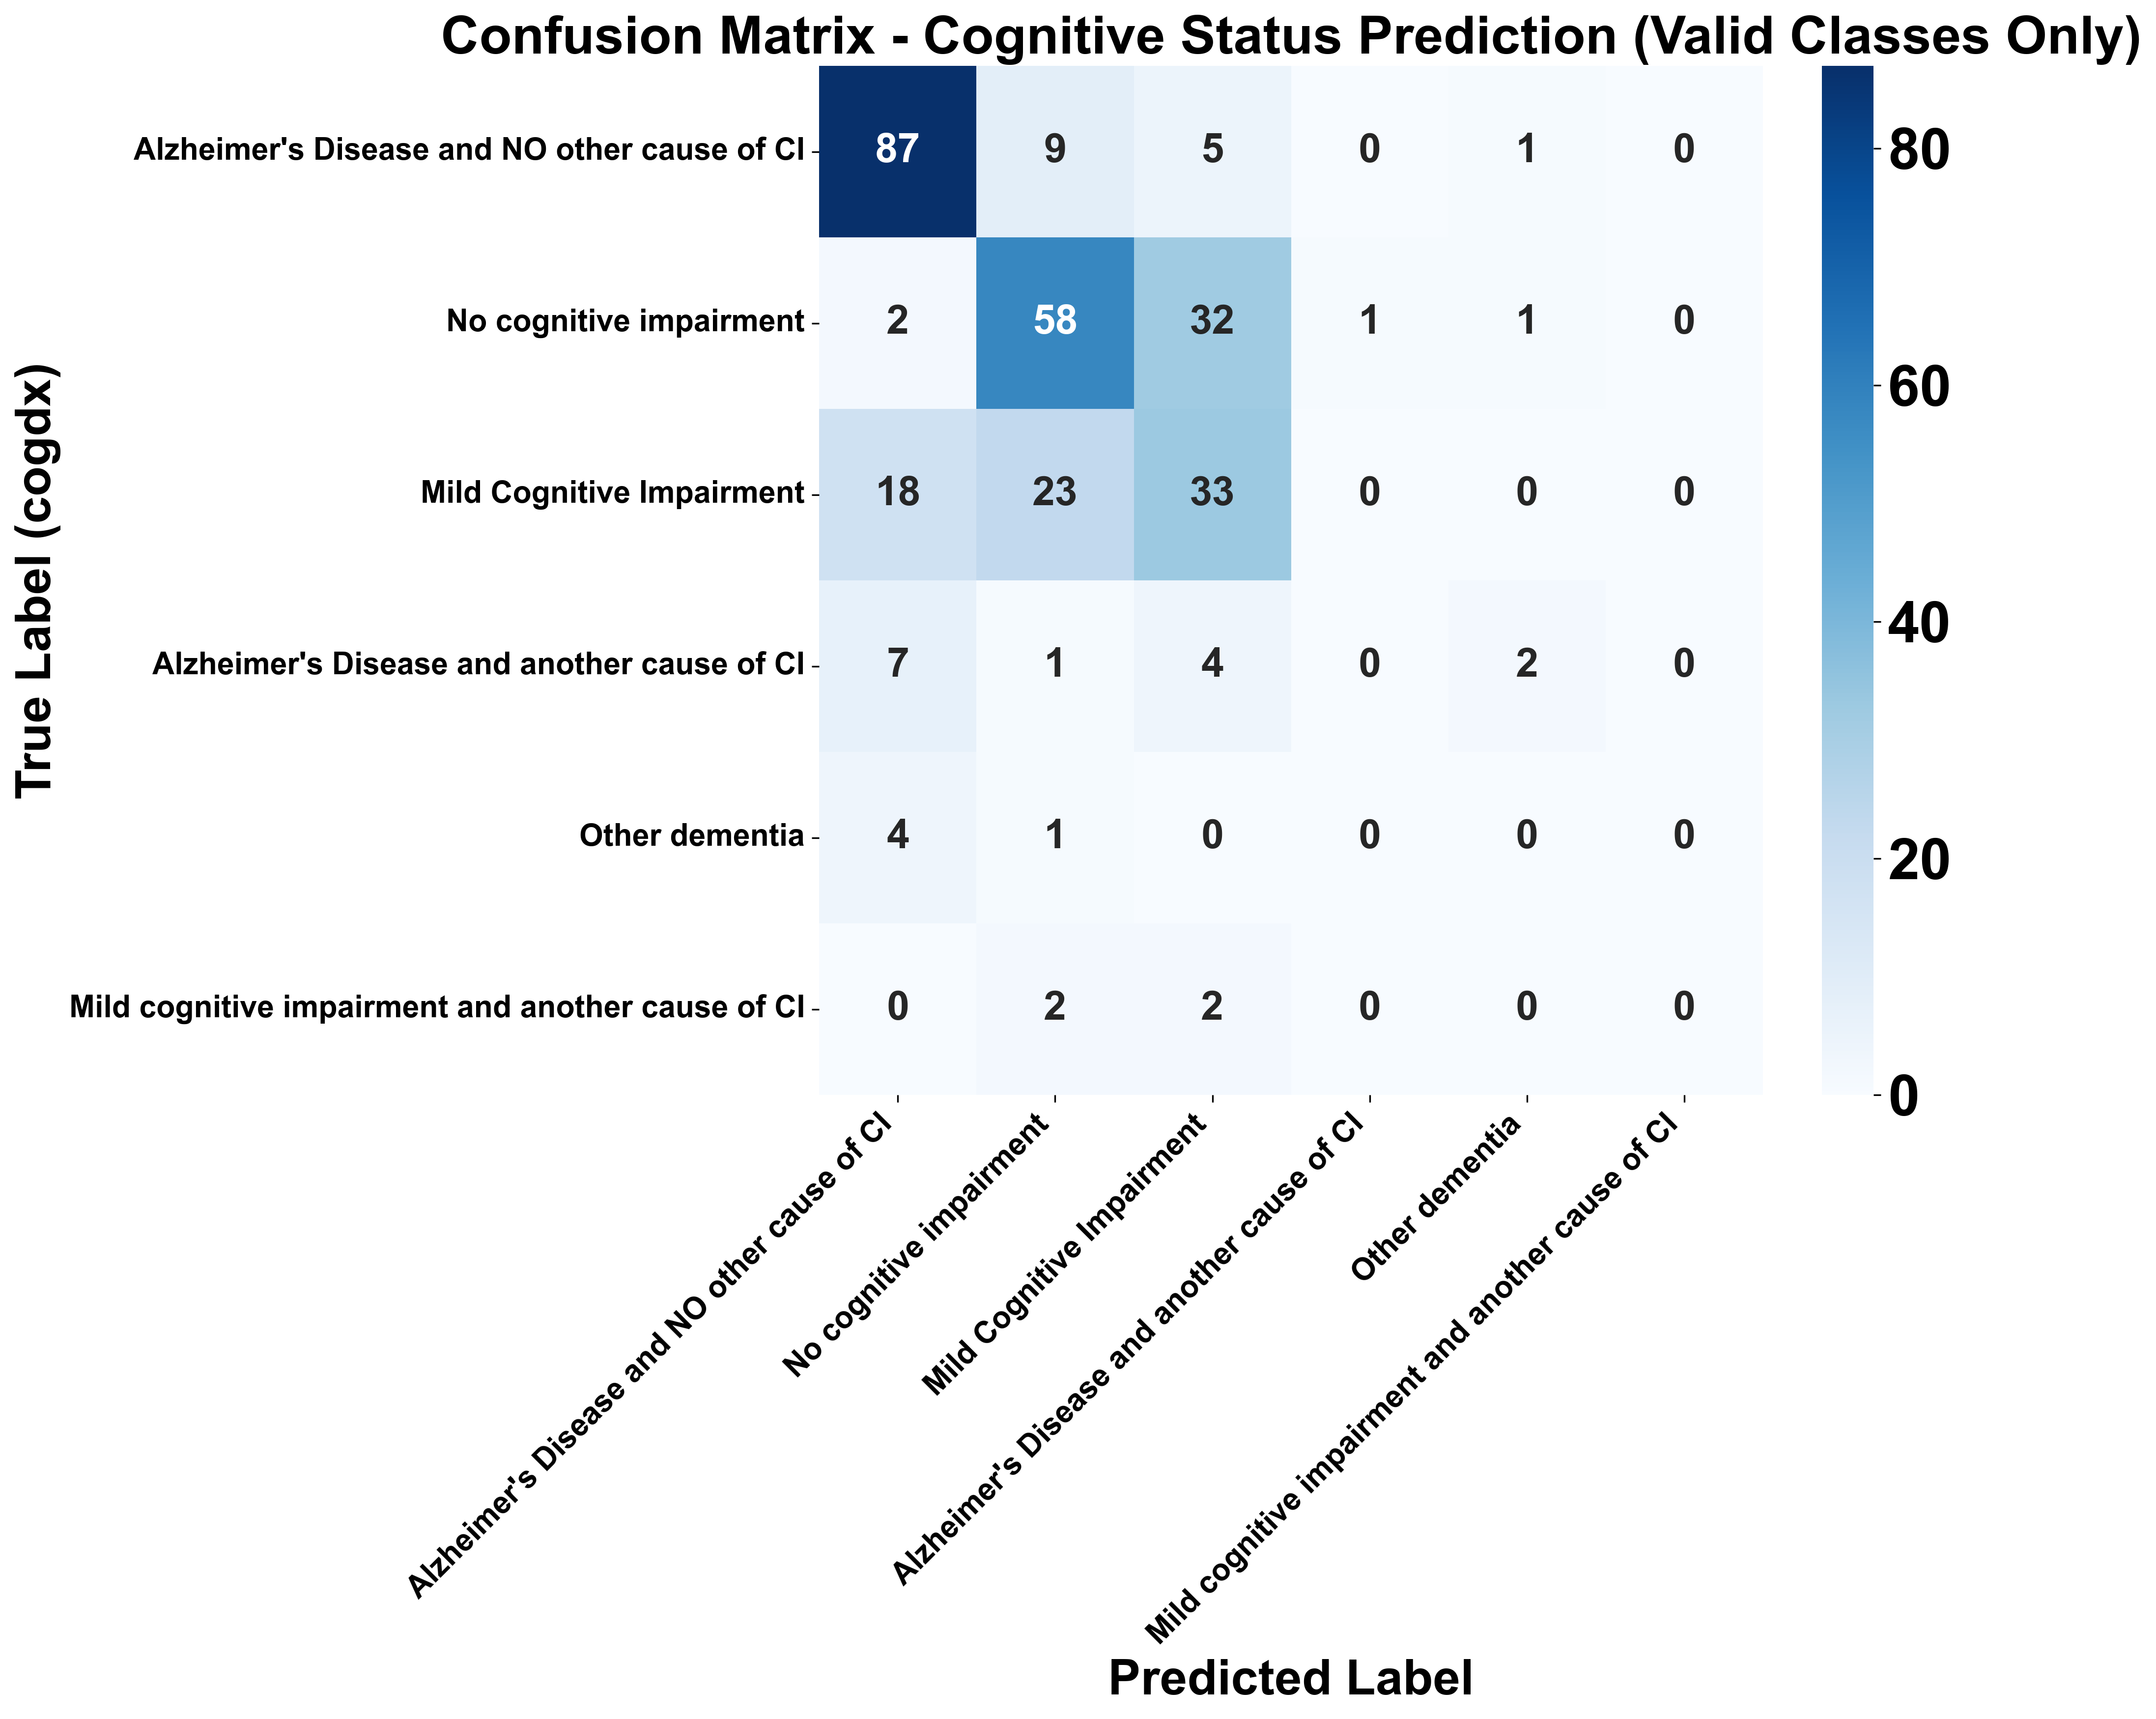


Detailed Classification Report (Valid Classes Only):
                                                   precision    recall  f1-score   support

     Alzheimer's Disease and NO other cause of CI       0.74      0.85      0.79       102
                          No cognitive impairment       0.62      0.62      0.62        94
                        Mild Cognitive Impairment       0.43      0.45      0.44        74
      Alzheimer's Disease and another cause of CI       0.00      0.00      0.00        14
                                   Other dementia       0.00      0.00      0.00         5
Mild cognitive impairment and another cause of CI       0.00      0.00      0.00         4

                                         accuracy                           0.61       293
                                        macro avg       0.30      0.32      0.31       293
                                     weighted avg       0.56      0.61      0.58       293


Metrics DataFrame:
             

In [129]:
##ROS_MAP2 (Reduced Model)


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os

# Define the status mapping
STATUS_MAP = {
    1: "No cognitive impairment",
    2: "Mild Cognitive Impairment",
    3: "Mild cognitive impairment and another cause of CI",
    4: "Alzheimer's Disease and NO other cause of CI",
    5: "Alzheimer's Disease and another cause of CI",
    6: "Other dementia"
}

file_path = os.path.expanduser("~/Downloads/other/test_predictions_Reduced_Model_No_DERs_ROS_MAP2_labeled.csv")

# Verify file exists
if not os.path.exists(file_path):
    print(f"ERROR: File not found at {file_path}")
    print("Please verify the file exists at this location.")
else:
    print(f"File found at: {file_path}")
    
    # Load the CSV file
    df = pd.read_csv(file_path)
    
    # Display first few rows
    print("\nData Preview:")
    print(df.head())
    
    # Check for required columns
    required_columns = ['predicted_cogdx', 'cogdx']
    missing_cols = [col for col in required_columns if col not in df.columns]

    if missing_cols:
        print(f"\nERROR: Missing columns: {', '.join(missing_cols)}")
        print("Available columns:", df.columns.tolist())
    else:
        # Check for missing values
        print("\nMissing Values Check:")
        print(df[required_columns].isnull().sum())
    
        # Convert to integers
        df['cogdx'] = df['cogdx'].astype(int)
        df['predicted_cogdx'] = df['predicted_cogdx'].astype(int)
        
        # Identify classes with actual support
        class_counts = df['cogdx'].value_counts()
        valid_classes = class_counts[class_counts > 0].index.tolist()
        
        # Filter both true and predicted labels to only include valid classes
        df_filtered = df[df['cogdx'].isin(valid_classes)].copy()
        
        # Also remove predictions for invalid classes (treat them as misclassifications)
        # This is important because if the model predicts a class that doesn't exist in the test set,
        # we should count it as an error
        invalid_predictions = ~df_filtered['predicted_cogdx'].isin(valid_classes)
        if invalid_predictions.sum() > 0:
            print(f"\nFound {invalid_predictions.sum()} predictions for invalid classes. These will be treated as errors.")
            # You could choose to mark these as a specific error code or just leave them as is
            # For now, we'll just note them but not change the values
        
        print(f"\nFiltered dataset size: {len(df_filtered)}")
        print("Class distribution after filtering:")
        print(df_filtered['cogdx'].value_counts())
    
        # Calculate accuracy
        correct_predictions = (df_filtered['predicted_cogdx'] == df_filtered['cogdx']).sum()
        total_samples = len(df_filtered)
        accuracy = correct_predictions / total_samples

        print(f"\nAccuracy Ratio: {correct_predictions}/{total_samples} = {accuracy:.4f} ({accuracy*100:.2f}%)")
    
        # Generate confusion matrix - only include valid classes
        cm = confusion_matrix(
            df_filtered['cogdx'], 
            df_filtered['predicted_cogdx'],
            labels=valid_classes
        )
        
        # Create labels for matrix using STATUS_MAP
        labels = [STATUS_MAP.get(label, f'Unknown ({label})') for label in valid_classes]
        
        # Plot confusion matrix
        plt.figure(figsize=(14, 12))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels,
            annot_kws={'size': 20})  # Increase annotation text size to 16
        plt.title('Confusion Matrix - Cognitive Status Prediction (Valid Classes Only)', fontsize=26)
        plt.xlabel('Predicted Label', fontsize=24, fontweight='bold')
        plt.ylabel('True Label (cogdx)', fontsize=24, fontweight='bold')
        plt.xticks(rotation=45, ha='right', fontsize=15, fontweight='bold')
        plt.yticks(rotation=0, fontsize=15, fontweight='bold')
        plt.tight_layout()
        plt.show()

        
        # Classification report - only include valid classes
        print("\nDetailed Classification Report (Valid Classes Only):")
        report = classification_report(
            df_filtered['cogdx'], 
            df_filtered['predicted_cogdx'],
            labels=valid_classes,
            target_names=[STATUS_MAP.get(i, f'Unknown ({i})') for i in valid_classes],
            zero_division=0
        )
        print(report)
        
        # Convert classification report to DataFrame for better visualization
        report_dict = classification_report(
            df_filtered['cogdx'], 
            df_filtered['predicted_cogdx'],
            labels=valid_classes,
            target_names=[STATUS_MAP.get(i, f'Unknown ({i})') for i in valid_classes],
            output_dict=True,
            zero_division=0
        )
        metrics_df = pd.DataFrame(report_dict).transpose()
        print("\nMetrics DataFrame:")
        print(metrics_df)
        
        # Additional analysis: Class-wise performance
        print("\nAdditional Analysis:")
        print("=" * 50)
        
        # Calculate class-wise accuracy
        for class_label in valid_classes:
            class_data = df_filtered[df_filtered['cogdx'] == class_label]
            class_accuracy = (class_data['predicted_cogdx'] == class_data['cogdx']).mean()
            print(f"{STATUS_MAP.get(class_label, f'Unknown ({class_label})')}: {class_accuracy:.2%} accuracy")
        
        # Most common misclassifications
        misclassifications = df_filtered[df_filtered['predicted_cogdx'] != df_filtered['cogdx']]
        if len(misclassifications) > 0:
            print(f"\nMost common misclassifications:")
            misclass_counts = misclassifications.groupby(['cogdx', 'predicted_cogdx']).size().reset_index(name='count')
            misclass_counts = misclass_counts.sort_values('count', ascending=False)
            
            for _, row in misclass_counts.head().iterrows():
                true_label = STATUS_MAP.get(row['cogdx'], f'Unknown ({row["cogdx"]})')
                pred_label = STATUS_MAP.get(row['predicted_cogdx'], f'Unknown ({row["predicted_cogdx"]})')
                print(f"  {true_label} → {pred_label}: {row['count']} cases")
        
        # Check for predictions of invalid classes
        invalid_preds = df_filtered[~df_filtered['predicted_cogdx'].isin(valid_classes)]
        if len(invalid_preds) > 0:
            print(f"\nWARNING: {len(invalid_preds)} predictions are for classes not present in the test set:")
            for class_label in invalid_preds['predicted_cogdx'].unique():
                count = (invalid_preds['predicted_cogdx'] == class_label).sum()
                print(f"  Class {class_label} ({STATUS_MAP.get(class_label, 'Unknown')}): {count} predictions")


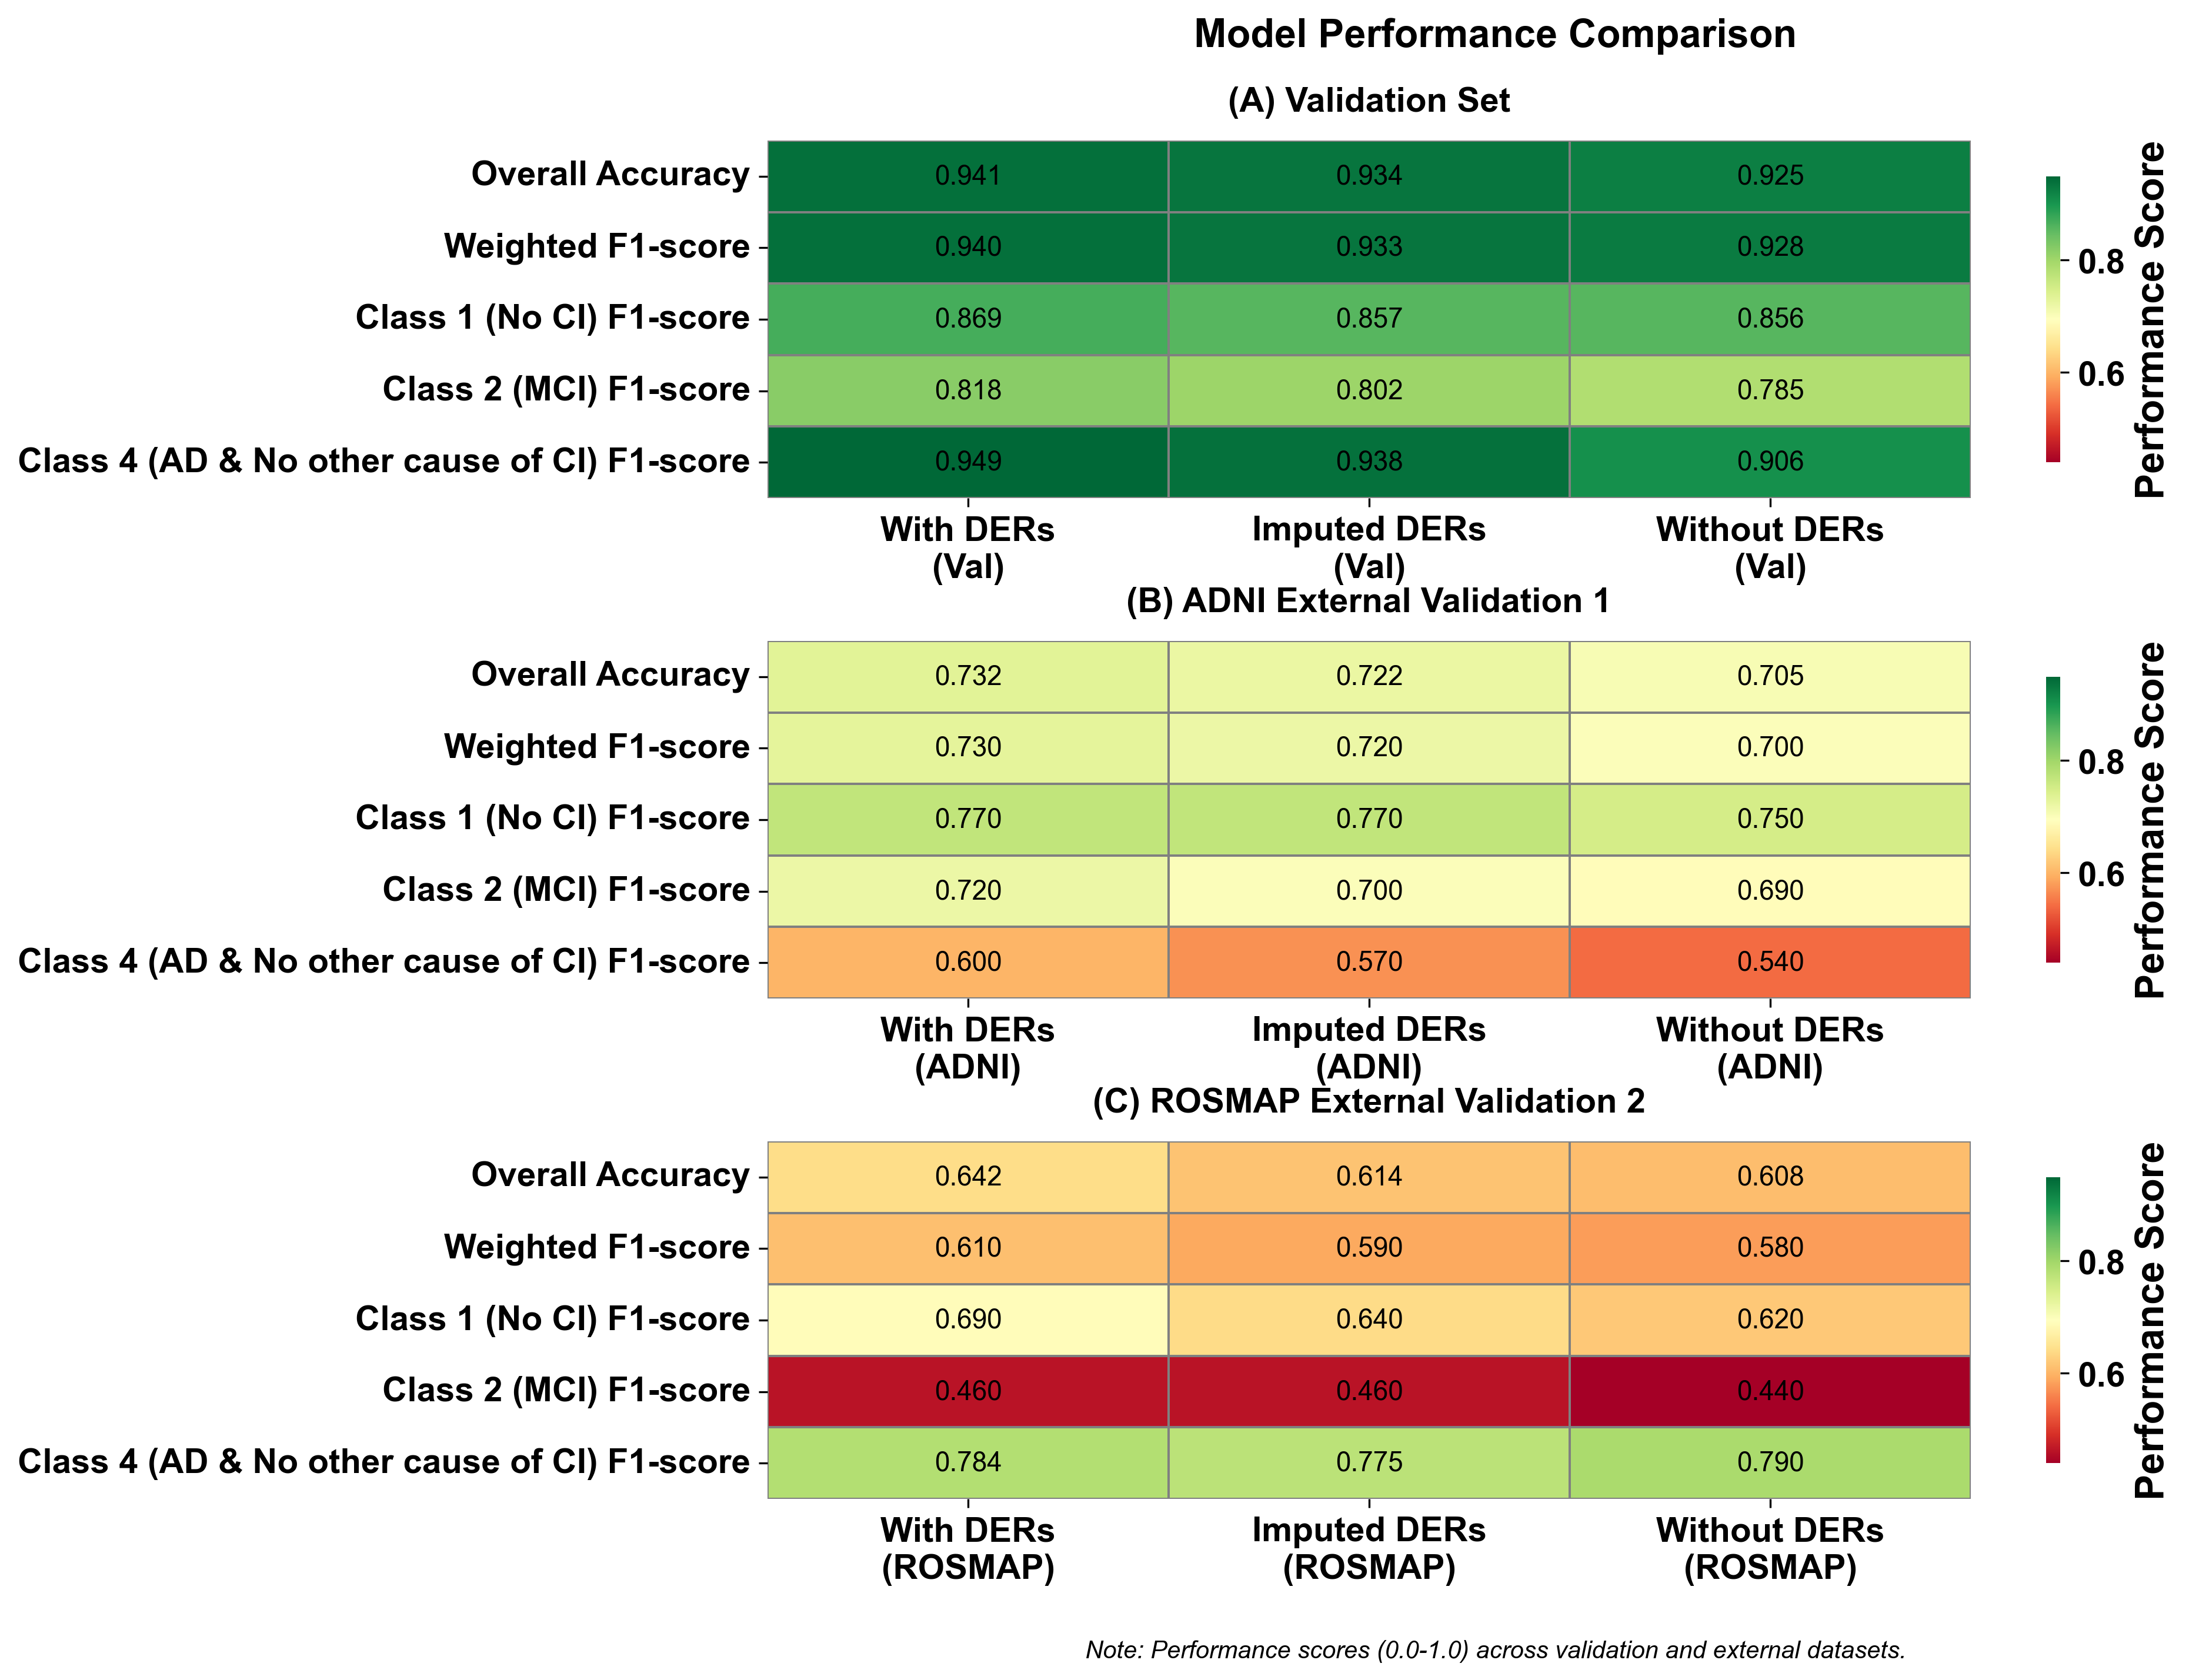

In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import Normalize

# =======================================================
# GLOBAL CLEAN FONT + EXPORT SETTINGS - INCREASED & BOLD
# =======================================================
plt.style.use("default")
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 14,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
    'font.weight': 'bold',
})

# =======================================================
# DATA – UPDATED FROM TABLE 2 (all values as decimals)
# =======================================================
metrics = [
    'Validation Balanced Accuracy',
    'Overall Accuracy',
    'Weighted F1-score',
    'Weighted Average',
    'Class 1 (No CI) F1-score',
    'Class 2 (MCI) F1-score',
    'Class 3 (MCI & another cause of CI) F1-score',
    'Class 4 (AD & No other cause of CI) F1-score',
    'Class 5 (AD & another cause of CI) F1-score',
    'Class 6 (Other dementia) F1-score'
]

data = {
    # --- Validation Set ---
    'With DERs (Val)': [
        0.9404, 0.9407, 0.9397, 0.9393, 0.869, 0.818, 1.000, 0.949, 1.000, 1.000
    ],
    'Imputed DERs (Val)': [
        0.9334, 0.9337, 0.9331, 0.9329, 0.857, 0.802, 1.000, 0.938, 1.000, 1.000
    ],
    'Without DERs (Val)': [
        0.9247, 0.9250, 0.9276, 0.9245, 0.856, 0.785, 1.000, 0.906, 1.000, 1.000
    ],

    # --- ADNI External Validation 1 ---
    'With DERs (ADNI)': [
        0.6841, 0.7324, 0.730, 0.690, 0.770, 0.720, 0.000, 0.600, 0.000, 0.000
    ],
    'Imputed DERs (ADNI)': [
        0.6765, 0.7215, 0.720, 0.680, 0.770, 0.700, 0.000, 0.570, 0.000, 0.000
    ],
    'Without DERs (ADNI)': [
        0.6462, 0.7052, 0.700, 0.660, 0.750, 0.690, 0.000, 0.540, 0.000, 0.000
    ],

    # --- ROSMAP External Validation 2 ---
    'With DERs (ROSMAP)': [
        0.3366, 0.6416, 0.610, 0.320, 0.690, 0.460, 0.000, 0.7838, 0.000, 0.000
    ],
    'Imputed DERs (ROSMAP)': [
        0.3249, 0.6143, 0.590, 0.310, 0.640, 0.460, 0.000, 0.775, 0.000, 0.000
    ],
    'Without DERs (ROSMAP)': [
        0.3193, 0.6075, 0.580, 0.310, 0.620, 0.440, 0.000, 0.790, 0.000, 0.000
    ]
}

df = pd.DataFrame(data, index=metrics)

# =======================================================
# HEATMAPS – SHOW SELECTED METRICS (same as before)
# =======================================================
groups = {
    'Validation Set': ['With DERs (Val)', 'Imputed DERs (Val)', 'Without DERs (Val)'],
    'ADNI External Validation 1': ['With DERs (ADNI)', 'Imputed DERs (ADNI)', 'Without DERs (ADNI)'],
    'ROSMAP External Validation 2': ['With DERs (ROSMAP)', 'Imputed DERs (ROSMAP)', 'Without DERs (ROSMAP)']
}

# Keep the same five key metrics as in the original code,
# but note that "Overall Accuracy" and "Macro F1-score" are now correct.
metrics_to_plot = [
    'Overall Accuracy',
    'Weighted F1-score',
    'Class 1 (No CI) F1-score',
    'Class 2 (MCI) F1-score',
    'Class 4 (AD & No other cause of CI) F1-score'
]

df_plot = df.loc[metrics_to_plot]

fig, axs = plt.subplots(3, 1, figsize=(11, 10), gridspec_kw={'hspace': 0.4})

norm = Normalize(vmin=df_plot.values.min(), vmax=df_plot.values.max())
cmap = plt.cm.RdYlGn

for i, (group_name, cols) in enumerate(groups.items()):
    ax = axs[i]
    df_group = df_plot[cols]
    
    sns.heatmap(
        df_group,
        ax=ax,
        cmap=cmap,
        norm=norm,
        annot=True,
        fmt=".3f",
        annot_kws={'fontsize': 11, 'fontweight': 'normal', 'color': 'black'},
        linewidths=0.5,
        linecolor='gray',
        cbar_kws={'label': 'Performance Score', 'shrink': 0.8}
    )
    
    ax.set_title(f"({chr(65 + i)}) {group_name}", fontsize=14, fontweight="bold", pad=12)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, ha='right')
    ax.set_xticklabels([x.replace(" (", "\n(") for x in cols], rotation=0, ha='center')

fig.suptitle("Model Performance Comparison", 
             fontsize=16, y=0.95, fontweight="bold")
fig.text(0.5, 0.02, "Note: Performance scores (0.0-1.0) across validation and external datasets.", 
         ha="center", fontsize=10, fontweight="normal", style="italic")

# Save the figure
plt.savefig("/Users/martinnwadiugwu/Downloads/performance_heatmap_imputed11.pdf", 
            dpi=300, bbox_inches="tight", facecolor='white', edgecolor='none')
plt.show()

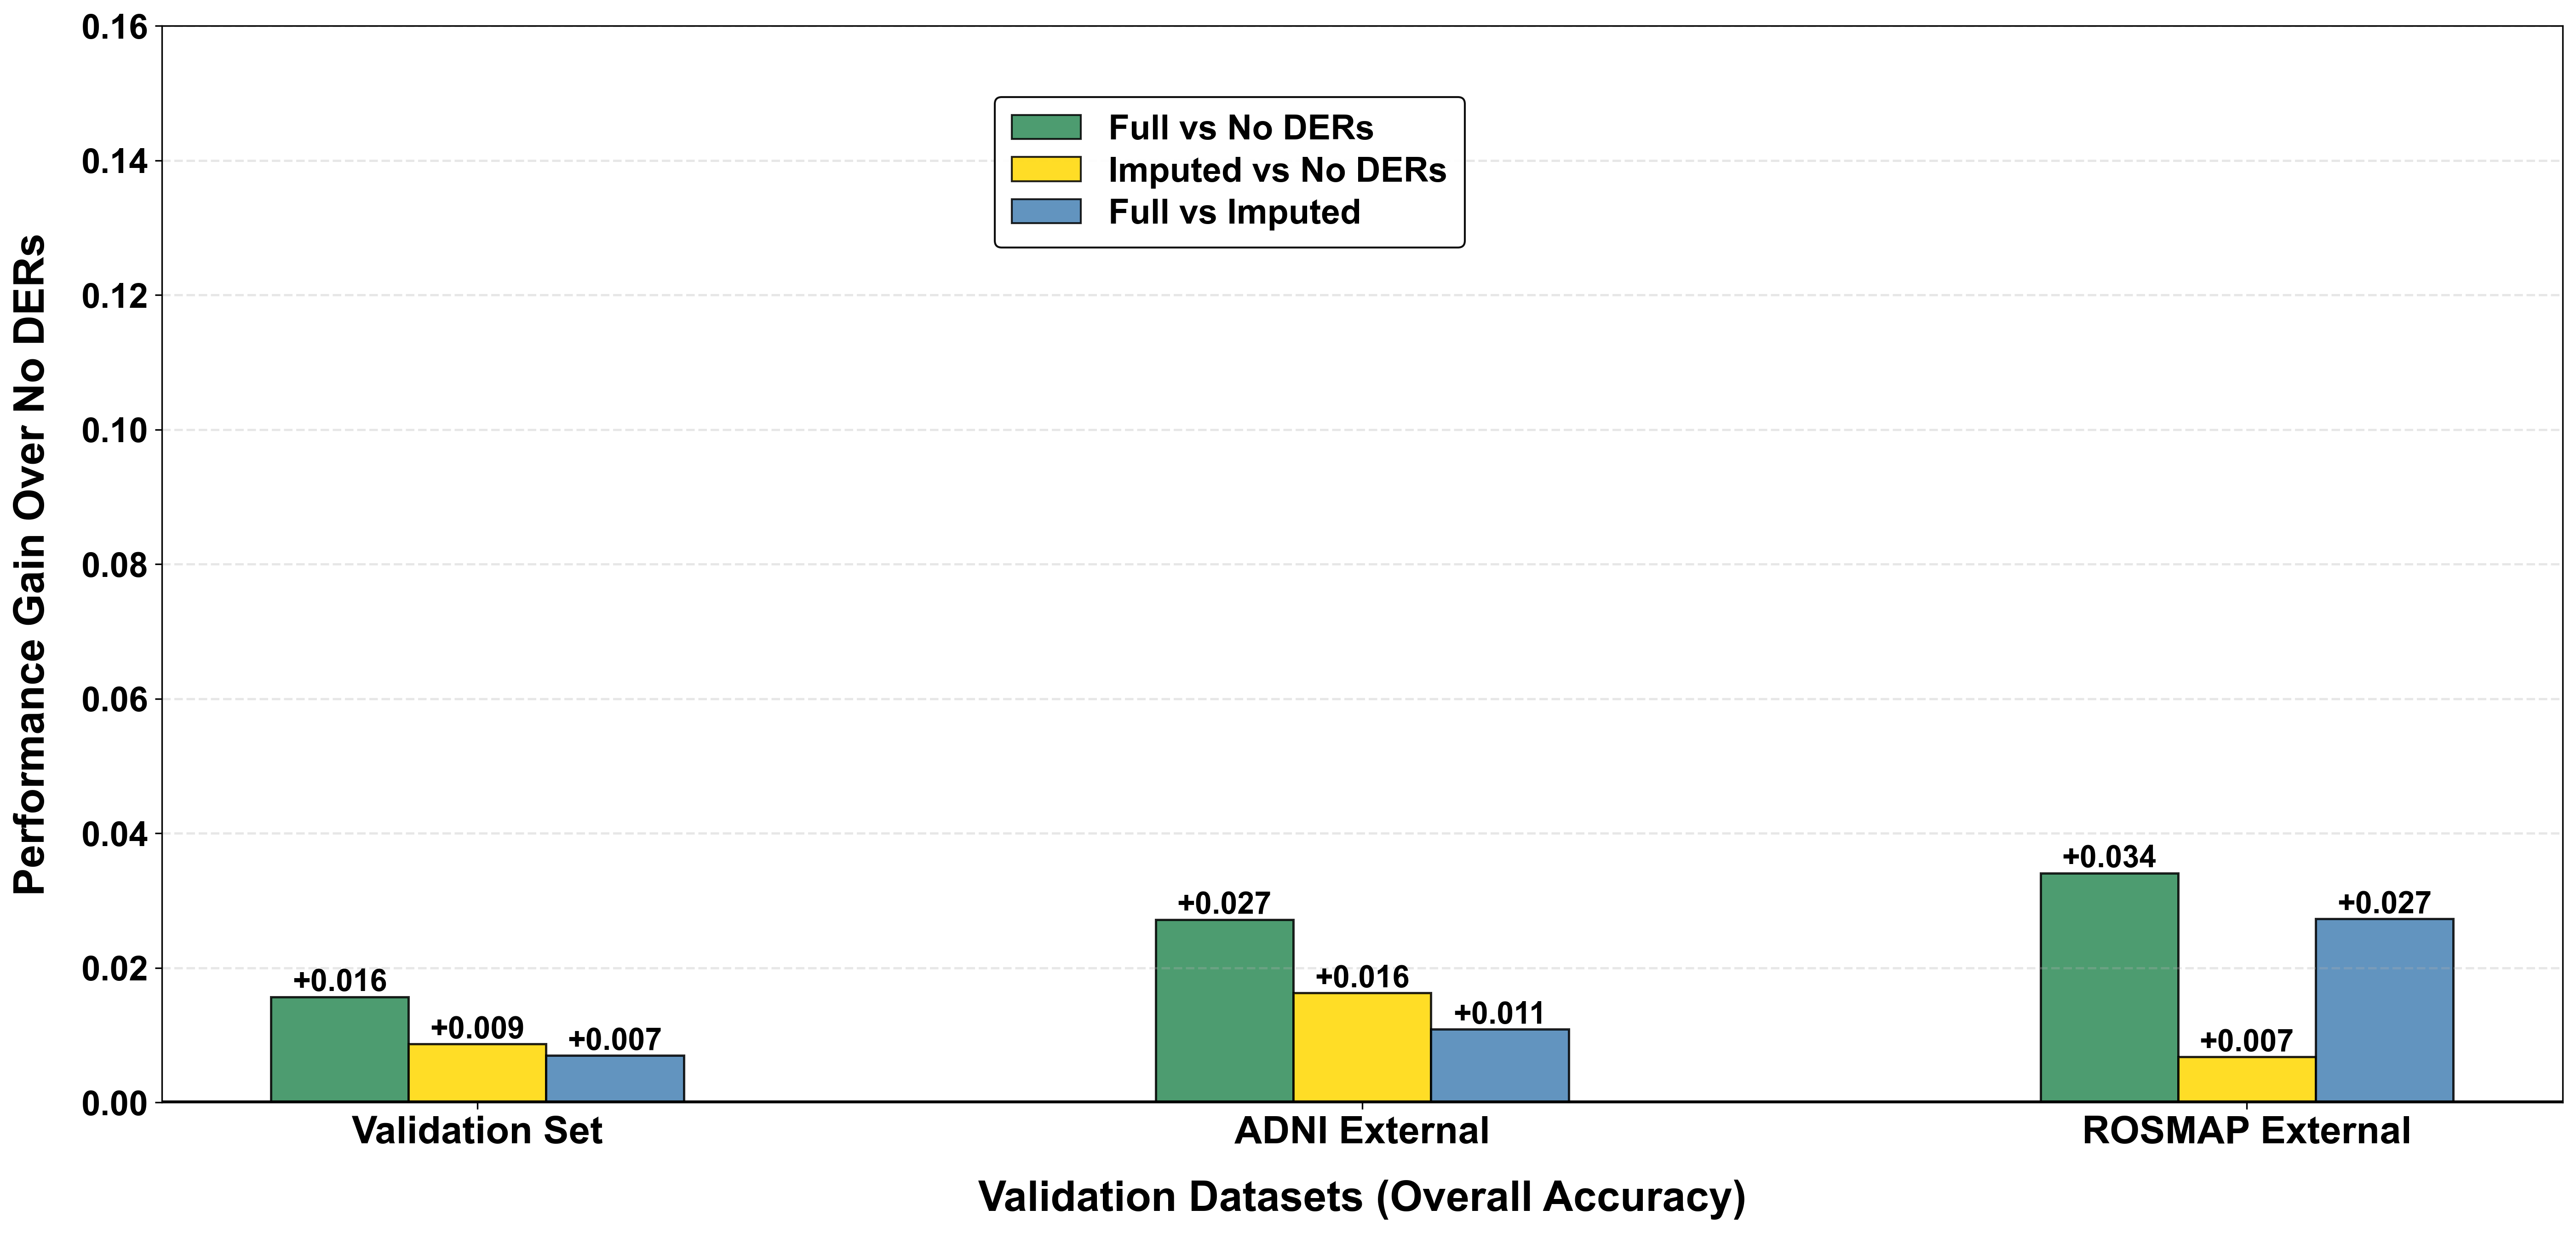


PERFORMANCE GAIN ANALYSIS SUMMARY - OVERALL ACCURACY
Dataset                 Full vs Reduced   Imputed vs Reduced  Full vs Imputed   Recovery Rate
----------------------------------------------------------------------------------------------------
Validation Set                  +0.0157              +0.0087          +0.0070          55.41%
ADNI External                   +0.0272              +0.0163          +0.0109          59.93%
ROSMAP External                 +0.0341              +0.0068          +0.0273          19.94%

Interpretation:
- A recovery rate near 100% means imputed DERs nearly completely restore the performance lost when removing DERs.
- Rates above 100% indicate imputed DERs actually outperform the full DER method (possible if imputation corrects some noise).
- Rates below 0% suggest imputed DERs perform worse than having no DERs at all.


In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import Normalize
from matplotlib.patches import Patch

# =======================================================
# GLOBAL CLEAN FONT + EXPORT SETTINGS - INCREASED & BOLD
# =======================================================
plt.style.use("default")
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 16,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'axes.labelsize': 20,
    'axes.titlesize': 22,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 18,
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
    'font.weight': 'bold',
})

# =======================================================
# DATA - INCLUDING IMPUTED DERS
# =======================================================
metrics = [
    'Validation Balanced Accuracy',
    'Overall Accuracy',
    'Macro F1-score',
    'Weighted Average',
    'Class 1 (No CI) F1-score',
    'Class 2 (MCI) F1-score',
    'Class 3 (MCI & another cause of CI) F1-score',
    'Class 4 (AD & No other cause of CI) F1-score',
    'Class 5 (AD & another cause of CI) F1-score',
    'Class 6 (Other dementia) F1-score'
]

data = {
    # --- Validation Set ---
    'With DERs (Val)': [
        0.9404, 0.9407, 0.9393, 0.9397, 0.869, 0.818, 1.000, 0.949, 1.000, 1.000
    ],
    'Imputed DERs (Val)': [
        0.9334, 0.9337, 0.9329, 0.9331, 0.857, 0.802, 1.000, 0.938, 1.000, 1.000
    ],
    'Without DERs (Val)': [
        0.9247, 0.9250, 0.9245, 0.9276, 0.856, 0.785, 1.000, 0.906, 1.000, 1.000
    ],

    # --- ADNI External Validation 1 ---
    'With DERs (ADNI)': [
        0.6841, 0.7324, 0.690, 0.730, 0.770, 0.720, 0.000, 0.600, 0.000, 0.000
    ],
    'Imputed DERs (ADNI)': [
        0.6765, 0.7215, 0.680, 0.720, 0.770, 0.700, 0.000, 0.570, 0.000, 0.000
    ],
    'Without DERs (ADNI)': [
        0.6462, 0.7052, 0.660, 0.700, 0.750, 0.690, 0.000, 0.540, 0.000, 0.000
    ],

    # --- ROSMAP External Validation 2 ---
    'With DERs (ROSMAP)': [
        0.3366, 0.6416, 0.320, 0.610, 0.690, 0.460, 0.000, 0.7838, 0.000, 0.000
    ],
    'Imputed DERs (ROSMAP)': [
        0.3249, 0.6143, 0.310, 0.590, 0.640, 0.460, 0.000, 0.775, 0.000, 0.000
    ],
    'Without DERs (ROSMAP)': [
        0.3193, 0.6075, 0.310, 0.580, 0.620, 0.440, 0.000, 0.790, 0.000, 0.000
    ]
}

df = pd.DataFrame(data, index=metrics)


# =======================================================
# ENHANCED PERFORMANCE GAIN ANALYSIS - BIGGER PLOT
# =======================================================
fig, ax = plt.subplots(figsize=(20, 10))

summary_metrics = ['Overall Accuracy']
datasets = ['Validation Set', 'ADNI External', 'ROSMAP External']
suffixes = ['(Val)', '(ADNI)', '(ROSMAP)']

colors = {
    'Full vs Reduced': '#2E8B57',      # Green
    'Imputed vs Reduced': '#FFD700',   # Gold
    'Full vs Imputed': '#4682B4'       # Blue
}

# Prepare data (also store gains for later recovery rate calculation)
gains = []  # store (full_reduced, imputed_reduced)
for dataset, suffix in zip(datasets, suffixes):
    metric = 'Overall Accuracy'
    full = df.loc[metric, f'With DERs {suffix}']
    reduced = df.loc[metric, f'Without DERs {suffix}']
    imputed = df.loc[metric, f'Imputed DERs {suffix}']
    
    full_vs_reduced = full - reduced
    imputed_vs_reduced = imputed - reduced
    full_vs_imputed = full - imputed
    
    gains.append({
        'Dataset': dataset,
        'Full vs Reduced': full_vs_reduced,
        'Imputed vs Reduced': imputed_vs_reduced,
        'Full vs Imputed': full_vs_imputed,
        'Full': full,
        'Reduced': reduced,
        'Imputed': imputed
    })

df_comp = pd.DataFrame(gains)

# Plotting
x_positions = []
x_labels = []
bar_width = 0.35
group_spacing = 1.2

for i, dataset in enumerate(datasets):
    base_pos = i * (bar_width * 3 + group_spacing)
    row = df_comp[df_comp['Dataset'] == dataset]
    
    pos1 = base_pos
    pos2 = base_pos + bar_width
    pos3 = base_pos + 2 * bar_width
    
    bar1 = ax.bar(pos1, row['Full vs Reduced'].values[0], bar_width, 
                  color=colors['Full vs Reduced'], alpha=0.85, edgecolor='black', linewidth=1.2)
    bar2 = ax.bar(pos2, row['Imputed vs Reduced'].values[0], bar_width, 
                  color=colors['Imputed vs Reduced'], alpha=0.85, edgecolor='black', linewidth=1.2)
    bar3 = ax.bar(pos3, row['Full vs Imputed'].values[0], bar_width, 
                  color=colors['Full vs Imputed'], alpha=0.85, edgecolor='black', linewidth=1.2)
    
    for bar in [bar1, bar2, bar3]:
        h = bar[0].get_height()
        ax.text(bar[0].get_x() + bar[0].get_width() / 2, h,
                f"{h:+.3f}",
                ha="center", va="bottom",
                fontsize=16, fontweight="bold")

    x_positions.append(base_pos + bar_width)
    x_labels.append(dataset)

ax.set_xlabel("Validation Datasets (Overall Accuracy)", fontweight="bold", fontsize=22, labelpad=15)
ax.set_ylabel("Performance Gain Over No DERs", fontweight="bold", fontsize=22, labelpad=15)
#ax.set_title("(D) Performance Gain Analysis\n" + 
 #            "Full vs No DERs | Imputed vs No DERs | Full vs Imputed",
  #           fontweight="bold", pad=35, fontsize=24)

ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels, fontweight="bold", fontsize=20, rotation=0)

legend_elements = [
    Patch(facecolor=colors['Full vs Reduced'], alpha=0.85, edgecolor='black', 
          label='Full vs No DERs'),
    Patch(facecolor=colors['Imputed vs Reduced'], alpha=0.85, edgecolor='black', 
          label='Imputed vs No DERs'),
    Patch(facecolor=colors['Full vs Imputed'], alpha=0.85, edgecolor='black', 
          label='Full vs Imputed')
]

ax.legend(handles=legend_elements, 
          loc='upper right',
          bbox_to_anchor=(0.55, 0.95),
          fontsize=18, prop={'weight': 'bold'},
          frameon=True,
          edgecolor='black',
          facecolor='white',
          framealpha=0.95,
          borderpad=0.5,
          labelspacing=0.3)

ax.grid(True, alpha=0.3, axis='y', linestyle='--', linewidth=1.2, zorder=0)
ax.axhline(y=0, color='black', linewidth=2, linestyle='-', zorder=10)
ax.set_ylim(0, 0.16)

plt.tight_layout()
fig.subplots_adjust(left=0.08, right=0.95, top=0.90, bottom=0.12)

plt.savefig("/Users/martinnwadiugwu/Downloads/performance_comprehensive_gain_analysisAA.pdf", 
            dpi=300, bbox_inches="tight")
plt.show()

# =======================================================
# SUMMARY TABLE (GAINS) + RECOVERY RATES
# =======================================================
print("\n" + "="*100)
print("PERFORMANCE GAIN ANALYSIS SUMMARY - OVERALL ACCURACY")
print("="*100)
print(f"{'Dataset':<20} {'Full vs Reduced':>18} {'Imputed vs Reduced':>20} {'Full vs Imputed':>16} {'Recovery Rate':>15}")
print("-"*100)

for row in gains:
    dataset = row['Dataset']
    full_vs_reduced = row['Full vs Reduced']
    imputed_vs_reduced = row['Imputed vs Reduced']
    full_vs_imputed = row['Full vs Imputed']
    
    # Compute recovery rate: (Imputed - Reduced) / (Full - Reduced) * 100
    if full_vs_reduced != 0:
        recovery = (imputed_vs_reduced / full_vs_reduced) * 100
    else:
        recovery = np.nan
    
    print(f"{dataset:<20} {full_vs_reduced:>+18.4f} {imputed_vs_reduced:>+20.4f} "
          f"{full_vs_imputed:>+16.4f} {recovery:>14.2f}%")

print("="*100)

# Optional: Additional interpretation
print("\nInterpretation:")
print("- A recovery rate near 100% means imputed DERs nearly completely restore the performance lost when removing DERs.")
print("- Rates above 100% indicate imputed DERs actually outperform the full DER method (possible if imputation corrects some noise).")
print("- Rates below 0% suggest imputed DERs perform worse than having no DERs at all.")

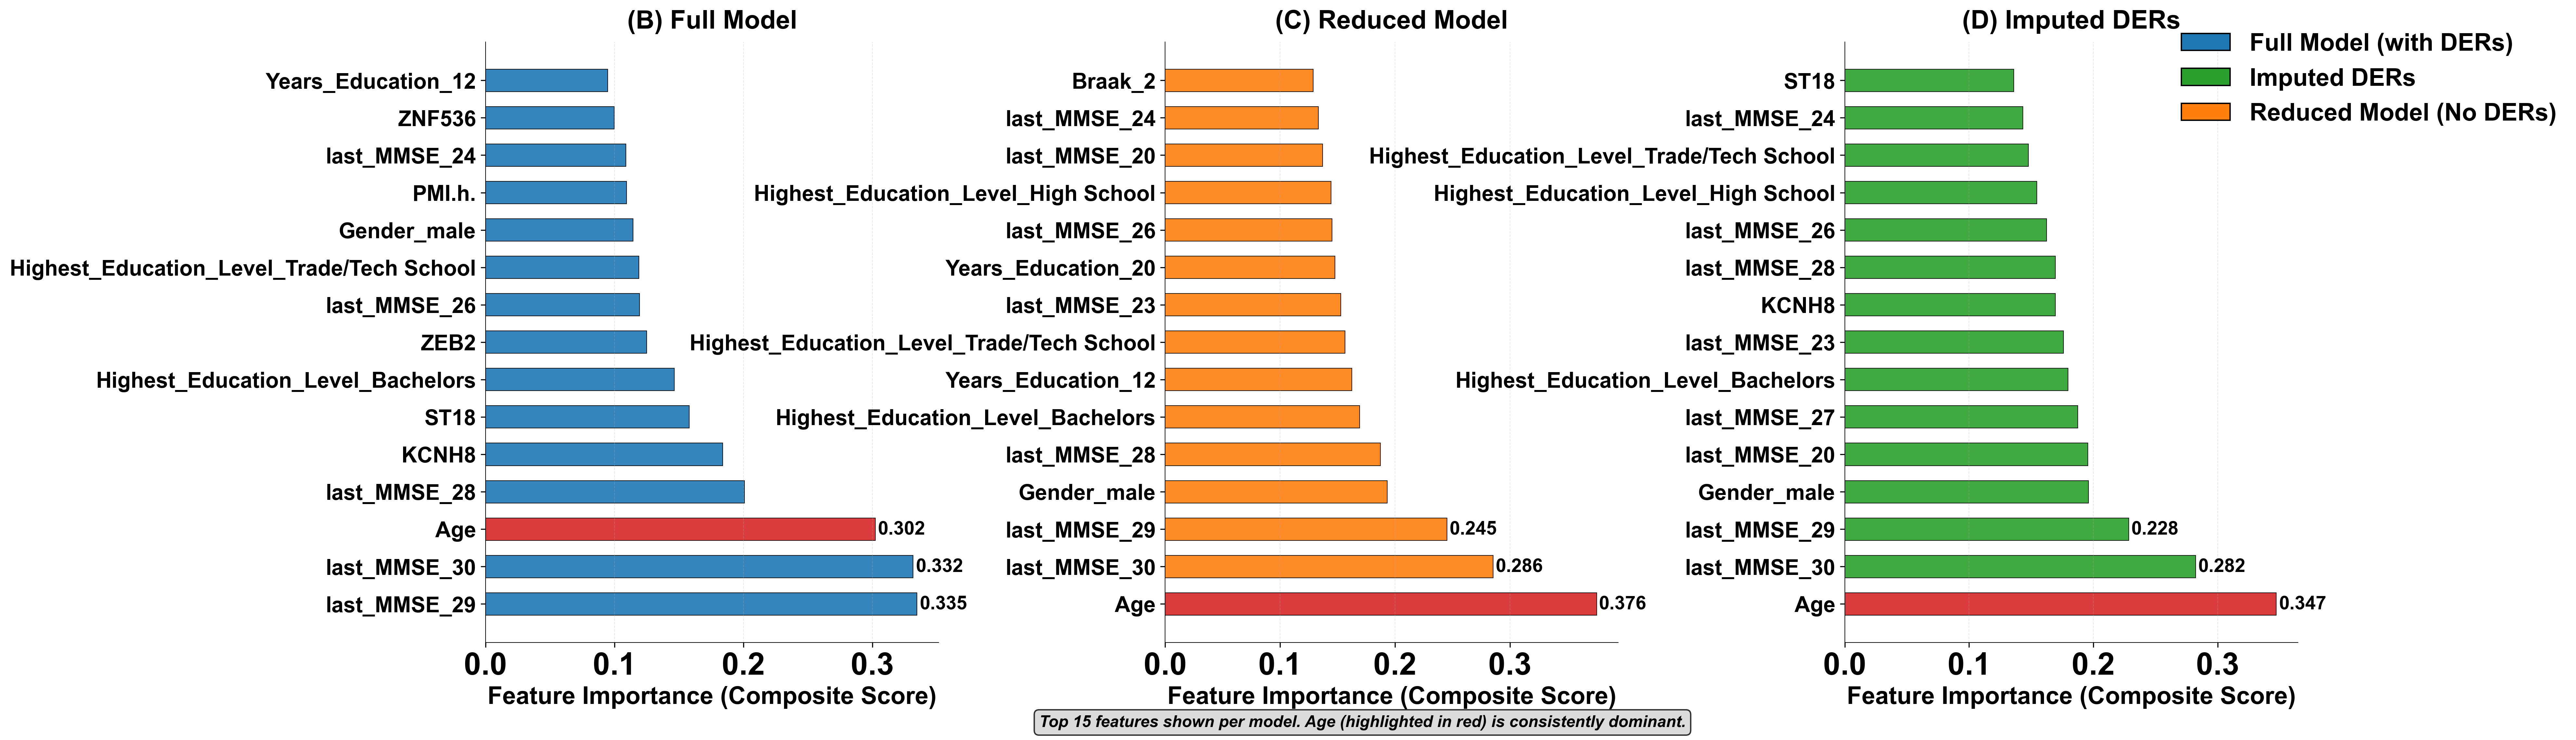

In [112]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re
from matplotlib import gridspec
from matplotlib.patches import Patch

# =======================================================
# GLOBAL CLEAN FONT SETTINGS - INCREASED & BOLD
# =======================================================
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 18,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'pdf.fonttype': 42,
    'axes.labelsize': 15,
    'axes.titlesize': 16,
    'xtick.labelsize': 23,
    'ytick.labelsize': 28,
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
    'font.weight': 'bold',
})

# =======================================================
# CORRECT FEATURE IMPORTANCE DATA (from the three tables at the end of your message)
# =======================================================
correct_data = """
FULL model: feature	MI_score	MI_rank	is_DER	domain_stability	native_importance	native_stddev	perm_mean_ROS_MAP2	perm_std_ROS_MAP2	perm_mean_ADNI_othern	perm_std_ADNI_othern	perm_mean_avg	MI_norm	perm_norm	native_norm	stability	raw_composite	composite_score	composite_rank
last_MMSE_29	0.036165390099869965	17	FALSE	0.6404592337377931	0.017479897660818755	0.003858964	0.034410788	0.004731254	0.074523686	0.015663001	0.054467236992792156	0.20309288398071823	0.7562877325409402	0.5959054209919261	0.6404592337377931	0.522573958	0.33468731649271816	1
last_MMSE_30	0.070217783	5	FALSE	0.42089161729594604	0.030285087719298266	0.004724401	0.039159779	0.004979598	0.10621464254952624	0.015359662927215115	0.072687211	0.394319872	1	1	0.42089161729594604	0.788011955	0.331667626	2
Age	0.17807315249560163	1	FALSE	0.47900493149080126	0.028402778	0.006859832	-0.006223902	0.005353751	0.019237209302325566	0.007283939	0.006506654	1	0.1147619769176382	0.940599769	0.47900493149080126	0.6310547330969285	0.30227832919404013	3
last_MMSE_28	0.036723052	16	FALSE	0.7874800429979544	0.007174708	0.00238188	0.016311774853702228	0.006236746	0.022569165	0.007030749	0.01944047	0.20622452906854424	0.28776604783896437	0.2707035755478669	0.7874800429979544	0.25496089819654294	0.2007766190746107	4
KCNH8	0.098294945	3	TRUE	0.705763271	0.007001096	0.003594059	-0.011096708	0.003227871	0.007333678	0.0046671	-0.001881515	0.5519919414474957	0.00256096	0.26522491349481053	0.705763271	0.260527792	0.18387094651709446	5
ST18	0.090292725	4	TRUE	0.5869884289941346	0.004714912	0.003301893	0.002308347	0.003114754	0.009731611	0.005773787	0.006019979	0.5070541145688133	0.10825216664646387	0.19307958477508533	0.5869884289941346	0.26903970295144153	0.1579231925725153	6
Highest_Education_Level_Bachelors	0.050874346	9	FALSE	0.8208884880979557	0.005964912	0.001226677	-0.000454867	0.002086107	0.003858398	0.003302635	0.001701766	0.2856935193099525	0.050491297	0.23252595155709394	0.8208884880979557	0.1783207383121969	0.14638144126961053	7
ZEB2	0.049056495	10	TRUE	0.7093586051961389	0.007527412	0.0042107	-0.003669189	0.005459935	0.002982601	0.008651303	-0.000343294	0.2754850728659735	0.02313637	0.2818339100346017	0.7093586051961389	0.17613280104391899	0.12494131807780341	8
last_MMSE_26	0.062135453	6	FALSE	0.6147395254312993	0.004184942	0.001473668	0.004882041	0.002441963	0.001483549	0.007907822	0.003182795	0.3489321810107206	0.070301697	0.17635524798154564	0.6147395254312993	0.19433575417112603	0.11946586929349165	9
Highest_Education_Level_Trade/Tech School	0.019973828745002642	29	FALSE	0.8630920185507901	0.005964912	0.002767757	-0.003359586	0.002450072	0.014349009474590845	0.003034155	0.005494712	0.11216642410762055	0.10122613744221905	0.2325259515570943	0.8630920185507901	0.1378801913038284	0.11900329263059034	10
Gender_male	0.046602165572791954	12	FALSE	0.940736254	0.00122807	0.001664357	0.0036659	0.003078126	-0.004352455	0.006335133	-0.000343277	0.2617023673680569	0.023136588	0.083044983	0.940736254	0.12161170934842885	0.11440454395124833	11
PMI.h.	0.13519842009878547	2	FALSE	0.26709717736406957	0.0103125	0.003031779	-0.002464041	0.003045136	0.017440482342807893	0.007144314	0.007488221	0.7592296660335973	0.12789152112179528	0.36972318339100413	0.26709717736406957	0.4093177874082282	0.10932762566164406	12
last_MMSE_24	0.024247890047350618	26	FALSE	0.7600329697626814	0.001575292	0.003248355	0.010525732240375502	0.003140318	0.012222911283376336	0.005020589	0.011374322	0.13616814049467416	0.17987241380933178	0.094002307	0.7600329697626814	0.1431083913981374	0.10876709571228656	13
ZNF536	0.042415186	13	TRUE	0.6934285370802155	0.005946637	0.002767757	0.00111222	0.002711613	-0.004356934	0.006581207	-0.001622357	0.2381896751383921	0.006027487	0.2319492502883501	0.6934285370802155	0.1437646938025063	0.099690541	14
Years_Education_12	0.054976247	7	FALSE	0.7341794930401444	0.000350877	0.001612169	-0.002694058	0.001517842	0.0012882	0.003867443	-0.000702929	0.3087284397102611	0.018325847845965436	0.055363322	0.7341794930401444	0.12922612348680426	0.09487517	15

REDUCED model: feature	MI_score	MI_rank	is_DER	domain_stability	native_importance	native_stddev	perm_mean_ROS_MAP2	perm_std_ROS_MAP2	perm_mean_ADNI_othern	perm_std_ADNI_othern	perm_mean_avg	MI_norm	perm_norm	native_norm	stability	raw_composite	composite_score	composite_rank
Age	0.17807315249560163	1	FALSE	0.47900493149080126	0.027896564	0.005182934	-0.000445283	0.006025529	0.029069078380706326	0.011946199400055318	0.014311897900753167	1	0.46016854140449515	1	0.47900493149080126	0.784067417	0.3755721591543536	1
last_MMSE_30	0.070217783	5	FALSE	0.42089161729594604	0.014203216374268968	0.002254834	0.025998244803000743	0.004043417	0.066635659	0.013138814	0.046316952	0.394319872	1	0.5615308092925275	0.42089161729594604	0.6783946575957359	0.28553062460039885	2
last_MMSE_29	0.036165390099869965	17	FALSE	0.6404592337377931	0.002971491	0.002984286	0.016835327192023054	0.004448643	0.034780706	0.007957559	0.025808016739853053	0.20309288398071823	0.6540743729403821	0.20188425302826163	0.6404592337377931	0.38318332182646964	0.24541329667808293	3
Gender_male	0.046602165572791954	12	FALSE	0.940736254	0.001929825	0.0012945	-0.000297575	0.003635531	-0.004422739	0.004927427	-0.002360157	0.2617023673680569	0.17895983462895015	0.16852946339750435	0.940736254	0.20531212827977607	0.19314456255368337	4
last_MMSE_28	0.036723052	16	FALSE	0.7874800429979544	0.000696272	0.00187686	0.005247081	0.003667709	0.008353833	0.007594903	0.006800457	0.20622452906854424	0.33347254423276135	0.12903037041371562	0.7874800429979544	0.23782519547052394	0.1872825951551251	5
Highest_Education_Level_Bachelors	0.050874346	9	FALSE	0.8208884880979557	0.000175439	0.000554786	0.000546291	0.000872938	-0.003362963	0.003888741	-0.001408336	0.2856935193099525	0.1950142690567108	0.11235297559833861	0.8208884880979557	0.20608668328075236	0.16917418585545904	6
Years_Education_12	0.054976247	7	FALSE	0.7341794930401444	0	0	-0.00045045	0.000900901	0.000137468	0.000709635	-0.000156491	0.3087284397102611	0.21612921884838718	0.10673532681842203	0.7341794930401444	0.22119047314255177	0.16239350943710834	7
Highest_Education_Level_Trade/Tech School	0.019973828745002642	29	FALSE	0.8630920185507901	0.004210526	0.001885908	0.001241135	0.001653832	-0.003006374	0.004528332	-0.00088262	0.11216642410762055	0.2038815650073528	0.2415588975364241	0.8630920185507901	0.18120059882471434	0.15639279060223463	8
last_MMSE_23	0.027544516	23	FALSE	0.8132228817617982	0.000524488	0.000844521	0.000177305	0.000531915	0.004349354	0.00199407	0.002263329	0.1546809037376579	0.2569445046490626	0.12352975598338145	0.8132228817617982	0.18779855716365065	0.1527220838473318	9
Years_Education_20	0.037646581	15	FALSE	0.7846798659743232	0	0	0	0	0	0	0	0.21141076410241444	0.21876876969514633	0.10673532681842203	0.7846798659743232	0.18818510701850907	0.14766506455364736	10
last_MMSE_26	0.062135453	6	FALSE	0.6147395254312993	0.000350877	0.000739714	0.000591768	0.001525623	-0.00142739	0.00528653	-0.000417811	0.3489321810107206	0.21172152315085901	0.11797062437825517	0.6147395254312993	0.23630752870865962	0.14526757805420454	11
Highest_Education_Level_High School	0	60	FALSE	0.9352225	0.005614035	0.001612169	-0.000763342	0.002331707	-0.000687339	0.001796948	-0.00072534	0	0.2065344091967698	0.28650008777576025	0.9352225	0.15423878562264798	0.1442475827201623	12
last_MMSE_20	0.028092714612941494	22	FALSE	0.8095042768826576	0	0	0	0	0	0	0	0.15775940516151293	0.21876876969514633	0.10673532681842203	0.8095042768826576	0.16940713138919358	0.13713579739397452	13
last_MMSE_24	0.024247890047350618	26	FALSE	0.7600329697626814	-0.000175439	0.001536132	0.002851725	0.001703967	0.001569681	0.00273248	0.002210703	0.13616814049467416	0.25605685537317524	0.10111767803850404	0.7600329697626814	0.17536101083203207	0.13328014984325506	14
Braak_2	0.05251606	8	FALSE	0.5901442933983354	0	0	0.000321066	0.001430891	0	0	0.000160533	0.2949128436423884	0.22147648877160384	0.10673532681842203	0.5901442933983354	0.218493922	0.12894294149856042	15

IMPUTED model: feature	MI_score	MI_rank	is_DER	domain_stability	native_importance	native_stddev	perm_mean_ROS_MAP2	perm_std_ROS_MAP2	perm_mean_ADNI_othern	perm_std_ADNI_othern	perm_mean_avg	MI_norm	perm_norm	native_norm	stability	raw_composite	composite_score	composite_rank
Age	0.17807315249560163	1	FALSE	0.47900493149080126	0.019298246	0.003876356	0.001014406	0.004509863	0.018009991	0.007682702	0.009512199	1	0.3122406246755707	1	0.47900493149080126	0.7248962498702283	0.34722887850702744	1
last_MMSE_30	0.070217783	5	FALSE	0.42089161729594604	0.009110015	0.001981757	0.020838360262640594	0.003135704	0.061100775	0.013256027251794289	0.040969567728219566	0.394319872	1	0.5316700268817194	0.42089161729594604	0.6709294619930339	0.282388586	2
last_MMSE_29	0.036165390099869965	17	FALSE	0.6404592337377931	0.001571637	0.003023198	0.011299879353696618	0.004023499	0.033885271	0.014267335	0.022592575335763084	0.20309288398071823	0.5982197740863578	0.18514784946236174	0.6404592337377931	0.356657381	0.22842451319413518	3
Gender_male	0.046602165572791954	12	FALSE	0.940736254	0.005783991	0.001444118	-0.003420943	0.002756095	-0.001087683	0.004543444	-0.002254313	0.2617023673680569	0.054986792	0.3787802419354818	0.940736254	0.20828560575450022	0.1959418206159846	4
last_MMSE_20	0.028092714612941494	22	FALSE	0.8095042768826576	-0.000175439	0.000554786	-0.000264971	0.001331169	0.027385357450473723	0.002975448	0.013560193298633784	0.15775940516151293	0.4007428193205822	0.10483870967742143	0.8095042768826576	0.2417225969541178	0.19567547605354121	5
last_MMSE_27	0	60	FALSE	0.8516923634001141	0.005921053	0.001468876	0.006826476	0.00274586	0.011979672695951826	0.006878127	0.009403074	0	0.3098548139362561	0.3850806451612894	0.8516923634001141	0.2202120868648248	0.18755295271117386	6
Highest_Education_Level_Bachelors	0.050874346	9	FALSE	0.8208884880979557	0.002627924	0.001234806	0.003186697	0.000968238	0.001058398	0.001749082	0.002122548	0.2856935193099525	0.15067905693622713	0.23370295698924945	0.8208884880979557	0.2186900937802866	0.1795201804452996	7
last_MMSE_23	0.027544516	23	FALSE	0.8132228817617982	0.000352705	0.002307912	0.00245737	0.001953028	0.017720930232558153	0.000894427	0.010089149996403243	0.1546809037376579	0.32485463629566647	0.12911626344085964	0.8132228817617982	0.21635923668666174	0.17594828195411005	8
KCNH8	0.098294945	3	TRUE	0.705763271	0	0	-0.004223184	0.002578487	-0.001061843	0.005476234	-0.002642514	0.5519919414474957	0.046499470659747764	0.11290322580645423	0.705763271	0.24002277422213614	0.16939925828902735	9
last_MMSE_28	0.036723052	16	FALSE	0.7874800429979544	-0.00088633	0.000915011	0.002605359	0.003404013	0.016413436692506545	0.005851551	0.009509398	0.20622452906854424	0.31217938536539414	0.072160618	0.7874800429979544	0.2150904938900402	0.1693794713769801	10
last_MMSE_26	0.062135453	6	FALSE	0.6147395254312993	0.002624269	0.001237699	0.004737435	0.002596348	0.004822739	0.003008341	0.004780087	0.3489321810107206	0.2087814198464785	0.23353494623656162	0.6147395254312993	0.26402256785148404	0.1623051080641743	11
Highest_Education_Level_High School	0	60	FALSE	0.9352225	0.006140351	0.00237545	-0.000932472	0.003201163	0.006559173	0.003059621	0.002813351	0	0.1657822344224191	0.3951612903225785	0.9352225	0.16510321634961228	0.1544082427880482	12
Highest_Education_Level_Trade/Tech School	0.019973828745002642	29	FALSE	0.8630920185507901	0.002615132	0.001703921	0.001145294	0.003285489	0.006183979	0.003405342	0.003664637	0.11216642410762055	0.1843940910315073	0.23311491935484022	0.8630920185507901	0.17129461468898016	0.14784301475879172	13
last_MMSE_24	0.024247890047350618	26	FALSE	0.7600329697626814	0.002436038	0.00221338	0.003806278	0.002373277	0.006039276	0.004324536	0.004922777	0.13616814049467416	0.21190109395091525	0.2248823924731176	0.7600329697626814	0.18863988487178146	0.14337253191479038	14
ST18	0.090292725	4	TRUE	0.5869884289941346	0	0	-0.001399272	0.00210738	-0.002216365	0.00441803	-0.001807818	0.5070541145688133	0.0647486	0.11290322580645423	0.5869884289941346	0.23159418649280872	0.13594310769358842	15
"""

# =======================================================
# PARSE THE THREE CORRECT TABLES
# =======================================================
# Split into three blocks using the model headers
blocks = re.split(r'(?:FULL model:|REDUCED model:|IMPUTED model:)', correct_data)
# First element is empty (before first header), so take the next three
blocks = [b.strip() for b in blocks if b.strip()][:3]

dfs = []
for block in blocks:
    lines = block.split('\n')
    header = lines[0].split('\t')
    data_lines = [line.split('\t') for line in lines[1:] if line.strip()]
    df = pd.DataFrame(data_lines, columns=header)
    # Convert numeric columns
    for col in df.columns[1:]:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    dfs.append(df)

# Order: Full, Reduced, Imputed (already in that order from the split)
dataset_names = ['Full', 'Reduced', 'Imputed']
datasets = {}
for name, df in zip(dataset_names, dfs):
    # Sort by composite_score descending and take top 15
    df_sorted = df.sort_values('composite_score', ascending=False).head(15)
    datasets[name] = {
        'model': name,
        'features': df_sorted['feature'].tolist(),
        'scores': df_sorted['composite_score'].tolist()
    }

# =======================================================
# CREATE 1x3 GRID LAYOUT
# =======================================================
fig = plt.figure(figsize=(24, 8))
gs = gridspec.GridSpec(1, 3, figure=fig, hspace=0.5, wspace=0.5)

# Color scheme
der_color = '#1f77b4'      # Full model with DERs
noder_color = '#ff7f0e'    # Reduced model no DERs
imputed_color = '#2ca02c'  # Imputed model
AGE_COLOR = '#d62728'      # Red for Age

# Titles for each subplot
titles = ['(B) Full Model', '(C) Reduced Model', '(D) Imputed DERs']

for idx, (key, data) in enumerate(datasets.items()):
    ax = fig.add_subplot(gs[0, idx])
    
    top_features = data['features']
    top_scores = data['scores']
    
    if key == 'Imputed':
        base_color = imputed_color
    elif key == 'Full':
        base_color = der_color
    else:  # Reduced
        base_color = noder_color
    
    bars = []
    for feat, score in zip(top_features, top_scores):
        color = AGE_COLOR if feat == 'Age' else base_color
        bar = ax.barh(y=feat, width=score, height=0.6,
                      color=color, edgecolor='black', linewidth=0.5, alpha=0.9)
        bars.append(bar)
    
    ax.set_xlabel('Feature Importance (Composite Score)', fontsize=18, fontweight='bold')
    ax.set_title(titles[idx], fontsize=19, fontweight='bold', pad=10)
    
    if len(top_scores) > 0:
        max_score = max(top_scores)
        ax.set_xlim(0, max_score * 1.05 if max_score > 0 else 0.12)
    else:
        ax.set_xlim(0, 0.12)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)
    ax.grid(axis='x', alpha=0.3, linewidth=0.5, linestyle='--', zorder=0)
    
    ax.tick_params(axis='y', labelsize=16)
    for label in ax.get_yticklabels():
        label.set_weight('bold')
    
    # Add value labels on top 3 features
    for i, (bar, value) in enumerate(zip(bars, top_scores)):
        if i < 3 and value > 0:
            ax.text(value + 0.002, bar[0].get_y() + bar[0].get_height()/2,
                    f'{value:.3f}', va='center', ha='left', fontsize=14, fontweight='bold')

# Legend
legend_elements = [
    Patch(facecolor=der_color, edgecolor='black', label='Full Model (with DERs)'),
    Patch(facecolor=imputed_color, edgecolor='black', label='Imputed DERs'),
    Patch(facecolor=noder_color, edgecolor='black', label='Reduced Model (No DERs)')
]
fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.02, 0.92),
           fontsize=14, frameon=False, prop={'weight': 'bold'})

fig.text(0.5, 0.002,
         "Top 15 features shown per model. Age (highlighted in red) is consistently dominant.",
         ha='center', fontsize=12, style='italic', fontweight='bold',
         bbox=dict(boxstyle="round", facecolor="lightgray", alpha=0.8))

plt.savefig('feature_importance_comparison_correct.pdf', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [123]:
import pandas as pd
import numpy as np
from scipy.stats import chi2
from itertools import combinations
import warnings
warnings.filterwarnings("ignore")

# ── CONFIG ────────────────────────────────────────────────────────────────────
# Update these paths to match your actual output files from the pipeline
PREDICTION_FILES = {
    "ADNI": {
        "Full":    "~/Downloads/other/test_predictions_Full_Model_With_DERs_ADNI_othern_labeled.csv",
        "Reduced": "~/Downloads/other/test_predictions_Reduced_Model_No_DERs_ADNI_othern_labeled.csv",
        "Imputed": "~/Downloads/other/test_predictions_Imputed_Model_MICE_DERs_ADNI_othern_labeled.csv",
    },
    "ROSMAP": {
        "Full":    "~/Downloads/other/test_predictions_Full_Model_With_DERs_ROS_MAP2_labeled.csv",
        "Reduced": "~/Downloads/other/test_predictions_Reduced_Model_No_DERs_ROS_MAP2_labeled.csv",
        "Imputed": "~/Downloads/other/test_predictions_Imputed_Model_MICE_DERs_ROS_MAP2_labeled.csv",
    },
}

LABEL_COL = "cogdx"           # true label column name in your CSVs
PRED_COL  = "predicted_cogdx" # predicted label column name
ID_COL    = "ID"              # subject ID column — used to align rows across models


# ── MCNEMAR'S TEST ────────────────────────────────────────────────────────────
def mcnemar_test(correct_a, correct_b):
    """
    correct_a, correct_b: boolean Series aligned on same subjects.

    McNemar 2x2:
                  Model B correct   Model B wrong
    Model A correct      a                b
    Model A wrong        c                d

    Only b and c matter (discordant pairs).
    Uses mid-p correction — recommended for small b+c.
    """
    b = ((correct_a == True)  & (correct_b == False)).sum()  # A right, B wrong
    c = ((correct_a == False) & (correct_b == True)).sum()   # A wrong, B right
    n_discordant = b + c

    if n_discordant == 0:
        return 1.0, b, c, "McNemar (no discordant pairs)"

    # Mid-p McNemar — better calibrated than standard for small samples
    # Standard: chi2 = (|b-c| - 1)^2 / (b+c)  [continuity corrected]
    # Mid-p:    p = 2 * sum_{k=b}^{n} Bin(k; n, 0.5) - Bin(b; n, 0.5)
    from scipy.stats import binom
    n = n_discordant
    k = max(b, c)   # the larger discordant cell
    # two-sided mid-p
    p_one = binom.pmf(k, n, 0.5)
    p_tail = binom.sf(k - 1, n, 0.5)   # P(X >= k)
    p_midp = 2 * (p_tail - 0.5 * p_one)
    p_midp = min(1.0, p_midp)

    return p_midp, b, c, "McNemar mid-p"


def effect_size_OR(b, c):
    """Odds ratio from discordant pairs: OR = b/c. CI via log method."""
    if c == 0 or b == 0:
        return np.nan, np.nan, np.nan
    or_ = b / c
    se  = np.sqrt(1/b + 1/c)
    lo  = np.exp(np.log(or_) - 1.96 * se)
    hi  = np.exp(np.log(or_) + 1.96 * se)
    return round(or_, 3), round(lo, 3), round(hi, 3)


def sig_label(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"


# ── MAIN ANALYSIS ─────────────────────────────────────────────────────────────
all_results = []

for cohort, files in PREDICTION_FILES.items():

    # Load and align all three model predictions on the same subjects
    dfs = {}
    for model_name, fpath in files.items():
        df = pd.read_csv(fpath)

        # Confirm required columns exist
        for col in [ID_COL, LABEL_COL, PRED_COL]:
            if col not in df.columns:
                raise ValueError(f"Column '{col}' not found in {fpath}. "
                                 f"Available: {df.columns.tolist()}")

        df = df[[ID_COL, LABEL_COL, PRED_COL]].copy()
        df[LABEL_COL] = pd.to_numeric(df[LABEL_COL], errors="coerce")
        df = df.dropna(subset=[LABEL_COL])
        df[LABEL_COL] = df[LABEL_COL].astype(int)
        df = df.set_index(ID_COL)
        dfs[model_name] = df

    # Inner join — only subjects present in ALL three models
    common_ids = dfs["Full"].index
    for m in ["Reduced", "Imputed"]:
        common_ids = common_ids.intersection(dfs[m].index)

    print(f"\n{cohort}: {len(common_ids)} subjects with predictions from all 3 models")

    for m in dfs:
        dfs[m] = dfs[m].loc[common_ids]

    true_labels = dfs["Full"][LABEL_COL]   # same for all models (same subjects)
    classes     = sorted(true_labels.unique())

    # ── Overall McNemar (correct vs incorrect, all classes) ──────────────────
    model_pairs = list(combinations(["Full", "Reduced", "Imputed"], 2))

    print(f"\n  --- OVERALL (all classes combined) ---")
    for m_a, m_b in model_pairs:
        correct_a = dfs[m_a][PRED_COL] == true_labels
        correct_b = dfs[m_b][PRED_COL] == true_labels
        p, b, c, test = mcnemar_test(correct_a, correct_b)
        or_, lo, hi   = effect_size_OR(b, c)
        n_total = len(common_ids)
        print(f"  {m_a} vs {m_b}: b={b} c={c}  p={p:.4f}{sig_label(p)}  "
              f"OR={or_} [{lo}-{hi}]  ({test})")

        all_results.append({
            "Cohort": cohort, "Comparison": f"{m_a} vs {m_b}",
            "True_Class": "ALL", "Predicted_Class": "ALL",
            "Misclassification_Type": "Overall",
            "b_AcorrBwrong": b, "c_AwrongBcorr": c,
            "N_subjects": n_total,
            "p_value": round(p, 4), "Significance": sig_label(p),
            "OR": or_, "OR_lower": lo, "OR_upper": hi,
            "Test": test,
        })

    # ── Per-class McNemar ─────────────────────────────────────────────────────
    # For each true class: was this subject correctly classified? (binary)
    print(f"\n  --- PER TRUE CLASS ---")
    for true_cls in classes:
        class_mask = true_labels == true_cls
        n_cls = class_mask.sum()
        if n_cls < 5:
            print(f"  Class {true_cls}: only {n_cls} subjects — skipped")
            continue

        for m_a, m_b in model_pairs:
            # Within this true class: correct = predicted == true_cls
            correct_a = (dfs[m_a].loc[class_mask, PRED_COL] == true_cls)
            correct_b = (dfs[m_b].loc[class_mask, PRED_COL] == true_cls)
            p, b, c, test = mcnemar_test(correct_a, correct_b)
            or_, lo, hi   = effect_size_OR(b, c)
            print(f"  Class {true_cls} | {m_a} vs {m_b}: "
                  f"n={n_cls}  b={b} c={c}  p={p:.4f}{sig_label(p)}  "
                  f"OR={or_} [{lo}-{hi}]")

            all_results.append({
                "Cohort": cohort, "Comparison": f"{m_a} vs {m_b}",
                "True_Class": true_cls, "Predicted_Class": "any_wrong",
                "Misclassification_Type": f"Class {true_cls} misclassified",
                "b_AcorrBwrong": b, "c_AwrongBcorr": c,
                "N_subjects": n_cls,
                "p_value": round(p, 4), "Significance": sig_label(p),
                "OR": or_, "OR_lower": lo, "OR_upper": hi,
                "Test": test,
            })

    # ── Per-misclassification-type McNemar ───────────────────────────────────
    # Matches your original table exactly: "Class X misclassified as Class Y"
    print(f"\n  --- PER MISCLASSIFICATION TYPE (matches your table) ---")
    for true_cls in classes:
        class_mask = true_labels == true_cls
        if class_mask.sum() < 5:
            continue
        pred_classes = sorted(
            set(dfs["Full"].loc[class_mask, PRED_COL].unique()) |
            set(dfs["Reduced"].loc[class_mask, PRED_COL].unique()) |
            set(dfs["Imputed"].loc[class_mask, PRED_COL].unique())
        )
        for pred_cls in pred_classes:
            if pred_cls == true_cls:
                continue  # correct predictions, not errors
            for m_a, m_b in model_pairs:
                # Binary: did this subject get misclassified as pred_cls?
                err_a = (dfs[m_a].loc[class_mask, PRED_COL] == pred_cls)
                err_b = (dfs[m_b].loc[class_mask, PRED_COL] == pred_cls)
                n_either = (err_a | err_b).sum()
                if n_either < 2:
                    continue  # too few discordant pairs possible

                # McNemar on errors: "erred" = True, "didn't err" = False
                # b = Model A erred, B didn't; c = A didn't, B did
                b = (err_a & ~err_b).sum()
                c = (~err_a & err_b).sum()

                if b + c == 0:
                    p, test = 1.0, "McNemar (no discordant pairs)"
                    or_, lo, hi = np.nan, np.nan, np.nan
                else:
                    from scipy.stats import binom as _binom
                    n = b + c
                    k = max(b, c)
                    p_one  = _binom.pmf(k, n, 0.5)
                    p_tail = _binom.sf(k - 1, n, 0.5)
                    p      = min(1.0, 2 * (p_tail - 0.5 * p_one))
                    test   = "McNemar mid-p"
                    or_, lo, hi = effect_size_OR(b, c)

                label = f"Class {true_cls}→{pred_cls}"
                if b + c > 0:
                    print(f"  {label} | {m_a} vs {m_b}: "
                          f"b={b} c={c}  p={p:.4f}{sig_label(p)}  OR={or_}")

                all_results.append({
                    "Cohort": cohort, "Comparison": f"{m_a} vs {m_b}",
                    "True_Class": true_cls, "Predicted_Class": pred_cls,
                    "Misclassification_Type": label,
                    "b_AcorrBwrong": b, "c_AwrongBcorr": c,
                    "N_subjects": class_mask.sum(),
                    "p_value": round(p, 4), "Significance": sig_label(p),
                    "OR": or_, "OR_lower": lo, "OR_upper": hi,
                    "Test": test,
                })


# ── SAVE & SUMMARY ────────────────────────────────────────────────────────────
results_df = pd.DataFrame(all_results)

# Bonferroni correction across all tests
n_tests = len(results_df)
results_df["p_bonferroni"] = (results_df["p_value"] * n_tests).clip(upper=1.0).round(4)
results_df["sig_bonferroni"] = results_df["p_bonferroni"].apply(sig_label)

results_df.to_csv("mcnemar_results_all.csv", index=False)
print(f"\n\nSaved: mcnemar_results_all.csv  ({len(results_df)} tests)")

# Clean summary — primary comparison only (Full vs Reduced), significant results
primary = results_df[
    (results_df["Comparison"] == "Full vs Reduced") &
    (results_df["p_value"] < 0.05)
].sort_values(["Cohort", "p_value"])

print("\n=== PRIMARY: Full vs Reduced — significant results (p < 0.05) ===")
print(primary[[
    "Cohort", "Misclassification_Type", "b_AcorrBwrong", "c_AwrongBcorr",
    "N_subjects", "p_value", "Significance", "OR", "OR_lower", "OR_upper"
]].to_string(index=False))

# Recovery analysis: Full vs Imputed (how similar are they?)
recovery = results_df[
    (results_df["Comparison"] == "Full vs Imputed") &
    (results_df["Misclassification_Type"] == "Overall")
]
print("\n=== IMPUTATION RECOVERY: Full vs Imputed (overall) ===")
print(recovery[[
    "Cohort", "b_AcorrBwrong", "c_AwrongBcorr", "p_value", "Significance"
]].to_string(index=False))
print("\nInterpretation: p > 0.05 means Full and Imputed are statistically indistinguishable.")



ADNI: 553 subjects with predictions from all 3 models

  --- OVERALL (all classes combined) ---
  Full vs Reduced: b=35 c=20  p=0.0440*  OR=1.75 [1.01-3.031]  (McNemar mid-p)
  Full vs Imputed: b=26 c=20  p=0.3817ns  OR=1.3 [0.726-2.329]  (McNemar mid-p)
  Reduced vs Imputed: b=22 c=31  p=0.2203ns  OR=0.71 [0.411-1.226]  (McNemar mid-p)

  --- PER TRUE CLASS ---
  Class 1 | Full vs Reduced: n=250  b=12 c=9  p=0.5235ns  OR=1.333 [0.562-3.164]
  Class 1 | Full vs Imputed: n=250  b=7 c=10  p=0.4807ns  OR=0.7 [0.266-1.839]
  Class 1 | Reduced vs Imputed: n=250  b=6 c=12  p=0.1671ns  OR=0.5 [0.188-1.332]
  Class 2 | Full vs Reduced: n=258  b=19 c=10  p=0.0987ns  OR=1.9 [0.883-4.086]
  Class 2 | Full vs Imputed: n=258  b=17 c=8  p=0.0755ns  OR=2.125 [0.917-4.924]
  Class 2 | Reduced vs Imputed: n=258  b=14 c=14  p=1.0000ns  OR=1.0 [0.477-2.098]
  Class 4 | Full vs Reduced: n=45  b=4 c=1  p=0.2188ns  OR=4.0 [0.447-35.789]
  Class 4 | Full vs Imputed: n=45  b=2 c=2  p=1.0000ns  OR=1.0 [0.141-

In [125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

# ── Colors — consistent meaning throughout ────────────────────────────────────
C_FULL    = "#185FA5"   # Full Model (with DERs)     — blue
C_REDUCED = "#993C1D"   # Reduced Model (no DERs)    — coral
C_IMPUTED = "#0F6E56"   # Imputed Model (MICE DERs)  — teal
LGRAY     = "#D3D1C7"

# ── Load results ──────────────────────────────────────────────────────────────
results = pd.read_csv("mcnemar_results_all.csv")

def get(cohort, comp, misc_type):
    row = results[
        (results["Cohort"] == cohort) &
        (results["Comparison"] == comp) &
        (results["Misclassification_Type"] == misc_type)
    ]
    if len(row) == 0:
        return dict(b=0, c=0, p=1.0, OR=np.nan, lo=np.nan, hi=np.nan)
    r = row.iloc[0]
    return dict(b=int(r["b_AcorrBwrong"]), c=int(r["c_AwrongBcorr"]),
                p=float(r["p_value"]),
                OR=float(r["OR"]) if not pd.isna(r["OR"]) else np.nan,
                lo=float(r["OR_lower"]) if not pd.isna(r["OR_lower"]) else np.nan,
                hi=float(r["OR_upper"]) if not pd.isna(r["OR_upper"]) else np.nan)

def sig_str(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

def annotate_bars(ax, bars, vals, color, p_list=None):
    for i, (bar, val) in enumerate(zip(bars, vals)):
        if val > 0:
            p = p_list[i] if p_list else 1.0
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    str(val), ha="center", va="bottom", fontsize=8.5,
                    color=color, fontweight="bold" if (p_list and p < 0.05) else "normal")

# ── Row/column layout ─────────────────────────────────────────────────────────
cohorts_bc = ["ADNI", "ADNI", "ADNI", "ADNI",
              "ROSMAP", "ROSMAP", "ROSMAP", "ROSMAP"]
misc_types = ["Overall",
              "Class 1 misclassified",
              "Class 2 misclassified",
              "Class 4 misclassified"] * 2

xlabels = ["ADNI\nOverall", "ADNI\nClass 1\n(NCI)", "ADNI\nClass 2\n(MCI)", "ADNI\nClass 4\n(AD)",
           "ROSMAP\nOverall", "ROSMAP\nClass 1\n(NCI)", "ROSMAP\nClass 2\n(MCI)", "ROSMAP\nClass 4\n(AD)"]

x = np.arange(len(xlabels))
w = 0.38

# ── Figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 18), facecolor="white")
gs  = gridspec.GridSpec(3, 2, figure=fig,
                        hspace=0.50, wspace=0.36,
                        top=0.93, bottom=0.05, left=0.09, right=0.97)

# ═══════════════════════════════════════════════════════════════════════════════
# PANEL A — Forest plot (all 3 comparisons)
# ═══════════════════════════════════════════════════════════════════════════════
ax_a = fig.add_subplot(gs[0, :])
ax_a.set_facecolor("white")

forest_rows = [
    ("ADNI — Overall",          "ADNI",   "Overall"),
    ("ADNI — Class 1 (NCI)",    "ADNI",   "Class 1 misclassified"),
    ("ADNI — Class 2 (MCI)",    "ADNI",   "Class 2 misclassified"),
    ("ADNI — Class 4 (AD)",     "ADNI",   "Class 4 misclassified"),
    ("ROSMAP — Overall",        "ROSMAP", "Overall"),
    ("ROSMAP — Class 1 (NCI)",  "ROSMAP", "Class 1 misclassified"),
    ("ROSMAP — Class 2 (MCI)",  "ROSMAP", "Class 2 misclassified"),
    ("ROSMAP — Class 4 (AD)",   "ROSMAP", "Class 4 misclassified"),
]

# Comparison: (key, color, linestyle, marker, label for legend, offset)
comps = [
    ("Full vs Reduced",   C_FULL,    "solid",  "o",  "Full vs Reduced  (OR>1 = Full Model better)",    -1.0),
    ("Full vs Imputed",   C_IMPUTED, "dashed", "s",  "Full vs Imputed  (OR>1 = Full Model better)",     0.0),
    ("Reduced vs Imputed",C_REDUCED, "dotted", "D",  "Reduced vs Imputed  (OR>1 = Reduced better)",     1.0),
]

n_rows   = len(forest_rows)
y_base   = np.arange(n_rows) * 4.5

for comp_key, color, ls, marker, _, y_offset in comps:
    for ri, (_, cohort, misc_type) in enumerate(forest_rows):
        d = get(cohort, comp_key, misc_type)
        y = y_base[n_rows - 1 - ri] + y_offset

        if np.isnan(d["OR"]):
            continue

        lo_d = max(d["lo"] if not np.isnan(d["lo"]) else d["OR"], 0.05)
        hi_d = min(d["hi"] if not np.isnan(d["hi"]) else d["OR"], 25.0)
        or_d = np.clip(d["OR"], 0.05, 25.0)
        sig  = d["p"] < 0.05
        alp  = 0.90 if sig else 0.30

        ax_a.plot([np.log10(lo_d), np.log10(hi_d)], [y, y],
                  color=color, lw=2.0, alpha=alp, linestyle=ls)
        ax_a.scatter([np.log10(or_d)], [y],
                     s=60 if sig else 30,
                     color=color, alpha=0.95 if sig else 0.35,
                     marker=marker, zorder=5)

        # Annotate significant Full vs Reduced only (primary comparison)
        if comp_key == "Full vs Reduced" and d["p"] < 0.10:
            ax_a.text(np.log10(27), y,
                      f"p={d['p']:.3f} {sig_str(d['p'])}",
                      va="center", ha="left", fontsize=9,
                      color=color if sig else "#888780",
                      fontweight="bold" if sig else "normal")

ax_a.axvline(0, color=LGRAY, lw=1.2, linestyle="--", zorder=1)
ax_a.set_xlim(np.log10(0.04), np.log10(32))

ytick_pos    = list(y_base)
ytick_labels = [r[0] for r in forest_rows[::-1]]
ax_a.set_yticks(ytick_pos)
ax_a.set_yticklabels(ytick_labels, fontsize=10)

xtick_vals = [0.1, 0.25, 0.5, 1, 2, 4, 10]
ax_a.set_xticks([np.log10(v) for v in xtick_vals])
ax_a.set_xticklabels([str(v) for v in xtick_vals], fontsize=9)
ax_a.set_xlabel("Odds Ratio (log scale)", fontsize=10)
ax_a.set_title("A   Forest plot — McNemar's mid-p test: all three pairwise model comparisons",
               fontweight="bold", fontsize=11, loc="left")
ax_a.spines[["top", "right"]].set_visible(False)
ax_a.xaxis.grid(True, alpha=0.2, linestyle="--")
ax_a.set_axisbelow(True)

leg_handles = [
    mlines.Line2D([0],[0], color=C_FULL,    lw=2, linestyle="solid",  marker="o",
                  label="Full vs Reduced  (OR>1 = Full Model/with DERs better)"),
    mlines.Line2D([0],[0], color=C_IMPUTED, lw=2, linestyle="dashed", marker="s",
                  label="Full vs Imputed  (OR>1 = Full Model/with DERs better)"),
    mlines.Line2D([0],[0], color=C_REDUCED, lw=2, linestyle="dotted", marker="D",
                  label="Reduced vs Imputed  (OR>1 = Reduced/no-DER model better)"),
    mlines.Line2D([0],[0], color=LGRAY,     lw=1.2, linestyle="--",
                  label="OR = 1  (null — no difference)"),
]
ax_a.legend(handles=leg_handles, fontsize=9, loc="lower right",
            framealpha=0.9, edgecolor=LGRAY)

# ═══════════════════════════════════════════════════════════════════════════════
# PANEL B — Full Model vs Reduced Model discordant pairs
# ═══════════════════════════════════════════════════════════════════════════════
ax_b = fig.add_subplot(gs[1, 0])
ax_b.set_facecolor("white")

b_fr = [get(c,"Full vs Reduced",m)["b"] for c,m in zip(cohorts_bc, misc_types)]
c_fr = [get(c,"Full vs Reduced",m)["c"] for c,m in zip(cohorts_bc, misc_types)]
p_fr = [get(c,"Full vs Reduced",m)["p"] for c,m in zip(cohorts_bc, misc_types)]

bars_b = ax_b.bar(x - w/2, b_fr, width=w, color=C_FULL,    alpha=0.85,
                  label="Full Model correct, Reduced Model wrong")
bars_c = ax_b.bar(x + w/2, c_fr, width=w, color=C_REDUCED, alpha=0.85,
                  label="Reduced Model correct, Full Model wrong")

annotate_bars(ax_b, bars_b, b_fr, C_FULL,    p_fr)
annotate_bars(ax_b, bars_c, c_fr, C_REDUCED, p_fr)

for i, p in enumerate(p_fr):
    if p < 0.05:
        ymax = max(b_fr[i], c_fr[i])
        ax_b.text(x[i], ymax + 1.8, sig_str(p),
                  ha="center", fontsize=13, color=C_FULL, fontweight="bold")

ax_b.set_xticks(x)
ax_b.set_xticklabels(xlabels, fontsize=8.5)
ax_b.set_ylabel("Number of discordant subject pairs", fontsize=10)
ax_b.set_title("B   Full Model (with DERs) vs Reduced Model (no DERs)\n"
               "b > c means DERs improve that subject's classification",
               fontweight="bold", fontsize=10, loc="left")
ax_b.spines[["top","right"]].set_visible(False)
ax_b.yaxis.grid(True, alpha=0.2, linestyle="--")
ax_b.set_axisbelow(True)
ax_b.legend(fontsize=8.5, framealpha=0.85, edgecolor=LGRAY)

# ═══════════════════════════════════════════════════════════════════════════════
# PANEL C — Full Model vs Imputed Model discordant pairs
# ═══════════════════════════════════════════════════════════════════════════════
ax_c = fig.add_subplot(gs[1, 1])
ax_c.set_facecolor("white")

b_fi = [get(c,"Full vs Imputed",m)["b"] for c,m in zip(cohorts_bc, misc_types)]
c_fi = [get(c,"Full vs Imputed",m)["c"] for c,m in zip(cohorts_bc, misc_types)]
p_fi = [get(c,"Full vs Imputed",m)["p"] for c,m in zip(cohorts_bc, misc_types)]

bars_b2 = ax_c.bar(x - w/2, b_fi, width=w, color=C_FULL,    alpha=0.85,
                   label="Full Model correct, Imputed Model wrong")
bars_c2 = ax_c.bar(x + w/2, c_fi, width=w, color=C_IMPUTED, alpha=0.85,
                   label="Imputed Model correct, Full Model wrong")

annotate_bars(ax_c, bars_b2, b_fi, C_FULL,    p_fi)
annotate_bars(ax_c, bars_c2, c_fi, C_IMPUTED, p_fi)

for i, p in enumerate(p_fi):
    if p < 0.05:
        ymax = max(b_fi[i], c_fi[i])
        ax_c.text(x[i], ymax + 1.8, sig_str(p),
                  ha="center", fontsize=13, color=C_FULL, fontweight="bold")

ax_c.set_xticks(x)
ax_c.set_xticklabels(xlabels, fontsize=8.5)
ax_c.set_ylabel("Number of discordant subject pairs", fontsize=10)
ax_c.set_title("C   Full Model (with DERs) vs Imputed Model (MICE DERs)\n"
               "b ≈ c overall = models statistically indistinguishable",
               fontweight="bold", fontsize=10, loc="left")
ax_c.spines[["top","right"]].set_visible(False)
ax_c.yaxis.grid(True, alpha=0.2, linestyle="--")
ax_c.set_axisbelow(True)
ax_c.legend(fontsize=8.5, framealpha=0.85, edgecolor=LGRAY)

ax_c.text(0.50, 1.03,
          "Overall: ADNI p=0.382, ROSMAP p=0.108 — Full and Imputed indistinguishable",
          transform=ax_c.transAxes, ha="center", fontsize=9,
          color=C_IMPUTED, style="italic")

# ═══════════════════════════════════════════════════════════════════════════════
# PANEL D — Reduced Model vs Imputed Model discordant pairs
# ═══════════════════════════════════════════════════════════════════════════════
ax_d = fig.add_subplot(gs[2, 0])
ax_d.set_facecolor("white")

b_ri = [get(c,"Reduced vs Imputed",m)["b"] for c,m in zip(cohorts_bc, misc_types)]
c_ri = [get(c,"Reduced vs Imputed",m)["c"] for c,m in zip(cohorts_bc, misc_types)]
p_ri = [get(c,"Reduced vs Imputed",m)["p"] for c,m in zip(cohorts_bc, misc_types)]

bars_b3 = ax_d.bar(x - w/2, b_ri, width=w, color=C_REDUCED, alpha=0.85,
                   label="Reduced Model correct, Imputed Model wrong")
bars_c3 = ax_d.bar(x + w/2, c_ri, width=w, color=C_IMPUTED, alpha=0.85,
                   label="Imputed Model correct, Reduced Model wrong")

annotate_bars(ax_d, bars_b3, b_ri, C_REDUCED, p_ri)
annotate_bars(ax_d, bars_c3, c_ri, C_IMPUTED, p_ri)

for i, p in enumerate(p_ri):
    if p < 0.05:
        ymax = max(b_ri[i], c_ri[i])
        ax_d.text(x[i], ymax + 1.8, sig_str(p),
                  ha="center", fontsize=13, color=C_IMPUTED, fontweight="bold")

ax_d.set_xticks(x)
ax_d.set_xticklabels(xlabels, fontsize=8.5)
ax_d.set_ylabel("Number of discordant subject pairs", fontsize=10)
ax_d.set_title("D   Reduced Model (no DERs) vs Imputed Model (MICE DERs)\n"
               "c > b means Imputed Model improves over no-DER baseline",
               fontweight="bold", fontsize=10, loc="left")
ax_d.spines[["top","right"]].set_visible(False)
ax_d.yaxis.grid(True, alpha=0.2, linestyle="--")
ax_d.set_axisbelow(True)
ax_d.legend(fontsize=8.5, framealpha=0.85, edgecolor=LGRAY)

# ═══════════════════════════════════════════════════════════════════════════════
# PANEL E — p-value heatmap
# ═══════════════════════════════════════════════════════════════════════════════
ax_e = fig.add_subplot(gs[2, 1])
ax_e.set_facecolor("white")

comp_keys   = ["Full vs Reduced", "Full vs Imputed", "Reduced vs Imputed"]
comp_short  = ["Full\n(with DERs)\nvs Reduced\n(no DERs)",
               "Full\n(with DERs)\nvs Imputed\n(MICE DERs)",
               "Reduced\n(no DERs)\nvs Imputed\n(MICE DERs)"]

row_labels  = ["ADNI — Overall",
               "ADNI — Class 1 (NCI)",
               "ADNI — Class 2 (MCI)",
               "ADNI — Class 4 (AD)",
               "ROSMAP — Overall",
               "ROSMAP — Class 1 (NCI)",
               "ROSMAP — Class 2 (MCI)",
               "ROSMAP — Class 4 (AD)"]

pmat = np.ones((len(row_labels), len(comp_keys)))
for ri, (cohort, misc_type) in enumerate(zip(cohorts_bc, misc_types)):
    for ci, comp_key in enumerate(comp_keys):
        pmat[ri, ci] = get(cohort, comp_key, misc_type)["p"]

log_p = np.clip(-np.log10(pmat), 0, 3)
im = ax_e.imshow(log_p, aspect="auto", cmap="RdYlGn_r", vmin=0, vmax=3)

for i in range(len(row_labels)):
    for j in range(len(comp_keys)):
        p   = pmat[i, j]
        txt = f"{p:.3f}" if p < 1 else "1.000"
        sig = sig_str(p)
        tc  = "white" if log_p[i, j] > 1.8 else "#222222"
        ax_e.text(j, i, f"{txt}\n{sig}",
                  ha="center", va="center", fontsize=8.5, color=tc,
                  fontweight="bold" if p < 0.05 else "normal")

ax_e.set_xticks(range(len(comp_keys)))
ax_e.set_xticklabels(comp_short, fontsize=8.5)
ax_e.set_yticks(range(len(row_labels)))
ax_e.set_yticklabels(row_labels, fontsize=9)
ax_e.set_title("E   p-value summary heatmap (−log₁₀ scale)\nred = significant, green = not significant",
               fontweight="bold", fontsize=10, loc="left")

cbar = plt.colorbar(im, ax=ax_e, fraction=0.03, pad=0.02)
cbar.set_label("−log₁₀(p)  [3 = p<0.001]", fontsize=9)

# ── Overall figure title ──────────────────────────────────────────────────────
fig.suptitle(
    "McNemar's Mid-p Tests: Subject-Level Classification Across Three cogDx Prediction Models\n"
    "Full Model (with DERs)  ·  Reduced Model (no DERs)  ·  Imputed Model (MICE-reconstructed DERs)\n"
    "ADNI External Validation (n=553)  ·  ROSMAP External Validation (n=293)",
    fontsize=12, fontweight="bold", y=0.975
)

plt.savefig("mcnemar_figure_corrected.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.savefig("mcnemar_figure_corrected.pdf", bbox_inches="tight", facecolor="white")
plt.close()
print("Saved: mcnemar_figure_corrected.png / .pdf")

Saved: mcnemar_figure_corrected.png / .pdf
